# LQG control of nanomechanical oscillators on an FPGA
### A hands-on tutorial with `pylqg`, following Mlynář, Berndorfer, Kugi & Deutschmann-Olek

This notebook teaches, from first principles and with running code, the technique behind the paper
*"FPGA-based LQG controller and hardware-in-the-loop simulator implementation for nanomechanical systems"*:

1. **Model** a noisy oscillator (a levitated nanoparticle, a MEMS/NEMS resonator) as a linear state-space system.
2. **Discretise** it exactly (zero-order hold, Van Loan) for a 15.625 MHz processor.
3. **Derive the Kalman filter** (estimator) and prove it is optimal.
4. **Derive the LQR** (optimal state feedback) by dynamic programming.
5. **Combine them into LQG**, prove the separation principle, and see the cost decomposition numerically.
6. **Implement it on an FPGA**: shift-float fixed-point arithmetic, state-space scaling, converters, latency.
7. **Simulate the plant in hardware** (the HIL simulator): integrators, lookup-table nonlinearities, noise generators, scaling.
8. **Reproduce the paper's example**: a particle in a switchable confining/saddle potential, controller and simulator in a closed loop.
9. **Ask what a general-purpose PC could do** instead of the FPGA: measured compute speed, and the latency budget that really limits it.
10. **Trade actuation rate for a simpler converter interface**: a multirate controller that senses fast but actuates slow, and how much that costs in performance and buys in feasibility.

Every claim that can be checked numerically is checked in a code cell. The final sections use the `pylqg` package (a Python
re-implementation of both boards) so that the *exact* fixed-point designs of the paper run here.

**Running it.** Run all cells top to bottom (about 3 minutes; the closed-loop section is the slow part).
The first sections need only NumPy/SciPy/Matplotlib.

**Notation.** The paper reuses the letters $Q$ and $R$ for two different things; here they are kept apart.

| symbol | meaning | paper |
|---|---|---|
| $Q_w,\;R_v$ | continuous-time process / measurement noise intensities (PSDs) | $Q,\;R$ |
| $W_d,\;V_d$ | discrete-time process / measurement noise covariances per sample | $Q_d,\;R_d$ |
| $Q,\;R$ | LQR state / input weights | $Q_{LQR},\;R_{LQR}$ |
| $K$ | state-feedback gain, $u=-K\hat x$ | $K_d$ |
| $L$ | Kalman (innovation) gain | $L_d$ |
| $T_s$ | sample time, $64\,$ns for the controller | $T_s$ |

In [1]:
import sys, os, math, time
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, linewidth=120)
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})

# make the pylqg package importable whether the notebook sits in <project>/notebooks or next to it
try:
    import pylqg
except ImportError:
    for p in ("..", "../..", "pylqg_project", "."):
        if os.path.isdir(os.path.join(p, "pylqg")):
            sys.path.insert(0, p); break
    import pylqg
print("numpy", np.__version__, "| scipy", __import__("scipy").__version__, "| pylqg", pylqg.__version__)

numpy 2.4.6 | scipy 1.17.1 | pylqg 0.1.0


---
## 1. The physical model

### 1.1 From Newton to a state-space model

A nanoparticle of mass $m$ in an optical trap obeys the **Langevin equation** (paper Eq. 32), here in one dimension:

$$
m\ddot q \;=\; -\gamma\,\dot q \;-\; \nabla V(q) \;+\; F_u(t) \;+\; \sqrt{2\gamma k_B T}\;\xi(t),
$$

with viscous damping $\gamma$, potential $V$, a feedback force $F_u$ and a **unit white Gaussian noise** $\xi(t)$,
$\mathbb E[\xi(t)\xi(s)]=\delta(t-s)$. For small displacements the potential is harmonic, $\nabla V = m\Omega^2 q$.
Dividing by $m$ and writing $\Gamma=\gamma/m$:

$$
\ddot q = -\Omega^2 q - \Gamma\dot q + \frac{1}{m}F_u + \frac{1}{m}w(t),\qquad
w(t)=\sqrt{2\gamma k_BT}\,\xi(t),\quad \mathbb E[w(t)w(s)] = \underbrace{2\gamma k_BT}_{Q_w}\,\delta(t-s).
$$

With the state $\xi=[q,\dot q]^\top$ (the paper calls the state $\xi$; we call it $x$ to avoid confusion with the noise):

$$
\boxed{\;\dot x = A x + B u + G w,\qquad y = C x + v\;}\qquad
A=\begin{pmatrix}0&1\\-\Omega^2&-\Gamma\end{pmatrix},\;\;
G=\begin{pmatrix}0\\ 1/m\end{pmatrix},\;\;
B=\begin{pmatrix}0\\ c_f/m\end{pmatrix},\;\;
C=\begin{pmatrix}c_e&0\end{pmatrix}.
$$

* $u$ is the **actuation voltage** (DAC output), converted to force by the coupling $c_f$ [N/V].
* $y$ is the **measured voltage** (ADC input): position times a transduction $c_e$ [V/m], plus measurement noise $v$ with
  $\mathbb E[v(t)v(s)]=R_v\,\delta(t-s)$.
* The paper's plant has **three such oscillators** $(x,y,z)$ plus a **drift state** $\varphi$ ($\dot\varphi=-\varphi/\tau_\varphi+w_\varphi$), a
  7-state block-diagonal $A$ (paper Eqs. 1–8). An unstable mode (an *inverted* oscillator, e.g. the top of a saddle) is written with
  a negative $\Omega$: the code uses $-\operatorname{sgn}(\Omega)|\Omega|^2$ in the stiffness slot, so $\Omega<0$ gives $+|\Omega|^2$.

In [2]:
def osc_A(Om, Gam):
    """2x2 dynamics of one oscillator; Om < 0 encodes an *unstable* (inverted) mode, as in the paper's Eq. (3)."""
    return np.array([[0.0, 1.0], [-np.sign(Om) * abs(Om) ** 2, -Gam]])

# ---- the paper's x-axis numbers (Table 4) ----------------------------------------------------------------
m     = 5e-17                     # particle mass [kg]
Om_p  = 2*np.pi*35e3              # natural frequency [rad/s]
Gam_p = 2*np.pi*1e3               # damping rate [rad/s]
kB, T = 1.380649e-23, 293.0
gam   = m * Gam_p                 # gamma = m * Gamma
Qw_th = 2 * gam * kB * T          # thermal force PSD  2 gamma kB T  [N^2 s]

A = osc_A(Om_p, Gam_p);  G = np.array([[0.0], [1/m]])
# stationary covariance of  x' = A x + G w :  A S + S A^T + G Qw G^T = 0   (continuous Lyapunov equation)
import warnings
with warnings.catch_warnings(record=True) as wrn:
    warnings.simplefilter("always")
    S_naive = sla.solve_continuous_lyapunov(A, -G @ G.T * Qw_th)
print("NAIVE solve in SI units  : Var(q) = %.3e, Var(qdot) = %.3e   <-- negative variances: numerical garbage!" % (S_naive[0,0], S_naive[1,1]))
print("  (SciPy warned:", (str(wrn[0].message)[:60] + "...") if wrn else "no warning", ")")

# rescale the states first:  z = D x with D = diag(1, 1/Om)  (both entries of A now ~ Om) and transform back
D = np.diag([1.0, 1.0/Om_p])
St = sla.solve_continuous_lyapunov(D @ A @ np.linalg.inv(D), -(D @ G) @ (D @ G).T * Qw_th)
S = np.linalg.inv(D) @ St @ np.linalg.inv(D).T
print("SCALED solve             : Var(q) = %.6e   equipartition kT/(m Om^2) = %.6e" % (S[0,0], kB*T/(m*Om_p**2)))
print("                           Var(qdot) = %.6e   equipartition kT/m        = %.6e" % (S[1,1], kB*T/m))
print("thermal rms position: %.1f nm  ->  %.1f mV at C = 4e6 V/m" % (np.sqrt(S[0,0])*1e9, np.sqrt(S[0,0])*4e6*1e3))
print("paper's P_w = 3.2e-34  vs  thermal 2 gamma kB T = %.2e   (ratio %.1f)" % (Qw_th, Qw_th/3.2e-34))

NAIVE solve in SI units  : Var(q) = -4.188e-17, Var(qdot) = -1.958e-06   <-- negative variances: numerical garbage!
  (SciPy warned: Input "a" has an eigenvalue pair whose sum is very close to ... )
SCALED solve             : Var(q) = 1.672958e-15   equipartition kT/(m Om^2) = 1.672958e-15
                           Var(qdot) = 8.090603e-05   equipartition kT/m        = 8.090603e-05
thermal rms position: 40.9 nm  ->  163.6 mV at C = 4e6 V/m
paper's P_w = 3.2e-34  vs  thermal 2 gamma kB T = 2.54e-33   (ratio 7.9)


The (rescaled) Lyapunov equation reproduces **equipartition** exactly ($\tfrac12 m\langle\dot q^2\rangle=\tfrac12 k_BT$), which confirms the noise intensity
$Q_w=2\gamma k_BT$.

> **Numerical lesson #1.** The naive solve in SI units returned *negative variances*. The entries of $A$ and $GQ_wG^\top$ span more than 25 orders of magnitude
> ($10^{-17}$ to $10^{10}$), and a dense solver silently loses everything. Rescaling the states (here $\dot q\to\dot q/\Omega$) fixes it completely.
> This is *the* motivation for the paper's state-space transformations (Section 6): the same problem returns, worse, in 25-bit arithmetic on the FPGA. (The paper's $P_w=3.2\times10^{-34}$ is about 8× smaller than the room-temperature thermal value; it is a *design* number.)

### 1.2 A dimensionless oscillator for the derivations

Physical units (nanometres, $10^{-17}$ kg, MHz clocks) make the linear algebra ill-conditioned; this is exactly why the paper introduces state
scalings (Section 6). To keep the derivations clean we first work with a **dimensionless oscillator**: $m=1$, $k_BT=1$, $\Omega=1$, $\Gamma=0.05$
(quality factor $Q=20$), $c_e=c_f=1$. Thermal equilibrium then has unit variance in both states. Sampling at $T_s=0.05$ gives
$\Omega T_s=0.05$, similar to the paper's $\Omega T_s\approx0.014$ (35 kHz at 64 ns).

In [3]:
Om, Gam, Ts = 1.0, 0.05, 0.05
A = osc_A(Om, Gam)
B = np.array([[0.0], [1.0]])
G = np.array([[0.0], [1.0]])
C = np.array([[1.0, 0.0]])
Qw = 2 * Gam * 1.0                # 2 gamma kB T  with m = kB T = 1  ->  equipartition:  Var(q) = Var(qdot) = 1
sig_y = 0.3                       # measurement noise per sample (std)
Rv = sig_y**2 * Ts                # continuous PSD such that the *sampled* noise variance is sig_y^2  (see 2.3)
S = sla.solve_continuous_lyapunov(A, -G @ G.T * Qw)
print("free thermal covariance (should be diag(1/Om^2, 1)):\n", S)
print("Omega*Ts = %.3f   Gamma*Ts = %.4f   (paper: Omega*Ts = %.4f for 35 kHz @ 64 ns)" % (Om*Ts, Gam*Ts, Om_p*64e-9))

free thermal covariance (should be diag(1/Om^2, 1)):
 [[1.0000e+00 6.4413e-17]
 [6.4413e-17 1.0000e+00]]
Omega*Ts = 0.050   Gamma*Ts = 0.0025   (paper: Omega*Ts = 0.0141 for 35 kHz @ 64 ns)


---
## 2. Exact discretisation

The FPGA runs at a fixed sample time $T_s$, the ADC/DAC are sample-and-hold devices, so we need the discrete-time model
$x_{k+1}=A_dx_k+B_du_k+w_k$. All three pieces can be derived exactly.

### 2.1 State transition and input matrix (zero-order hold)

The linear ODE has the solution (variation of constants)

$$
x(t_k+T_s)=e^{AT_s}x(t_k)+\int_0^{T_s}e^{A(T_s-\tau)}\,[B\,u(t_k+\tau)+G\,w(t_k+\tau)]\,d\tau .
$$

The DAC holds $u$ constant over one sample, $u(t_k+\tau)=u_k$, so with the substitution $\sigma=T_s-\tau$:

$$
A_d=e^{AT_s},\qquad B_d=\int_0^{T_s}e^{A\sigma}B\,d\sigma \;=\;A^{-1}(A_d-I)B\quad(\text{paper Eqs. 9c–d}),
$$

where the closed form needs $A$ invertible. A form that always works is the **augmented matrix exponential**:

$$
\exp\!\left(\begin{pmatrix}A&B\\0&0\end{pmatrix}T_s\right)=\begin{pmatrix}A_d&B_d\\0&I\end{pmatrix}.
$$

*Proof.* The $n$-th power of the block matrix is $\begin{pmatrix}A^n&A^{n-1}B\\0&0\end{pmatrix}$, so the upper-right block of the series
$\sum_n T_s^n M^n/n!$ is $\sum_{n\ge1}A^{n-1}B\,T_s^n/n!=\int_0^{T_s}\sum_{j\ge0}\frac{(A\sigma)^j}{j!}B\,d\sigma=\int_0^{T_s}e^{A\sigma}B\,d\sigma$. $\square$

### 2.2 Process noise: the Van Loan method

The noise term $w_d[k]=\int_0^{T_s}e^{A\sigma}G\,w(t_k+T_s-\sigma)\,d\sigma$ is zero-mean Gaussian, white from sample to sample, with covariance (Itô isometry)

$$
W_d=\int_0^{T_s}e^{A\sigma}\,G Q_w G^\top e^{A^\top\sigma}\,d\sigma\quad(\text{paper Eq. 9e}).
$$

Van Loan's trick evaluates the integral with one matrix exponential. Let $\Theta=GQ_wG^\top$ and

$$
M=\begin{pmatrix}-A&\Theta\\0&A^\top\end{pmatrix},\qquad e^{M\sigma}=\begin{pmatrix}F_1(\sigma)&G_1(\sigma)\\0&F_2(\sigma)\end{pmatrix}.
$$

Differentiating $e^{M\sigma}$ block-wise, $\frac{d}{d\sigma}e^{M\sigma}=e^{M\sigma}M$, gives
$F_1'=-F_1A$, $F_2'=F_2A^\top$, and $G_1'=F_1\Theta+G_1A^\top$ with $G_1(0)=0$. Hence $F_1=e^{-A\sigma}$, $F_2=e^{A^\top\sigma}$ and

$$
G_1(\sigma)=\int_0^\sigma e^{-A\tau}\,\Theta\,e^{A^\top(\sigma-\tau)}\,d\tau
\quad\Rightarrow\quad
F_2^\top G_1\big|_{T_s}=A_d\,G_1(T_s)=\int_0^{T_s}e^{A(T_s-\tau)}\Theta\,e^{A^\top(T_s-\tau)}d\tau=W_d .
$$

So **$W_d=F_2^\top G_1$** and $A_d=F_2^\top$, both read off one $2n\times2n$ exponential. $\square$

### 2.3 Measurement noise

A continuous white $v(t)$ with intensity $R_v$ has infinite variance; the ADC sees it through an averaging window of length $T_s$
(bandwidth $1/2T_s$), so the sampled noise has variance

$$V_d=R_v/T_s\qquad(\text{paper: }R_d=R/T_s).$$

The GUI code takes a slightly different (and cheaper) route for $W_d$: it discretises $G$ like an input (ZOH), $G_d=\int_0^{T_s}e^{A\sigma}G\,d\sigma$, and sets
$W_d^{\rm code}=G_d\,(Q_w/T_s)\,G_d^\top$. Both equal $T_s\,GQ_wG^\top+O(T_s^2)$; let us see how they compare.

In [4]:
def zoh(A, B, Ts):
    """Exact ZOH discretisation via the augmented exponential."""
    n, m_ = B.shape
    M = np.zeros((n + m_, n + m_)); M[:n, :n] = A; M[:n, n:] = B
    E = sla.expm(M * Ts)
    return E[:n, :n], E[:n, n:]

def vanloan_W(A, Theta, Ts):
    """Ad and W_d = int_0^Ts e^{A s} Theta e^{A^T s} ds  by Van Loan's method."""
    n = A.shape[0]
    M = np.zeros((2 * n, 2 * n)); M[:n, :n] = -A; M[:n, n:] = Theta; M[n:, n:] = A.T
    E = sla.expm(M * Ts)
    Ad = E[n:, n:].T
    return Ad, Ad @ E[:n, n:]

Ad, Bd = zoh(A, B, Ts)
print("Bd = A^-1 (Ad - I) B ?  max error:", np.abs(Bd - np.linalg.solve(A, (Ad - np.eye(2)) @ B)).max())

Theta = G @ G.T * Qw
Ad2, Wd = vanloan_W(A, Theta, Ts)
# brute-force quadrature of the integral as an independent check
s = np.linspace(0, Ts, 4001)
integrand = np.array([sla.expm(A * si) @ Theta @ sla.expm(A * si).T for si in s])
Wd_quad = np.trapezoid(integrand, s, axis=0)
print("Van Loan vs quadrature, max rel. error :", np.abs(Wd - Wd_quad).max() / np.abs(Wd).max())

# the GUI/code variant: ZOH-discretise G, then scale the noise PSD by 1/Ts
_, Gd = zoh(A, G, Ts)
Wd_code = Gd @ Gd.T * (Qw / Ts)
print("code variant vs Van Loan, max rel. error:", np.abs(Wd_code - Wd).max() / np.abs(Wd).max())

print("\nrelative difference of the two noise discretisations versus Ts (Omega=1):")
for T_ in (0.4, 0.2, 0.1, 0.05, 0.025, 0.0125):
    _, W1 = vanloan_W(A, Theta, T_); _, g_ = zoh(A, G, T_); W2 = g_ @ g_.T * (Qw / T_)
    print(f"  Ts = {T_:7.4f}   Omega*Ts = {Om*T_:7.4f}   rel diff = {np.abs(W1 - W2).max() / np.abs(W1).max():.2e}")

Bd = A^-1 (Ad - I) B ?  max error: 5.160802341031001e-17
Van Loan vs quadrature, max rel. error : 2.5987394128148116e-11
code variant vs Van Loan, max rel. error: 0.0002083504336293173

relative difference of the two noise discretisations versus Ts (Omega=1):
  Ts =  0.4000   Omega*Ts =  0.4000   rel diff = 1.34e-02
  Ts =  0.2000   Omega*Ts =  0.2000   rel diff = 3.34e-03
  Ts =  0.1000   Omega*Ts =  0.1000   rel diff = 8.34e-04
  Ts =  0.0500   Omega*Ts =  0.0500   rel diff = 2.08e-04
  Ts =  0.0250   Omega*Ts =  0.0250   rel diff = 5.21e-05
  Ts =  0.0125   Omega*Ts =  0.0125   rel diff = 1.30e-05


The difference shrinks with the *square* of $\Omega T_s$ (it drops by a factor 4 each time $T_s$ halves). For the paper's $\Omega T_s\approx10^{-2}$ it is of order $10^{-4}$, far below any other
modelling error, which is why the authors' shortcut is harmless. (`pylqg` follows the code by default and offers `noise_discretization="vanloan"` for the paper's version.)

### 2.4 The discrete model in one place

$$
\boxed{x_{k+1}=A_dx_k+B_du_k+w_k,\quad y_k=Cx_k+v_k,\qquad w_k\sim\mathcal N(0,W_d),\;v_k\sim\mathcal N(0,V_d)}
$$

independent of each other and across time. $V_d=R_v/T_s=\sigma_y^2$ in our dimensionless example.

In [5]:
Vd = np.array([[sig_y**2]])
print("Ad =\n", Ad, "\nBd =", Bd.ravel(), "\nWd =\n", Wd, "\nVd =", Vd.ravel())
# sanity: free thermal state is a fixed point of the discrete covariance recursion  S = Ad S Ad^T + Wd
print("thermal covariance is stationary under the discrete model:", np.allclose(Ad @ S @ Ad.T + Wd, S, atol=1e-10))

Ad =
 [[ 0.99875  0.04992]
 [-0.04992  0.99626]] 
Bd = [0.00125 0.04992] 
Wd =
 [[4.15678e-06 1.24584e-04]
 [1.24584e-04 4.98337e-03]] 
Vd = [0.09]
thermal covariance is stationary under the discrete model: True


---
## 3. The Kalman filter

**Problem.** We measure $y_k=Cx_k+v_k$, but the controller needs the whole state (position *and* velocity), and $y$ is noisy. We want the best estimate of
$x_k$ from all data up to time $k-1$ (the FPGA has one sample of algorithmic delay, the *predictor* form of paper Eq. 10):

$$
\hat x_{k+1}=A_d\hat x_k+B_du_k+L\,(y_k-C\hat x_k),\qquad \hat x_k\;\text{is the estimate of }x_k\text{ given }y_{0:k-1}.
$$

The estimator is a copy of the model driven by the *innovation* $\nu_k=y_k-C\hat x_k$. What is the best gain $L$?

### 3.1 Derivation by completing the square

Let $e_k=x_k-\hat x_k$ be the estimation error. Subtracting the estimator from the plant,

$$
e_{k+1}=A_dx_k+B_du_k+w_k-A_d\hat x_k-B_du_k-L(Cx_k+v_k-C\hat x_k)=(A_d-LC)\,e_k+w_k-L\,v_k .
$$

Note that $u$ cancels: **the estimation error does not depend on the control input.** Because $e_k$, $w_k$, $v_k$ are mutually independent (and zero mean),
the error covariance $P_k=\mathbb E[e_ke_k^\top]$ obeys

$$
P_{k+1}=(A_d-LC)\,P_k\,(A_d-LC)^\top+W_d+L\,V_d\,L^\top .
$$

Expand, and write $S_k=CP_kC^\top+V_d$ (the innovation covariance):

$$
P_{k+1}=A_dP_kA_d^\top-A_dP_kC^\top L^\top-LCP_kA_d^\top+L S_k L^\top+W_d .
$$

Now **complete the square** in $L$. With $L^\star=A_dP_kC^\top S_k^{-1}$,

$$
LS_kL^\top-A_dP_kC^\top L^\top-LCP_kA_d^\top=(L-L^\star)S_k(L-L^\star)^\top-A_dP_kC^\top S_k^{-1}CP_kA_d^\top ,
$$

so

$$
\boxed{P_{k+1}(L)=\underbrace{A_dP_kA_d^\top-A_dP_kC^\top S_k^{-1}CP_kA_d^\top+W_d}_{P_{k+1}(L^\star)}\;+\;(L-L^\star)\,S_k\,(L-L^\star)^\top}
$$

The last term is positive semidefinite and vanishes only for $L=L^\star$. Hence **$L^\star$ minimises the error covariance in the strongest possible sense**
(in the Loewner order, i.e. every linear combination of the errors has minimum variance), and

$$
\boxed{L_k=A_dP_kC^\top(CP_kC^\top+V_d)^{-1},\qquad
P_{k+1}=A_dP_kA_d^\top-A_dP_kC^\top(CP_kC^\top+V_d)^{-1}CP_kA_d^\top+W_d}
$$

This is the **Kalman filter** in predictor form. In steady state $P_{k+1}=P_k=P$ we get the **discrete algebraic Riccati equation** (paper Eqs. 11–12):
$P=A_dPA_d^\top-A_dPC^\top(CPC^\top+V_d)^{-1}CPA_d^\top+W_d$, and a *constant* gain $L$, which is computed offline. The FPGA only multiplies matrices.
The steady state exists and gives a stable estimator ($A_d-LC$ has all eigenvalues inside the unit circle) if $(A_d,C)$ is detectable and
$(A_d,W_d^{1/2})$ is stabilisable, which holds for our oscillator.

### 3.2 The same result from Bayes' rule (Gaussian case)

If the noises are Gaussian, the linear estimator is also the *conditional mean*, and one recovers the two textbook steps.
**Lemma (Gaussian conditioning).** If $\begin{pmatrix}a\\b\end{pmatrix}\sim\mathcal N\!\Big(\begin{pmatrix}\mu_a\\\mu_b\end{pmatrix},\begin{pmatrix}\Sigma_{aa}&\Sigma_{ab}\\\Sigma_{ba}&\Sigma_{bb}\end{pmatrix}\Big)$ then
$a\mid b\sim\mathcal N\big(\mu_a+\Sigma_{ab}\Sigma_{bb}^{-1}(b-\mu_b),\;\Sigma_{aa}-\Sigma_{ab}\Sigma_{bb}^{-1}\Sigma_{ba}\big)$.
(*Proof:* $a-\Sigma_{ab}\Sigma_{bb}^{-1}b$ is uncorrelated, hence independent, of $b$.)

With prior $x_k\sim\mathcal N(\hat x_k,P_k)$ and $y_k=Cx_k+v_k$ we have $\Sigma_{xy}=P_kC^\top$, $\Sigma_{yy}=S_k$, so the **measurement update** is

$$\hat x_{k|k}=\hat x_k+P_kC^\top S_k^{-1}\nu_k,\qquad P_{k|k}=P_k-P_kC^\top S_k^{-1}CP_k,$$

and the **time update** $\hat x_{k+1}=A_d\hat x_{k|k}+B_du_k$, $P_{k+1}=A_dP_{k|k}A_d^\top+W_d$. Substituting the first into the second gives exactly the predictor form above with $L=A_d\,P_kC^\top S_k^{-1}$. $\square$

### 3.3 Numerical verification

We check (i) that iterating the recursion converges to the algebraic Riccati solution, (ii) the Loewner-optimality claim against random perturbed gains,
(iii) that the *empirical* error covariance of a simulated filter equals $P$, and (iv) that the innovations are white (the hallmark of an optimal filter).

iteration vs DARE:  |P_it - P_are| = 1.8388068845354155e-16    |L_it - L| = 1.0547118733938987e-15
steady-state gain L = [0.13533 0.16503]   estimator poles |eig(Ad-LC)| = [0.93323 0.93323]
min eigenvalue of P_next(L) - P over 2000 random gains  = -4.2300920193365325e-17 (>= 0 up to rounding: the Kalman gain dominates all others)


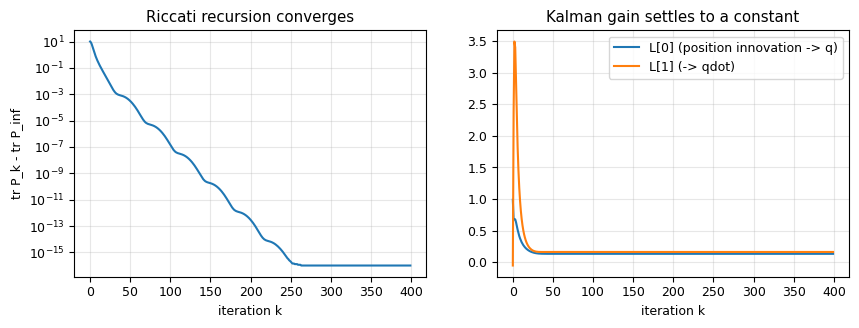

In [6]:
def riccati_predictor(Ad, C, Wd, Vd, P0, n_iter):
    """Iterate the Kalman predictor Riccati recursion, returning P, L and their histories."""
    P = P0.copy(); trP, Ls = [], []
    for _ in range(n_iter):
        S_ = C @ P @ C.T + Vd
        L = Ad @ P @ C.T @ np.linalg.inv(S_)
        P = Ad @ P @ Ad.T - L @ S_ @ L.T + Wd
        trP.append(np.trace(P)); Ls.append(L.ravel().copy())
    return P, L, np.array(trP), np.array(Ls)

P_it, L_it, trP, Ls = riccati_predictor(Ad, C, Wd, Vd, 10 * np.eye(2), 400)
P_are = sla.solve_discrete_are(Ad.T, C.T, Wd, Vd)                 # solve the DARE directly
L_star = Ad @ P_are @ C.T @ np.linalg.inv(C @ P_are @ C.T + Vd)
print("iteration vs DARE:  |P_it - P_are| =", np.abs(P_it - P_are).max(), "   |L_it - L| =", np.abs(L_it - L_star).max())
print("steady-state gain L =", L_star.ravel(), "  estimator poles |eig(Ad-LC)| =", np.abs(np.linalg.eigvals(Ad - L_star @ C)))

# (ii) Loewner optimality:  P_next(L) - P >= 0 for EVERY gain L (computed from the definition, not from the derivation)
rng = np.random.default_rng(1)
def P_next(L, P): return (Ad - L @ C) @ P @ (Ad - L @ C).T + Wd + L @ Vd @ L.T
mins = [np.linalg.eigvalsh(P_next(L_star + 0.05 * rng.standard_normal((2, 1)), P_are) - P_are).min() for _ in range(2000)]
print("min eigenvalue of P_next(L) - P over 2000 random gains  =", min(mins), "(>= 0 up to rounding: the Kalman gain dominates all others)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].semilogy(trP - trP[-1] + 1e-16); ax[0].set(xlabel="iteration k", ylabel="tr P_k - tr P_inf", title="Riccati recursion converges")
ax[1].plot(Ls[:, 0], label="L[0] (position innovation -> q)"); ax[1].plot(Ls[:, 1], label="L[1] (-> qdot)"); ax[1].legend()
ax[1].set(xlabel="iteration k", title="Kalman gain settles to a constant"); plt.show()

empirical error covariance of the filter:
 [[0.013   0.01753]
 [0.01753 0.05905]] 
DARE solution P:
 [[0.01308 0.01773]
 [0.01773 0.05957]]

position error :  KF rms 0.1139 | raw measurement rms 0.2996 (= sigma_y) | theory sqrt(P00) = 0.1144
velocity error :  KF rms 0.2422 | finite-difference rms 8.4759 | theory sqrt(P11) = 0.2441
innovation autocorrelation, lags 1..20: max |rho| = 0.0059   (white noise band +-2/sqrt(N) = 0.0071)
innovation variance 0.10288  vs  S = C P C' + Vd = 0.10308


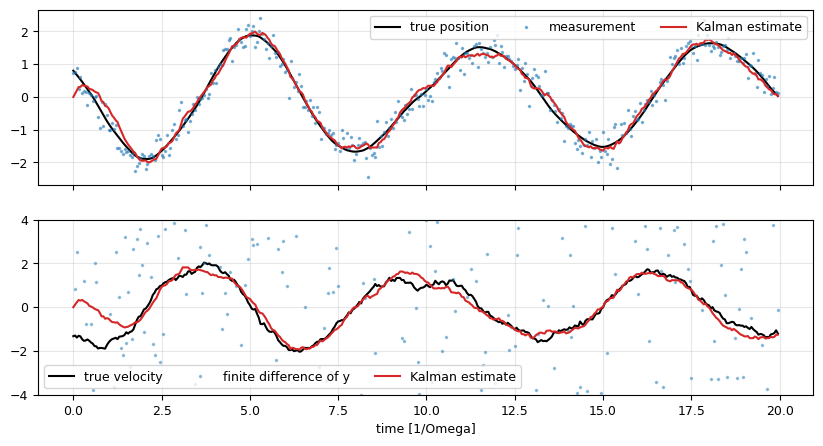

In [7]:
# (iii)+(iv): Monte-Carlo with an ensemble of independent runs (vectorised) and one long run for the innovation statistics
Lw = np.linalg.cholesky(Wd + 1e-18 * np.eye(2))
def kf_ensemble(M_runs=40000, n_steps=400, seed=3):
    rng = np.random.default_rng(seed)
    X = rng.multivariate_normal(np.zeros(2), S, size=M_runs).T          # start in thermal equilibrium
    Xh = np.zeros((2, M_runs))                                          # filter starts knowing nothing
    for _ in range(n_steps):
        y = C @ X + sig_y * rng.standard_normal((1, M_runs))
        Xh = Ad @ Xh + L_star @ (y - C @ Xh)                            # estimator update (u = 0)
        X = Ad @ X + Lw @ rng.standard_normal((2, M_runs))              # plant update
    return X - Xh                                                       # error e_k at the final step

E = kf_ensemble()
print("empirical error covariance of the filter:\n", (E @ E.T) / E.shape[1], "\nDARE solution P:\n", P_are)

# long single run: estimate quality and innovation whiteness
def kf_run(N=80000, seed=5):
    rng = np.random.default_rng(seed)
    x = rng.multivariate_normal(np.zeros(2), S); xh = np.zeros(2)
    Xs, Xh, Y, Nu = np.empty((N, 2)), np.empty((N, 2)), np.empty(N), np.empty(N)
    for k in range(N):
        y = (C @ x)[0] + sig_y * rng.standard_normal()
        nu = y - (C @ xh)[0]
        Xs[k], Xh[k], Y[k], Nu[k] = x, xh, y, nu
        xh = Ad @ xh + L_star[:, 0] * nu
        x = Ad @ x + Lw @ rng.standard_normal(2)
    return Xs, Xh, Y, Nu
Xs, Xh, Y, Nu = kf_run()
print("\nposition error :  KF rms %.4f | raw measurement rms %.4f (= sigma_y) | theory sqrt(P00) = %.4f" %
      (np.std(Xs[100:, 0] - Xh[100:, 0]), np.std(Y - Xs[:, 0]), np.sqrt(P_are[0, 0])))
d_fd = (Y[1:] - Y[:-1]) / Ts
print("velocity error :  KF rms %.4f | finite-difference rms %.4f | theory sqrt(P11) = %.4f" %
      (np.std(Xs[100:, 1] - Xh[100:, 1]), np.std(d_fd - Xs[:-1, 1]), np.sqrt(P_are[1, 1])))
nu = Nu[100:]; lags = np.arange(1, 21)
ac = np.array([np.dot(nu[:-l], nu[l:]) / np.dot(nu, nu) for l in lags])
print("innovation autocorrelation, lags 1..20: max |rho| = %.4f   (white noise band +-2/sqrt(N) = %.4f)" % (np.abs(ac).max(), 2 / np.sqrt(len(nu))))
print("innovation variance %.5f  vs  S = C P C' + Vd = %.5f" % (nu.var(), (C @ P_are @ C.T + Vd)[0, 0]))

t = np.arange(400) * Ts
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, Xs[:400, 0], "k", label="true position"); ax[0].plot(t, Y[:400], ".", ms=3, alpha=.5, label="measurement"); ax[0].plot(t, Xh[:400, 0], "C3", label="Kalman estimate"); ax[0].legend(ncol=3)
ax[1].plot(t, Xs[:400, 1], "k", label="true velocity"); ax[1].plot(t[1:], d_fd[:399], ".", ms=3, alpha=.4, label="finite difference of y"); ax[1].plot(t, Xh[:400, 1], "C3", label="Kalman estimate"); ax[1].legend(ncol=3)
ax[1].set(xlabel="time [1/Omega]", ylim=(-4, 4)); plt.show()

The filter reproduces the theoretical covariance, the innovations are white, and the velocity estimate — which no sensor provides — is far cleaner than differentiating the
measurement. **The estimate is a *dynamical* filter whose bandwidth is set by the ratio $W_d/V_d$**: trusting the model (low $W_d$) gives a slow, smooth estimate; trusting the sensor gives a
fast, noisy one. The next cell shows what happens if that ratio is mis-tuned: the error is minimal exactly when the assumed measurement noise equals the true one.

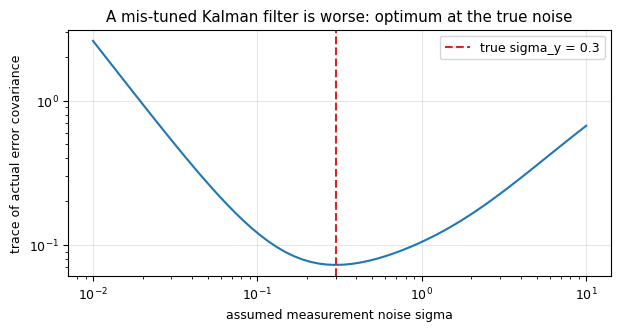

optimum at sigma_assumed = 0.298


In [8]:
# actual error covariance of a filter designed for sigma_assumed but running against the true sigma_y
def actual_error(sigma_assumed, sigma_true=sig_y):
    Pa = sla.solve_discrete_are(Ad.T, C.T, Wd, np.array([[sigma_assumed**2]]))
    La = Ad @ Pa @ C.T @ np.linalg.inv(C @ Pa @ C.T + sigma_assumed**2)
    Pact = sla.solve_discrete_lyapunov(Ad - La @ C, Wd + La @ np.array([[sigma_true**2]]) @ La.T)
    return Pact, La
sig_grid = np.logspace(-2, 1, 60)
tr = [np.trace(actual_error(s_)[0]) for s_ in sig_grid]
plt.figure(figsize=(7, 3.2)); plt.loglog(sig_grid, tr); plt.axvline(sig_y, color="C3", ls="--", label="true sigma_y = 0.3")
plt.xlabel("assumed measurement noise sigma"); plt.ylabel("trace of actual error covariance"); plt.legend(); plt.title("A mis-tuned Kalman filter is worse: optimum at the true noise"); plt.show()
print("optimum at sigma_assumed = %.3f" % sig_grid[int(np.argmin(tr))])

### 3.4 Continuous-time version (used for one number in the GUI)

Taking $T_s\to0$ of the same argument gives the **Kalman–Bucy filter**: $\dot{\hat x}=A\hat x+Bu+L_c(y-C\hat x)$ with $L_c=P_cC^\top R_v^{-1}$ and
$AP_c+P_cA^\top-P_cC^\top R_v^{-1}CP_c+GQ_wG^\top=0$ (a *continuous* algebraic Riccati equation, CARE). The GUI uses it only to *predict the feedback-signal
standard deviation* it shows the user; the FPGA itself uses the discrete gain above.

---
## 4. The LQR: optimal state feedback

**Problem.** Given the exact state, choose $u_k$ to minimise the quadratic cost $J=\sum_k x_k^\top Qx_k+u_k^\top Ru_k$ (paper Eq. 13). $Q\succeq0$ penalises deviation
(here: mechanical energy, i.e. *cooling*), $R\succ0$ penalises actuation.

### 4.1 Derivation by dynamic programming

Let $V_k(x)$ be the minimum cost-to-go from state $x$ at time $k$ over a horizon ending at $N$ (with $V_N=x^\top Q_fx$). **Bellman's principle of optimality** says

$$V_k(x)=\min_u\Big[\,x^\top Qx+u^\top Ru+V_{k+1}(A_dx+B_du)\Big].$$

Guess $V_k(x)=x^\top P_kx$ (true at $k=N$ with $P_N=Q_f$). Then the bracket is a quadratic in $u$:

$$
x^\top Qx+u^\top Ru+(A_dx+B_du)^\top P_{k+1}(A_dx+B_du).
$$

Set its gradient with respect to $u$ to zero: $2Ru+2B_d^\top P_{k+1}(A_dx+B_du)=0$, i.e.

$$
\boxed{u_k=-K_kx_k,\qquad K_k=(R+B_d^\top P_{k+1}B_d)^{-1}B_d^\top P_{k+1}A_d.}
$$

(The Hessian $R+B_d^\top P_{k+1}B_d\succ0$, so this is the minimum.) Substituting back gives $x^\top P_kx$ with

$$
P_k=Q+A_d^\top P_{k+1}A_d-A_d^\top P_{k+1}B_d\,(R+B_d^\top P_{k+1}B_d)^{-1}B_d^\top P_{k+1}A_d ,
$$

so the guess is self-consistent for every $k$. Running this **backward Riccati recursion** to $k\to-\infty$, $P_k\to P$: the infinite-horizon solution satisfies the DARE
(paper Eq. 15) and gives a **constant gain** (paper Eq. 16),

$$
P=A_d^\top PA_d-A_d^\top PB_d(R+B_d^\top PB_d)^{-1}B_d^\top PA_d+Q,\qquad K=(R+B_d^\top PB_d)^{-1}B_d^\top PA_d .
$$

The closed loop $A_d-B_dK$ is stable if $(A_d,B_d)$ is stabilisable and $(A_d,Q^{1/2})$ detectable.

*Duality note.* Compare with §3.1: the Kalman Riccati equation is the LQR one with $A_d\to A_d^\top$, $B_d\to C^\top$, $Q\to W_d$, $R\to V_d$. Estimation and control are the same mathematics run in opposite time directions.

### 4.2 Adding noise changes nothing (certainty equivalence)

With process noise, $x_{k+1}=A_dx_k+B_du_k+w_k$, the cost-to-go becomes $\mathbb E[V_{k+1}]$ and the extra term is
$\mathbb E[w^\top Pw]=\operatorname{tr}(PW_d)$ — a *constant* independent of $u$. The minimiser is unchanged: **the same $K$ is optimal for the noisy problem.** The noise only adds a floor to the achievable cost.

### 4.3 Choosing $Q$: penalise energy (paper Eq. 17)

For cooling, the natural weight is the mechanical energy of each mode, $E=\tfrac12m\dot q^2+\tfrac12m\Omega^2q^2$. In the state $x=[q,\dot q]$ this is $x^\top\mathrm{diag}(\tfrac12m\Omega^2,\tfrac12m)x$,
which the paper writes as $Q=Q_{usr}\odot qq^\top$ with $q=\sqrt{m/2}\,[|\Omega|,\,1]^\top$ and $Q_{usr}=I$ by default ($\odot$ = element-wise product; the identity kills the off-diagonal terms).
Meaningful weights then follow from physics, leaving one knob, $R$.

In [9]:
def lqr_backward(Ad, Bd, Q, R, n_iter=3000, Qf=None):
    """Backward Riccati recursion (Bellman); returns P, K and the history of ||K_k - K_inf||."""
    P = Q.copy() if Qf is None else Qf.copy(); Ks = []
    for _ in range(n_iter):
        K = np.linalg.solve(R + Bd.T @ P @ Bd, Bd.T @ P @ Ad)
        P = Q + Ad.T @ P @ Ad - Ad.T @ P @ Bd @ K
        Ks.append(K.copy())
    return P, K, Ks

# energy weight, paper Eq. (17), with m = 1
qv = np.sqrt(1.0 / 2) * np.array([abs(Om), 1.0])
Q_lqr = np.eye(2) * np.outer(qv, qv)                     # Q_usr = I  (element-wise product)
print("Q = diag(m Om^2/2, m/2) =\n", Q_lqr)
rho = 1e-2
R_lqr = np.array([[rho]])

P_lqr, K_bw, Ks = lqr_backward(Ad, Bd, Q_lqr, R_lqr)
P_are_c = sla.solve_discrete_are(Ad, Bd, Q_lqr, R_lqr)
K_are = np.linalg.solve(R_lqr + Bd.T @ P_are_c @ Bd, Bd.T @ P_are_c @ Ad)
print("backward recursion vs DARE:  |P - P_are| = %.2e   K = %s  (DARE K = %s)" % (np.abs(P_lqr - P_are_c).max(), K_bw.ravel(), K_are.ravel()))
print("closed-loop poles |eig(Ad - Bd K)| =", np.abs(np.linalg.eigvals(Ad - Bd @ K_are)), "  (open loop:", np.abs(np.linalg.eigvals(Ad)), ")")

# Bellman check: the cost of the closed-loop trajectory from x0 equals x0' P x0
x0 = np.array([1.0, 0.0]); x = x0.copy(); cost = 0.0
for _ in range(20000):
    u = -(K_are @ x); cost += x @ Q_lqr @ x + rho * u[0]**2; x = Ad @ x + Bd @ u
print("simulated cost from x0 = [1,0] : %.6f   x0' P x0 = %.6f" % (cost, x0 @ P_are_c @ x0))
# optimality: any other stabilising gain costs more (P_K from the Lyapunov equation for the gain K)
def cost_of_gain(Kg):
    Acl = Ad - Bd @ Kg
    Pk = sla.solve_discrete_lyapunov(Acl.T, Q_lqr + Kg.T @ R_lqr @ Kg)
    return x0 @ Pk @ x0
worse = [cost_of_gain(K_are + 0.1 * rng.standard_normal((1, 2))) - cost_of_gain(K_are) for _ in range(500)]
print("cost difference of 500 random perturbed gains: min = %.2e  (>= 0 -> LQR gain is the minimiser)" % min(worse))

Q = diag(m Om^2/2, m/2) =
 [[0.5 0. ]
 [0.  0.5]]
backward recursion vs DARE:  |P - P_are| = 7.11e-14   K = [4.87559 6.57822]  (DARE K = [4.87559 6.57822])
closed-loop poles |eig(Ad - Bd K)| = [0.94918 0.71137]   (open loop: [0.99875 0.99875] )
simulated cost from x0 = [1,0] : 11.532578   x0' P x0 = 11.532578
cost difference of 500 random perturbed gains: min = 3.03e-07  (>= 0 -> LQR gain is the minimiser)


### 4.4 The cooling trade-off

With full-state feedback and thermal noise, the closed loop is a stable linear system driven by $w_k$, so its stationary covariance solves the discrete Lyapunov equation
$\Sigma=(A_d-B_dK)\Sigma(A_d-B_dK)^\top+W_d$. The mean energy per degree of freedom is $\langle E\rangle=\tfrac12\Omega^2\Sigma_{qq}+\tfrac12\Sigma_{\dot q\dot q}$ (equal to $k_BT=1$ without control).
Sweeping the input weight $R$ maps out the cooling-versus-effort curve.

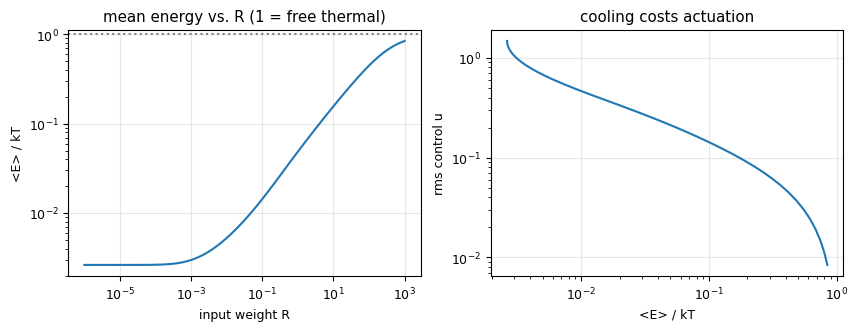

free energy = 1.000 kT; strongest cooling reached = 2.63e-03 kT


In [10]:
def cooling_point(rho_):
    R_ = np.array([[rho_]])
    P_ = sla.solve_discrete_are(Ad, Bd, Q_lqr, R_)
    K_ = np.linalg.solve(R_ + Bd.T @ P_ @ Bd, Bd.T @ P_ @ Ad)
    Sig = sla.solve_discrete_lyapunov(Ad - Bd @ K_, Wd)
    return 0.5 * Om**2 * Sig[0, 0] + 0.5 * Sig[1, 1], np.sqrt((K_ @ Sig @ K_.T)[0, 0]), K_
rhos = np.logspace(-6, 3, 60)
pts = [cooling_point(r_) for r_ in rhos]
E_ = np.array([p[0] for p in pts]); u_ = np.array([p[1] for p in pts])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].loglog(rhos, E_); ax[0].axhline(1, color="gray", ls=":"); ax[0].set(xlabel="input weight R", ylabel="<E> / kT", title="mean energy vs. R (1 = free thermal)")
ax[1].loglog(E_, u_); ax[1].set(xlabel="<E> / kT", ylabel="rms control u", title="cooling costs actuation")
plt.show()
print("free energy = %.3f kT; strongest cooling reached = %.2e kT" % (cooling_point(1e9)[0], E_.min()))

As $R\to0$ the energy keeps falling until it reaches a floor set by the noise entering during a *single* sample (the controller cannot act between samples), and the required $u$ grows without bound.
On the real experiment the floor is set instead by **measurement noise**: the cooling can be no better than the state estimate is accurate — which is precisely why the Kalman filter and the controller
must be designed *together*. That is the subject of the next section.

### 4.5 Continuous-time LQR, and the gain the FPGA actually loads

Minimising $J=\int_0^\infty x^\top Qx+u^\top Ru\,dt$ for $\dot x=Ax+Bu$: the Hamilton–Jacobi–Bellman equation is
$0=\min_u\big[x^\top Qx+u^\top Ru+2x^\top P(Ax+Bu)\big]$ for $V=x^\top Px$. The minimiser is $u=-R^{-1}B^\top Px$, and substitution gives the CARE

$$A^\top P+PA-PBR^{-1}B^\top P+Q=0,\qquad K_c=R^{-1}B^\top P .$$

There are **three different ways** to get a discrete gain from the same weights, and they differ slightly:

1. **`dare`** (paper Eqs. 15–16): apply the discrete LQR to $(A_d,B_d)$ with the *same* numerical $Q$, $R$ (the cost is a sum over samples).
2. **`lqrd`**: discretise the *continuous cost*. Under ZOH, over one sample $\int_0^{T_s}(x^\top Qx+u^\top Ru)\,dt=x_k^\top Q_dx_k+2x_k^\top N_du_k+u_k^\top R_du_k$ with
$Q_d=\int\Phi^\top Q\Phi$, $N_d=\int\Phi^\top Q\Gamma$, $R_d=\int(R+\Gamma^\top Q\Gamma)$, where $\Phi(\sigma)=e^{A\sigma}$ and $\Gamma(\sigma)=\int_0^\sigma e^{A\tau}B\,d\tau$.
All three are one Van Loan exponential of $\bar A=\begin{pmatrix}A&B\\0&0\end{pmatrix}$ with $\bar Q=\mathrm{diag}(Q,R)$ (same proof as §2.2): $\begin{pmatrix}Q_d&N_d\\N_d^\top&R_d\end{pmatrix}=F_2^\top G_1$.
Then the Bellman argument with a cross term gives
$K=(R_d+B_d^\top PB_d)^{-1}(B_d^\top PA_d+N_d^\top)$ and $P=Q_d+A_d^\top PA_d-(A_d^\top PB_d+N_d)(R_d+B_d^\top PB_d)^{-1}(B_d^\top PA_d+N_d^\top)$.
3. **`continuous`**: use $K_c$ directly at the sample instants.

**What does the GUI code load onto the FPGA? The *continuous* gain $K_c$** (it computes the `lqrd` gain but packs `K_LQR_c`). How different are the three? Sweep $T_s$ for our oscillator with an aggressive $R$:

In [11]:
def cost_disc(A, B, Q, R, Ts):
    """Q_d, N_d, R_d of the ZOH-discretised continuous cost via one Van Loan exponential."""
    n, m_ = B.shape; N_ = n + m_
    Abar = np.zeros((N_, N_)); Abar[:n, :n] = A; Abar[:n, n:] = B
    Qbar = sla.block_diag(Q, R)
    M = np.zeros((2 * N_, 2 * N_)); M[:N_, :N_] = -Abar.T; M[:N_, N_:] = Qbar; M[N_:, N_:] = Abar
    E = sla.expm(M * Ts)
    Cst = E[N_:, N_:].T @ E[:N_, N_:]
    Cst = 0.5 * (Cst + Cst.T)
    return Cst[:n, :n], Cst[:n, n:], Cst[n:, n:]

def gain_variants(A, B, Q, R, Ts):
    Ad_, Bd_ = zoh(A, B, Ts)
    # (1) paper: DARE with the same Q, R
    P1 = sla.solve_discrete_are(Ad_, Bd_, Q, R); K1 = np.linalg.solve(R + Bd_.T @ P1 @ Bd_, Bd_.T @ P1 @ Ad_)
    # (2) lqrd: discretised continuous cost, with cross term
    Qd_, Nd_, Rd_ = cost_disc(A, B, Q, R, Ts)
    P2 = sla.solve_discrete_are(Ad_, Bd_, Qd_, Rd_, s=Nd_); K2 = np.linalg.solve(Rd_ + Bd_.T @ P2 @ Bd_, Bd_.T @ P2 @ Ad_ + Nd_.T)
    # (3) continuous CARE
    Pc = sla.solve_continuous_are(A, B, Q, R); K3 = np.linalg.solve(R, B.T @ Pc)
    return K1, K2, K3

print("   Ts     Om*Ts |  K_dare (paper)        |  K_lqrd                |  K_continuous (loaded)   | max rel diff lqrd/cont, dare/cont")
for T_ in (0.2, 0.1, 0.05, 0.02, 0.005, 0.001):
    K1, K2, K3 = gain_variants(A, B, Q_lqr, R_lqr, T_)
    rel = lambda a, b: np.abs(a - b).max() / np.abs(b).max()
    print(f"{T_:6.3f}  {Om*T_:6.3f} | {K1.ravel()} | {K2.ravel()} | {K3.ravel()} | {rel(K2,K3):.1e}, {rel(K1,K3):.1e}")

# cross-check against the pylqg implementation used for the paper's designs
from pylqg.lqg.design import lqrd as pylqg_lqrd, lqr_c as pylqg_lqr_c
print("\nour lqrd vs pylqg.lqrd:", np.abs(gain_variants(A, B, Q_lqr, R_lqr, 0.05)[1] - pylqg_lqrd(A, B, Q_lqr, R_lqr, 0.05)).max())

   Ts     Om*Ts |  K_dare (paper)        |  K_lqrd                |  K_continuous (loaded)   | max rel diff lqrd/cont, dare/cont
 0.200   0.200 | [2.43048 4.09615] | [2.70362 4.37847] | [6.14143 7.84211] | 4.4e-01, 4.8e-01
 0.100   0.100 | [3.86027 5.55674] | [4.00121 5.69922] | [6.14143 7.84211] | 2.7e-01, 2.9e-01
 0.050   0.050 | [4.87559 6.57822] | [4.92676 6.62952] | [6.14143 7.84211] | 1.5e-01, 1.6e-01
 0.020   0.020 | [5.60319 7.3057 ] | [5.61344 7.31593] | [6.14143 7.84211] | 6.7e-02, 6.9e-02
 0.005   0.005 | [6.00279 7.70406] | [6.00351 7.70477] | [6.14143 7.84211] | 1.8e-02, 1.8e-02
 0.001   0.001 | [6.11348 7.81429] | [6.11351 7.81432] | [6.14143 7.84211] | 3.6e-03, 3.6e-03

our lqrd vs pylqg.lqrd: 3.526068326209497e-13


**Read the table carefully.**

* `lqrd` and the plain `dare` gain agree with *each other* to $O(T_s^2)$ ($1.0\%\to0.18\%\to0.012\%$ as $T_s$: $0.05\to0.02\to0.005$).
* Both approach the continuous gain only at rate $O(T_s)$, and the gap is *not* small: $\sim15\%$ at $\Omega T_s=0.05$. The reason is physical: a zero-order hold behaves like an extra delay of $T_s/2$, so the
  optimal *discrete* law is intrinsically less aggressive than the continuous one, and the relevant small parameter is (closed-loop bandwidth)$\times T_s$, not $\Omega T_s$. With a small $R$ the closed loop is fast.
* The FPGA is loaded with the **continuous** (largest) gain. In Section 6.4 we will measure this gap for the paper's actual design, where it is about 25%. It is a *deliberate* or at least harmless choice (the loop is simulated stable and cooling below), but it is **not** what the paper's Eqs. 15–16 say.

---
## 5. LQG: putting estimator and controller together

The controller of the paper is the certainty-equivalent law
$$u_k=-K\hat x_k,\qquad \hat x_{k+1}=A_d\hat x_k+B_du_k+L\,(y_k-C\hat x_k)\quad\Longleftrightarrow\quad
\hat x_{k+1}=(A_d-LC-B_dK)\hat x_k+Ly_k,\quad u_k=-K\hat x_k$$
(paper Eqs. 18–19), a 7th-order linear filter from the measurement $y$ to the actuation $u$.

### 5.1 Separation principle: stability

Substitute $u=-K\hat x=-K(x-e)$ into the plant:
$$x_{k+1}=A_dx_k-B_dK(x_k-e_k)+w_k=(A_d-B_dK)\,x_k+B_dK\,e_k+w_k,\qquad e_{k+1}=(A_d-LC)\,e_k+w_k-Lv_k .$$
In the coordinates $(x,e)$ the closed loop is **block-triangular**:
$$\begin{pmatrix}x\\e\end{pmatrix}_{k+1}=\underbrace{\begin{pmatrix}A_d-B_dK&B_dK\\0&A_d-LC\end{pmatrix}}_{F}\begin{pmatrix}x\\e\end{pmatrix}_k+\begin{pmatrix}w\\w-Lv\end{pmatrix}_k .$$
So $\operatorname{eig}(F)=\operatorname{eig}(A_d-B_dK)\,\cup\,\operatorname{eig}(A_d-LC)$: **controller and estimator can be designed independently** and the combination is stable iff each is.

### 5.2 Separation principle: optimality and the cost decomposition

Let $P_c$ be the LQR solution (§4.1), $M=R+B_d^\top P_cB_d$, and let $P_e$ be the Kalman error covariance. Using the DARE and $K=M^{-1}B_d^\top P_cA_d$ one checks by *completing the square in $u$* that for **any** $x,u$
$$x^\top Qx+u^\top Ru+(A_dx+B_du)^\top P_c(A_dx+B_du)\;=\;x^\top P_cx+(u+Kx)^\top M(u+Kx).$$
In stationarity $\mathbb E[x_{k+1}^\top P_cx_{k+1}]=\mathbb E[x_k^\top P_cx_k]$, and $w_k$ is independent of $(x_k,u_k)$ so $\mathbb E[x_{k+1}^\top P_cx_{k+1}]=\mathbb E[(A_dx+B_du)^\top P_c(A_dx+B_du)]+\operatorname{tr}(P_cW_d)$. Combining,
the average cost $J=\mathbb E[x^\top Qx+u^\top Ru]$ is
$$\boxed{J=\operatorname{tr}(P_cW_d)+\mathbb E\big[(u+Kx)^\top M(u+Kx)\big]\;\overset{u=-K\hat x}{=}\;\operatorname{tr}(P_cW_d)+\operatorname{tr}\big(K^\top MK\,P_e\big)}$$
because $u+Kx=Ke$. The first term is the LQR (full-information) cost; the second is the *price of imperfect estimation*. Whatever causal controller we choose, the second term is $\mathbb E\|M^{1/2}(u-(-Kx))\|^2$,
i.e. the mean-square error of *estimating the quantity $-Kx$*, which is minimised by the conditional mean $-K\hat x$. Hence **$u=-K\hat x$ with the Kalman estimate is optimal (LQG)** — control and estimation decouple.

### 5.3 Numerical verification
We verify (i) the eigenvalue union, (ii) the cost formula against an exact Lyapunov computation and against a Monte-Carlo simulation of the *actual* estimator-based controller.

In [12]:
K, L = K_are, L_star                       # LQR gain (rho = 1e-2) and Kalman gain from Sections 3-4
n = 2
F = np.block([[Ad - Bd @ K, Bd @ K], [np.zeros((n, n)), Ad - L @ C]])
ev_F = np.sort_complex(np.linalg.eigvals(F))
ev_u = np.sort_complex(np.concatenate([np.linalg.eigvals(Ad - Bd @ K), np.linalg.eigvals(Ad - L @ C)]))
print("eig(F)             :", np.round(ev_F, 5))
print("eig(A-BK) U eig(A-LC):", np.round(ev_u, 5), "\n -> identical:", np.allclose(ev_F, ev_u))

# exact stationary covariance of (x, e):  Sigma = F Sigma F' + N,  N = cov of (w, w - L v)
N_ = np.block([[Wd, Wd], [Wd, Wd + L @ Vd @ L.T]])
Sig = sla.solve_discrete_lyapunov(F, N_)
Sxx, Sxe, See = Sig[:n, :n], Sig[:n, n:], Sig[n:, n:]
Sxh = Sxx - Sxe - Sxe.T + See                               # covariance of xhat = x - e
M_ = R_lqr + Bd.T @ P_lqr @ Bd
J_formula = np.trace(P_lqr @ Wd) + np.trace(K.T @ M_ @ K @ P_are)
J_lyap = np.trace(Q_lqr @ Sxx) + rho * (K @ Sxh @ K.T)[0, 0]
J_lqr_only = np.trace(P_lqr @ Wd)
print("\nJ  tr(Pc W) + tr(K'MK Pe)   = %.6f" % J_formula)
print("J  from the joint Lyapunov  = %.6f   (exact)" % J_lyap)
print("   LQR-only part tr(Pc W)   = %.6f,  price of estimation = %.6f" % (J_lqr_only, J_formula - J_lqr_only))

# Monte-Carlo: the actual estimator-based controller, many runs in parallel
def lqg_ensemble(M_runs=40000, n_steps=500, seed=11, K_=K, L_=L, control=True):
    rng = np.random.default_rng(seed)
    X = rng.multivariate_normal(np.zeros(2), S, size=M_runs).T; Xh = np.zeros((2, M_runs))
    Jacc, Eacc, cnt = 0.0, 0.0, 0
    for k in range(n_steps):
        u = -(K_ @ Xh) if control else np.zeros((1, M_runs))
        y = C @ X + sig_y * rng.standard_normal((1, M_runs))
        if k >= n_steps // 2:
            Jacc += np.mean(np.einsum("ij,ij->j", Q_lqr @ X, X) + rho * u[0]**2); Eacc += np.mean(0.5 * Om**2 * X[0]**2 + 0.5 * X[1]**2); cnt += 1
        Xh = Ad @ Xh + Bd @ u + L_ @ (y - C @ Xh)
        X = Ad @ X + Bd @ u + Lw @ rng.standard_normal((2, M_runs))
    return Jacc / cnt, Eacc / cnt
J_mc, E_mc = lqg_ensemble()
E_free = 1.0; E_lqr = cooling_point(rho)[0]; E_lqg_th = 0.5 * Om**2 * Sxx[0, 0] + 0.5 * Sxx[1, 1]
print("\nMonte-Carlo cost J = %.5f  (theory %.5f)" % (J_mc, J_formula))
print("mean energy <E>/kT :  free = %.3f | full-state LQR = %.4f | LQG (noisy measurement) theory = %.4f, Monte-Carlo = %.4f" % (E_free, E_lqr, E_lqg_th, E_mc))

eig(F)             : [0.71137+0.j      0.92984-0.07949j 0.92984+0.07949j 0.94918+0.j     ]
eig(A-BK) U eig(A-LC): [0.71137+0.j      0.92984-0.07949j 0.92984+0.07949j 0.94918+0.j     ] 
 -> identical: True

J  tr(Pc W) + tr(K'MK Pe)   = 0.069032
J  from the joint Lyapunov  = 0.069032   (exact)
   LQR-only part tr(Pc W)   = 0.009558,  price of estimation = 0.059475

Monte-Carlo cost J = 0.06922  (theory 0.06903)
mean energy <E>/kT :  free = 1.000 | full-state LQR = 0.0053 | LQG (noisy measurement) theory = 0.0632, Monte-Carlo = 0.0634


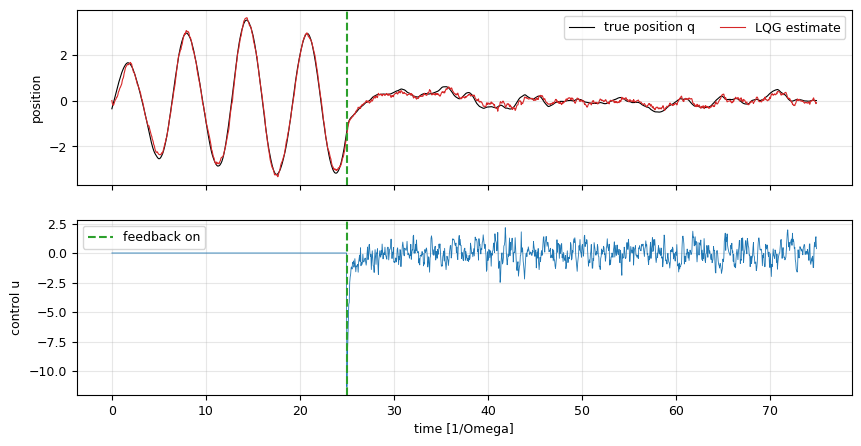

theory: free rms position = 1.000, with LQG = sqrt(Sxx[0,0]) = 0.211  (a ratio of 4.7)
this single run (windows of only ~4 periods, so noisy; the ensemble above is the reliable number): before 2.05, after 0.22


In [13]:
# a single trajectory: control OFF for 500 samples, then ON
def lqg_trajectory(n_steps=1500, t_on=500, seed=21):
    rng = np.random.default_rng(seed)
    x = rng.multivariate_normal(np.zeros(2), S); xh = np.zeros(2)
    out = np.empty((n_steps, 4))
    for k in range(n_steps):
        u = -(K @ xh) if k >= t_on else np.zeros(1)
        y = (C @ x)[0] + sig_y * rng.standard_normal()
        out[k] = [x[0], xh[0], u[0], 0.5*Om**2*x[0]**2 + 0.5*x[1]**2]
        xh = Ad @ xh + Bd @ u + L[:, 0] * (y - (C @ xh)[0])
        x = Ad @ x + Bd @ u + Lw @ rng.standard_normal(2)
    return out
tr_ = lqg_trajectory(); t = np.arange(len(tr_)) * Ts
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(t, tr_[:, 0], "k", lw=.8, label="true position q"); ax[0].plot(t, tr_[:, 1], "C3", lw=.8, label="LQG estimate"); ax[0].axvline(500*Ts, color="C2", ls="--"); ax[0].legend(ncol=2); ax[0].set_ylabel("position")
ax[1].plot(t, tr_[:, 2], "C0", lw=.6); ax[1].axvline(500*Ts, color="C2", ls="--", label="feedback on"); ax[1].legend(); ax[1].set(xlabel="time [1/Omega]", ylabel="control u"); plt.show()
print("theory: free rms position = %.3f, with LQG = sqrt(Sxx[0,0]) = %.3f  (a ratio of %.1f)" % (np.sqrt(S[0, 0]), np.sqrt(Sxx[0, 0]), np.sqrt(S[0, 0] / Sxx[0, 0])))
print("this single run (windows of only ~4 periods, so noisy; the ensemble above is the reliable number): before %.2f, after %.2f" % (tr_[:500, 0].std(), tr_[700:, 0].std()))

### 5.4 The controller as a filter, and how robust is it?

Eliminating $\hat x$, the control law is the transfer function $u=-\mathcal C(z)\,y$ with
$$\mathcal C(z)=K\big(zI-(A_d-LC-B_dK)\big)^{-1}L ,$$
strictly proper — one sample of algorithmic delay is built in. With the plant $P(z)=C(zI-A_d)^{-1}B_d$, the loop gain is $\mathcal L=P\,\mathcal C$ and the sensitivity $S=1/(1+\mathcal L)$.
LQG has **no guaranteed stability margins** (Doyle 1978), so it is worth looking at $\max|S|$ (its inverse is the distance of the Nyquist curve from $-1$).

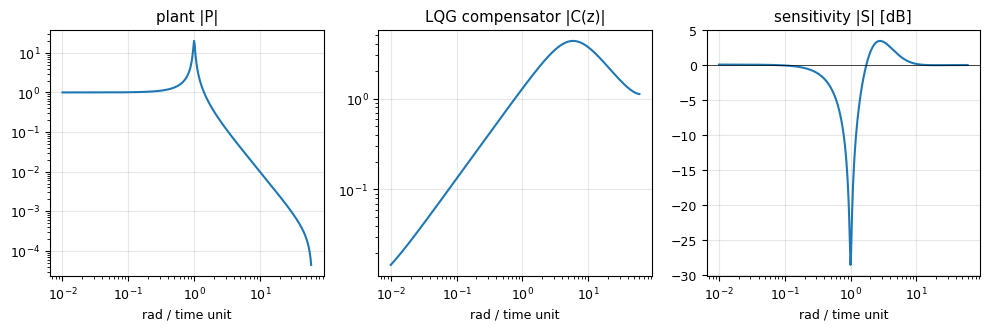

peak sensitivity max|S| = 1.48 (3.4 dB) at w = 2.790  -> distance of Nyquist curve from -1 is >= 0.67


In [14]:
Ac = Ad - L @ C - Bd @ K                                          # compensator state matrix
w = np.logspace(-2, np.log10(np.pi / Ts) - 0.02, 500); z = np.exp(1j * w * Ts)
Cz = np.array([(K @ np.linalg.solve(zi * np.eye(2) - Ac, L))[0, 0] for zi in z])
Pz = np.array([(C @ np.linalg.solve(zi * np.eye(2) - Ad, Bd))[0, 0] for zi in z])
Lo = Pz * Cz; Sens = 1 / (1 + Lo)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].loglog(w, np.abs(Pz)); ax[0].set(title="plant |P|", xlabel="rad / time unit")
ax[1].loglog(w, np.abs(Cz)); ax[1].set(title="LQG compensator |C(z)|", xlabel="rad / time unit")
ax[2].semilogx(w, 20*np.log10(np.abs(Sens))); ax[2].axhline(0, color="k", lw=.5); ax[2].set(title="sensitivity |S| [dB]", xlabel="rad / time unit"); plt.show()
print("peak sensitivity max|S| = %.2f (%.1f dB) at w = %.3f  -> distance of Nyquist curve from -1 is >= %.2f" % (np.abs(Sens).max(), 20*np.log10(np.abs(Sens).max()), w[np.argmax(np.abs(Sens))], 1/np.abs(Sens).max()))

**Latency.** On the FPGA the loop includes ADC and DAC conversion and pipeline registers. The authors' Simulink test bench assumes a **12-sample (768 ns) feedback delay** (`k.nTauFb = 12`); the simulator adds its own 788 ns.
An unmodelled delay of $d$ samples multiplies the loop by $z^{-d}$, eroding the phase margin. The closed loop with a plant that sees $u_{k-d}$ while the estimator assumes it sees $u_k$ has the state $(x,\hat x,u_{k-1},\dots,u_{k-d})$.
The alternative is to **put the delay into the design model** (augment the state with the buffered inputs, which the controller knows exactly) and re-solve both Riccati equations. Compare the spectral radius of the closed loop (stable iff $<1$):

In [15]:
def closedloop_unmodelled_delay(Ad, Bd, C, K, L, d):
    n, m_ = Ad.shape[0], Bd.shape[1]
    Acl = np.zeros((2*n + m_*d, 2*n + m_*d))
    Acl[:n, :n] = Ad
    if d == 0: Acl[:n, n:2*n] = -Bd @ K
    else:      Acl[:n, 2*n + m_*(d-1): 2*n + m_*d] = Bd                        # plant input is u_{k-d}
    Acl[n:2*n, :n] = L @ C; Acl[n:2*n, n:2*n] = Ad - L @ C - Bd @ K             # estimator ignores the delay
    if d >= 1:
        Acl[2*n: 2*n + m_, n:2*n] = -K
        for i in range(1, d): Acl[2*n + m_*i: 2*n + m_*(i+1), 2*n + m_*(i-1): 2*n + m_*i] = np.eye(m_)
    return Acl

def aug_delay_model(Ad, Bd, d):
    n, m_ = Ad.shape[0], Bd.shape[1]
    Aa = np.zeros((n + m_*d, n + m_*d)); Ba = np.zeros((n + m_*d, m_))
    Aa[:n, :n] = Ad; Aa[:n, n + m_*(d-1): n + m_*d] = Bd; Ba[n: n + m_, :] = np.eye(m_)
    for i in range(1, d): Aa[n + m_*i: n + m_*(i+1), n + m_*(i-1): n + m_*i] = np.eye(m_)
    return Aa, Ba

def closedloop_aware(Ad, Bd, C, Q, R, L, d):
    """LQR for the augmented (delay-aware) model; estimator uses the true (delayed) input."""
    n, m_ = Ad.shape[0], Bd.shape[1]
    Aa, Ba = aug_delay_model(Ad, Bd, d); Qa = sla.block_diag(Q, np.zeros((m_*d, m_*d)))
    Pa = sla.solve_discrete_are(Aa, Ba, Qa, R); Ka = np.linalg.solve(R + Ba.T @ Pa @ Ba, Ba.T @ Pa @ Aa)
    Kx, Ku = Ka[:, :n], Ka[:, n:]
    N_ = 2*n + m_*d; Acl = np.zeros((N_, N_))
    Acl[:n, :n] = Ad; Acl[:n, 2*n + m_*(d-1): 2*n + m_*d] = Bd
    Acl[n:2*n, :n] = L @ C; Acl[n:2*n, n:2*n] = Ad - L @ C; Acl[n:2*n, 2*n + m_*(d-1): 2*n + m_*d] = Bd
    Acl[2*n: 2*n + m_, n:2*n] = -Kx; Acl[2*n: 2*n + m_, 2*n: 2*n + m_*d] = -Ku
    for i in range(1, d): Acl[2*n + m_*i: 2*n + m_*(i+1), 2*n + m_*(i-1): 2*n + m_*i] += np.eye(m_)
    return Acl

sr = lambda M: np.abs(np.linalg.eigvals(M)).max()
print("closed-loop spectral radius (Omega*Ts = 0.05); < 1 = stable")
print("   d |  aggressive R=1e-2: unmodelled | delay-aware  ||  gentle R=1: unmodelled | delay-aware")
for d in (0, 1, 2, 4, 8, 12, 16, 24, 32):
    row = []
    for r_ in (1e-2, 1.0):
        Rr = np.array([[r_]]); Pp = sla.solve_discrete_are(Ad, Bd, Q_lqr, Rr); Kk = np.linalg.solve(Rr + Bd.T @ Pp @ Bd, Bd.T @ Pp @ Ad)
        row += [sr(closedloop_unmodelled_delay(Ad, Bd, C, Kk, L, d)), sr(closedloop_aware(Ad, Bd, C, Q_lqr, Rr, L, d)) if d >= 1 else sr(closedloop_unmodelled_delay(Ad, Bd, C, Kk, L, 0))]
    print(f"{d:4d} | {row[0]:16.4f} {'UNSTABLE' if row[0] >= 1 else '        '} | {row[1]:9.4f}    ||   {row[2]:14.4f} {'UNSTABLE' if row[2] >= 1 else '        '} | {row[3]:9.4f}")

closed-loop spectral radius (Omega*Ts = 0.05); < 1 = stable
   d |  aggressive R=1e-2: unmodelled | delay-aware  ||  gentle R=1: unmodelled | delay-aware
   0 |           0.9492          |    0.9492    ||           0.9759          |    0.9759
   1 |           0.9547          |    0.9492    ||           0.9746          |    0.9759
   2 |           0.9583          |    0.9492    ||           0.9737          |    0.9759
   4 |           0.9707          |    0.9492    ||           0.9755          |    0.9759
   8 |           0.9914          |    0.9492    ||           0.9852          |    0.9759
  12 |           1.0024 UNSTABLE |    0.9492    ||           0.9922          |    0.9759
  16 |           1.0084 UNSTABLE |    0.9492    ||           0.9970          |    0.9759
  24 |           1.0136 UNSTABLE |    0.9492    ||           1.0026 UNSTABLE |    0.9759
  32 |           1.0150 UNSTABLE |    0.9492    ||           1.0054 UNSTABLE |    0.9759


An unmodelled delay eventually destabilises the loop, and the more aggressive the design (small $R$), the earlier; a **delay-aware** design stays stable. The paper's controller does *not* model the latency, so it relies on the filter being slow relative to the
delay. We test exactly that, on the real design, in Section 9.

---
## 6. From equations to an FPGA

Everything so far is floating-point linear algebra. The Red Pitaya's Zynq-7020 has DSP48E1 slices with a native **25×18-bit** signed multiplier and no floating-point unit; the controller must run one full
$\hat x_{k+1}=F\hat x_k+\Gamma u_k+Ly_k$, $u_k=K\hat x_k$ every 64 ns. From here on we use the `pylqg` implementation and the paper's own design parameters.

### 6.1 Fixed-point numbers in one paragraph

A signed fixed-point number `sfix W_F` is a $W$-bit two's-complement integer $r$ with value $r\,2^{-F}$, range $[-2^{W-F-1},\,2^{W-F-1})$ and resolution $2^{-F}$. Two rounding modes matter: **truncation** (floor; bias $-\tfrac12$ LSB and error variance $\text{LSB}^2/12$)
and **round-to-nearest** (no bias). Two overflow modes: **wrap-around** (cheap; catastrophic when it happens) and **saturation**.
The FPGA uses truncation everywhere in the datapath, saturation in the Model-Composer casts and wrap-around inside the Verilog matrix core; this matters when states overflow.

In [16]:
from pylqg.fixedpoint import wrap, sat, to_raw, shift_decompose
rng = np.random.default_rng(0)
x = rng.uniform(-1, 1, 200000); F_ = 22; lsb = 2.0**-F_
q_trunc = np.floor(x / lsb) * lsb; q_round = np.round(x / lsb) * lsb
print("LSB = 2^-22 = %.3e\n truncation: mean error %.3e (expect -LSB/2 = %.3e), variance %.3e (LSB^2/12 = %.3e)" %
      (lsb, (q_trunc - x).mean(), -lsb/2, (q_trunc - x).var(), lsb**2/12))
print(" rounding : mean error %.3e, variance %.3e" % ((q_round - x).mean(), (q_round - x).var()))
print("\noverflow of an sfix25 raw value 2^24 (= +1.0 at 22 fractional bits, just out of range):  wrap -> %d   saturate -> %d" % (wrap(2**24, 25), sat(2**24, 25)))

LSB = 2^-22 = 2.384e-07
 truncation: mean error -1.190e-07 (expect -LSB/2 = -1.192e-07), variance 4.727e-15 (LSB^2/12 = 4.737e-15)
 rounding : mean error -7.401e-11, variance 4.746e-15

overflow of an sfix25 raw value 2^24 (= +1.0 at 22 fractional bits, just out of range):  wrap -> -16777216   saturate -> 16777215


### 6.2 Shift-float coefficients (paper Eqs. 20–21)

The matrix entries $F_{ij},\Gamma_{ij},L_{ij},K_{ij}$ span *decades* (see below), while an 18-bit multiplier input has a fixed resolution. Plain fixed-point would give small entries a terrible **relative** error.
The trick: store each matrix element as a *residue* and a *power of two*,
$$\tilde a_{ik}=a_{ik}\,2^{-s_{ik}},\qquad a_{ik}\in(\tfrac12,1],\;s_{ik}\in\{0,\dots,31\}\quad\Rightarrow\quad c_{ij}=\sum_k\big(a_{ik}\,b_{kj}\big)\,2^{-s_{ik}},$$
i.e. an ordinary 18×25-bit multiply followed by an **arithmetic right shift** (a barrel shifter is far cheaper than a floating-point unit). With $F=14$ fractional bits and round-to-nearest, the absolute residue error is at most $2^{-15}$, so the **relative** error of every coefficient is
$$\frac{|\delta a|}{|a|}\le\frac{2^{-15}}{1/2}=2^{-14}\approx6.1\times10^{-5}\qquad\text{independent of the magnitude of the entry.}$$
Plain sfix18_14 has absolute error $2^{-15}$, so its relative error is $2^{-15}/|a|$ and blows up for small entries. We check this on the coefficient matrices of the **paper's Set-1 controller** (built by `pylqg`, which ports the GUI's design code):

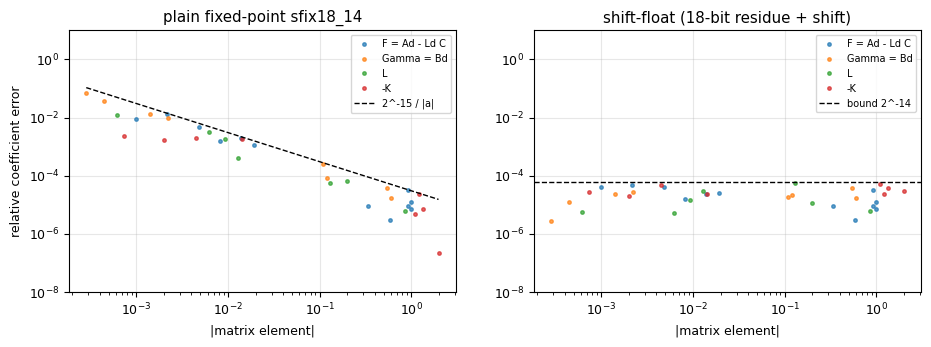

elements span 2.8e-04 ... 2.0e+00  (3.8 decades)
worst relative error: plain fixed-point 7.24e-02 | shift-float 5.75e-05 (bound 6.10e-05)

packed K (the sign is flipped so that the FPGA computes u = +K_hw xhat):
 shift =
 [[-1 -1  6  8  0  0  0]
 [10  7 -1 -1  0  0  0]] 
 residue raw (sfix18_14) =
 [[-11002  -8892 -14886   8433      0      0      0]
 [ 12259   9453 -16251  -9887      0      0      0]]


In [17]:
from pylqg import saddle
from pylqg.lqg import design_lqg
pp1 = saddle.lqg_params(1)                      # LQG parameter set 1 of the paper's example (confining potential)
d1 = design_lqg(pp1)
cfg = d1.pack(feedback=True)                    # shift/residue integers exactly as loaded to the FPGA
dq = cfg.dequantised()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
allm = []
for name, ref, key in (("F = Ad - Ld C", d1.F7, "F"), ("Gamma = Bd", d1.B7, "B"), ("L", d1.L7, "L"), ("-K", -d1.K7, "K")):
    nz = np.abs(ref) > 0
    a = np.abs(ref[nz])
    plain = np.clip(np.round(ref * 2**14) / 2**14, -8, 8 - 2**-14)          # ordinary sfix18_14, round to nearest
    ax[0].loglog(a, np.abs(plain[nz] - ref[nz]) / a, ".", ms=5, alpha=.7, label=name)
    ax[1].loglog(a, np.abs(dq[key][nz] - ref[nz]) / a, ".", ms=5, alpha=.7, label=name)
    allm.append(a)
allm = np.concatenate(allm)
xs = np.logspace(np.log10(allm.min()), np.log10(allm.max()), 50)
ax[0].loglog(xs, 2**-15 / xs, "k--", lw=1, label="2^-15 / |a|"); ax[0].set(title="plain fixed-point sfix18_14", xlabel="|matrix element|", ylabel="relative coefficient error")
ax[1].axhline(2**-14, color="k", ls="--", lw=1, label="bound 2^-14"); ax[1].set(title="shift-float (18-bit residue + shift)", xlabel="|matrix element|")
ax[0].legend(fontsize=7); ax[1].legend(fontsize=7); ax[0].set_ylim(1e-8, 10); ax[1].set_ylim(1e-8, 10); plt.show()
print("elements span %.1e ... %.1e  (%.1f decades)" % (allm.min(), allm.max(), np.log10(allm.max()/allm.min())))
print("worst relative error: plain fixed-point %.2e | shift-float %.2e (bound %.2e)" % (
    max(np.max(np.abs(np.clip(np.round(r*2**14)/2**14, -8, 8-2**-14)[np.abs(r)>0] - r[np.abs(r)>0]) / np.abs(r[np.abs(r)>0])) for r in (d1.F7, d1.B7, d1.L7, -d1.K7)),
    max(np.max(np.abs(dq[k][np.abs(r)>0] - r[np.abs(r)>0]) / np.abs(r[np.abs(r)>0])) for k, r in (("F", d1.F7), ("B", d1.B7), ("L", d1.L7), ("K", -d1.K7))), 2**-14))
print("\npacked K (the sign is flipped so that the FPGA computes u = +K_hw xhat):\n shift =\n", cfg.K_shift, "\n residue raw (sfix18_14) =\n", cfg.K_res)

### 6.3 State-space transformations (paper Eqs. 24–30)

Shift-float removes the *coefficient* scaling problem but the **states** must also fit 25 bits, and the products must not overflow. The remedy is a similarity transformation. Let $\bar x=T^{-1}x$; then
$$\bar A=T^{-1}AT,\quad\bar B=T^{-1}B,\quad\bar C=CT,\quad\bar K=KT ,$$
(the paper writes the inverse convention; the code uses this one) and **the input–output behaviour is unchanged**: for the compensator, $-\bar K(zI-\bar F+\bar B\bar K)^{-1}\bar L=-KT\,T^{-1}(zI-F+BK)^{-1}TT^{-1}L=-K(zI-F+BK)^{-1}L$. Only the internal numbers change.

**(a) Physical normalisation (Eq. 25).** Position in metres is $\sim10^{-8}$, velocity in m/s $\sim10^{-3}$, voltages $\sim10^{-2}$; $C\sim10^{6}$. The transformation $x\to C_{\max}\,x$, $\dot x\to C_{\max}\dot x/|\Omega|$ makes positions and velocities comparable and maps a displacement to (roughly) the measured voltage.

**(b) Covariance balancing (Eqs. 26–30).** With gains fixed, the state estimate is a linear system driven by the innovation $\nu=y-C\hat x$ (covariance $S=CPC^\top+V_d$):
$\hat x_{k+1}=(A_d-B_dK)\hat x_k+L\nu_k$. Its stationary covariance $P_{\hat x}$ solves the Lyapunov equation
$$P_{\hat x}=(A_d-B_dK)\,P_{\hat x}\,(A_d-B_dK)^\top+L\,S\,L^\top .$$
(The GUI uses $LV_dL^\top$, i.e. ignores the $CPC^\top$ part of $S$; we quantify the small difference below.) A *diagonal* $T$ rescales $P_{\hat x}\to T^{-1}P_{\hat x}T^{-\top}$; choosing $T$ so that all states have the same standard deviation $\bar\sigma$ uses the 25-bit range evenly.
The GUI takes the diagonal of the **Cholesky factor** ($P_{\hat x}=R^\top R$), $T_{bal}=\mathrm{diag}(R_{ii})/\bar\sigma$. Finally $T$ is clamped so that $|B_d|,|L|\le1$ and $|K|\le32$ (the ranges of the 18-bit formats).

We now see what these steps do on the real design.

In [18]:
def describe(label, dd):
    mats = dict(F=dd.F7, Gamma=dd.B7, L=dd.L7, K=dd.K7)
    rng_ = {k: (np.abs(v[v != 0]).min(), np.abs(v).max()) for k, v in mats.items()}
    try:
        e = dd.pack(True).dequantised()
        err = max(np.max(np.abs(e[k] - M)[M != 0] / np.abs(M)[M != 0]) for k, M in (("F", dd.F7), ("B", dd.B7), ("L", dd.L7), ("K", -dd.K7)))
        status = "loads OK, worst relative coefficient error %.1e" % err
    except ValueError:
        status = "CANNOT BE LOADED: a coefficient exceeds the sfix18_14 range"
    print(f"{label:30s} |F| in [{rng_['F'][0]:.0e},{rng_['F'][1]:.0e}]  |L| in [{rng_['L'][0]:.0e},{rng_['L'][1]:.0e}]  |Gamma| in [{rng_['Gamma'][0]:.0e},{rng_['Gamma'][1]:.0e}]  |K| in [{rng_['K'][0]:.0e},{rng_['K'][1]:.0e}]\n{'':30s}  -> {status}")
describe("(0) SI units, no transform",       design_lqg(pp1.with_(transformed_model=False, numerical_transform=False)))
describe("(1) physical normalisation",       design_lqg(pp1.with_(transformed_model=True,  numerical_transform=False)))
describe("(2) normalisation + balancing",    d1)

(0) SI units, no transform     |F| in [6e-08,4e+04]  |L| in [9e-11,1e-02]  |Gamma| in [4e-11,6e-03]  |K| in [2e-01,2e+07]
                                -> CANNOT BE LOADED: a coefficient exceeds the sfix18_14 range
(1) physical normalisation     |F| in [1e-03,1e+00]  |L| in [4e-04,5e-01]  |Gamma| in [2e-04,3e-01]  |K| in [1e-03,6e+00]
                                -> loads OK, worst relative coefficient error 4.7e-05
(2) normalisation + balancing  |F| in [1e-03,1e+00]  |L| in [6e-04,1e+00]  |Gamma| in [3e-04,6e-01]  |K| in [7e-04,2e+00]
                                -> loads OK, worst relative coefficient error 5.8e-05


In [19]:
# (a) invariance: the compensator transfer function is the same in every coordinate system
d0 = design_lqg(pp1.with_(transformed_model=False, numerical_transform=False))       # SI coordinates
def comp_tf(dd, z):      # u/y = -K (zI - F + B K)^{-1} L  in the coordinates of the design
    n_ = dd.F_hw.shape[0]
    return (-dd.K_hw @ np.linalg.solve(z * np.eye(n_) - dd.F_hw + dd.B_hw @ dd.K_hw, dd.L_hw))
for f_ in (1e3, 15e3, 40e3, 200e3):
    zf = np.exp(1j * 2 * np.pi * f_ * 64e-9)
    a, b = comp_tf(d0, zf), comp_tf(d1, zf)
    print(f"f = {f_/1e3:6.0f} kHz  |C(z)| SI: {np.abs(a).ravel()}  balanced: {np.abs(b).ravel()}  max rel diff {np.abs(a-b).max()/np.abs(a).max():.1e}")

f =      1 kHz  |C(z)| SI: [0.1044  0.02388 0.02431 0.14825]  balanced: [0.1044  0.02388 0.02431 0.14825]  max rel diff 8.3e-13
f =     15 kHz  |C(z)| SI: [0.17832 0.03808 0.04048 0.21169]  balanced: [0.17832 0.03808 0.04048 0.21169]  max rel diff 5.4e-13
f =     40 kHz  |C(z)| SI: [0.39504 0.08185 0.08871 0.42562]  balanced: [0.39504 0.08185 0.08871 0.42562]  max rel diff 2.9e-13
f =    200 kHz  |C(z)| SI: [1.43935 0.30243 0.32197 1.55578]  balanced: [1.43935 0.30243 0.32197 1.55578]  max rel diff 1.4e-13


In [20]:
# (b) how well does the balancing hit its target?  exact stationary covariance of xhat (joint Lyapunov of [x; e]) in hardware coordinates
Ts_c = pp1.Ts
def zoh_(A_, B_, Ts_):
    n_, m__ = B_.shape; M__ = np.zeros((n_+m__, n_+m__)); M__[:n_, :n_] = A_; M__[:n_, n_:] = B_; E_ = sla.expm(M__*Ts_); return E_[:n_, :n_], E_[:n_, n_:]
Ad_p, BG_p = zoh_(d1.A, np.hstack([d1.B, d1.G]), Ts_c); Gd_p = BG_p[:, d1.B.shape[1]:]
Wd_p = Gd_p @ (d1.Pw / Ts_c) @ Gd_p.T; Vd_p = d1.Pv / Ts_c
Kp, Lp, Cp, Bp = d1.K_used, d1.Ld, d1.C, d1.Bd; n_ = Ad_p.shape[0]
Fp = np.block([[Ad_p - Bp @ Kp, Bp @ Kp], [np.zeros((n_, n_)), Ad_p - Lp @ Cp]])
Np = np.block([[Wd_p, Wd_p], [Wd_p, Wd_p + Lp @ Vd_p @ Lp.T]])
Sg = sla.solve_discrete_lyapunov(Fp, Np); Sxh_p = Sg[:n_, :n_] - Sg[:n_, n_:] - Sg[:n_, n_:].T + Sg[n_:, n_:]
Pk_ = sla.solve_discrete_are(Ad_p.T, Cp.T, Wd_p, Vd_p); S_p = Cp @ Pk_ @ Cp.T + Vd_p
Ti = np.linalg.inv(d1.T_opt); std = lambda Pm: np.sqrt(np.diag(Ti @ Pm @ Ti.T))
Pe_V = sla.solve_discrete_lyapunov(Ad_p - Bp @ Kp, Lp @ Vd_p @ Lp.T)          # what the GUI balances against (forcing L V L')
Pe_S = sla.solve_discrete_lyapunov(Ad_p - Bp @ Kp, Lp @ S_p @ Lp.T)           # forcing L S L'  (innovation covariance)
print("target std of every hardware state          :", pp1.target_state_std)
print("GUI's Lyapunov (forcing L V L')             :", std(Pe_V))
print("Lyapunov with forcing L S L'                :", std(Pe_S))
print("exact xhat covariance (joint [x;e] Lyapunov) :", std(Sxh_p), "  <- identical to the L S L' line: the derivation above is exact")
print("\nCholesky-diagonal vs sqrt(variance) ratio per state:", np.diag(np.linalg.cholesky(Pe_V).T) / np.sqrt(np.diag(Pe_V)),
      "\n  (about 1 for the position states, 0.56-0.67 for the velocity states: the Cholesky diagonal is a *conditional* standard deviation, so the achieved std deviates from the target for the velocity states)")

target std of every hardware state          : 0.01
GUI's Lyapunov (forcing L V L')             : [0.00994 0.01479 0.00997 0.01776]
Lyapunov with forcing L S L'                : [0.01032 0.01536 0.01034 0.01843]
exact xhat covariance (joint [x;e] Lyapunov) : [0.01032 0.01536 0.01034 0.01843]   <- identical to the L S L' line: the derivation above is exact

Cholesky-diagonal vs sqrt(variance) ratio per state: [1.      0.67227 0.99711 0.55959] 
  (about 1 for the position states, 0.56-0.67 for the velocity states: the Cholesky diagonal is a *conditional* standard deviation, so the achieved std deviates from the target for the velocity states)


Three observations, all measured above: (1) **without state scaling the design cannot even be loaded** — coefficients exceed the sfix18_14 range; (2) the compensator's frequency response is *unchanged* by the transformations (the SI-unit and balanced designs agree to $10^{-12}$);
(3) the balancing lands each hardware state within a factor $\lesssim2$ of the target (the Cholesky diagonal is a conditional, not a marginal, standard deviation), which is more than adequate for a 25-bit range; using the exact innovation covariance $S$ would be exact but changes the numbers by only a few percent.

### 6.4 Which gain is actually loaded?

Recall §4.5: three discrete gains can be derived from the same $Q,R$. For the paper's design they are **not** close, because the LQR closed-loop poles are fast compared with the sampling rate:

In [21]:
dl = design_lqg(pp1.with_(lqr_method="lqrd")); dpp = design_lqg(pp1.with_(lqr_method="dare"))
rel = lambda a, b: np.max(np.abs(a - b)) / np.max(np.abs(b))
print("relative difference of the gains (normalised coordinates):")
print("   lqrd  vs continuous K_c : %.1f %%" % (100 * rel(d1.K_d, d1.K_c)))
print("   DARE (paper Eq.15-16) vs K_c : %.1f %%    <-- the gain in the bitstream is K_c" % (100 * rel(dpp.K_used, d1.K_c)))
print("   lqrd vs DARE            : %.1f %%" % (100 * rel(d1.K_d, dpp.K_used)))
lam = np.sort(np.abs(np.linalg.eigvals(d1.A - d1.B @ d1.K_c))) * 64e-9
print("continuous closed-loop poles times Ts:", np.round(lam, 4), " -> the two fast poles are at 0.5 and 0.8 rad/sample: strongly affected by the ZOH")
print("Kalman estimator poles |z|:", np.round(np.sort(np.abs(np.linalg.eigvals(d1.Ad - d1.Ld @ d1.C))), 4), " (slow: the estimator averages heavily because the modelled measurement noise, 4e-12 V^2 s, is large)")

relative difference of the gains (normalised coordinates):
   lqrd  vs continuous K_c : 25.0 %
   DARE (paper Eq.15-16) vs K_c : 26.8 %    <-- the gain in the bitstream is K_c
   lqrd vs DARE            : 2.4 %
continuous closed-loop poles times Ts: [0.006  0.0141 0.5117 0.7678]  -> the two fast poles are at 0.5 and 0.8 rad/sample: strongly affected by the ZOH
Kalman estimator poles |z|: [0.9627 0.9627 0.9637 0.9637]  (slow: the estimator averages heavily because the modelled measurement noise, 4e-12 V^2 s, is large)


### 6.5 The datapath, bit by bit

`pylqg.lqg.core.LQGCore` reproduces, sample by sample, the arithmetic of the Simulink/Verilog design (verified against an independent per-element implementation in the test-suite):

| step | operation | format |
|---|---|---|
| ADC | 14-bit word $\to$ +offset, $\times$factor (truncate, saturate) | sfix14_12 $\to$ sfix25_22 |
| $u=Kx$ | residue×state (exact 43-bit product), arithmetic shift (**left-shift capable**, saturating), floor to 43/37, **wrapping** sum | sfix43_37 $\to$ sfix25_22 (saturate) |
| $x^+=Fx+\Gamma u+Ly$ | three matrix–vector products (right shift only), each cast to sfix28_22, added, cast to sfix25_22 (all truncate + saturate) | sfix25_22 |
| DAC | $u\to$ sfix14_12 (truncate, saturate) $\times$ factor + offset | 14-bit word |

Note the last row: $u$ is rounded to $2^{-12}$ V ($244\,\mu$V) and then multiplied by $2$ (the $\pm1$ V full scale), so the **DAC's least significant bit is never used**: the effective output resolution is 13 bit. The next cell runs the fixed-point core and an ideal double-precision copy on the same measurement stream.

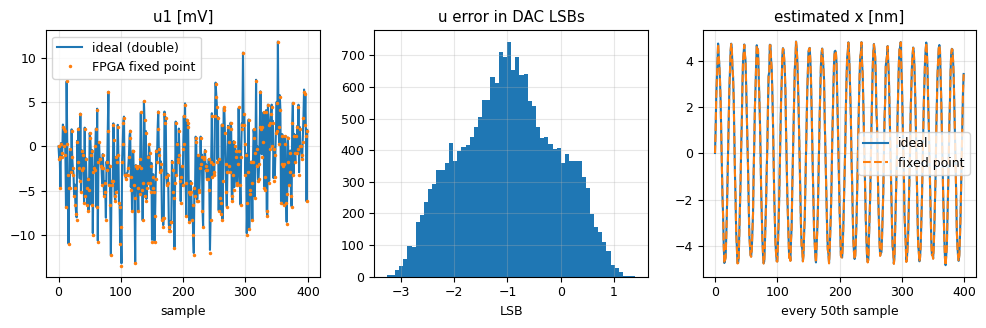

u rms 4.655e-03 V | rms(fixed - ideal) = 1.636e-04 V = 1.34 DAC LSB | state estimate rms diff = 1.40e-11 m
every DAC word is even (the LSB is unused, 13-bit effective resolution): True | smallest step between distinct words: 2 LSB


In [22]:
from pylqg.lqg import LQGCore, LQGCoreFloat
core = LQGCore(cfg); ideal = LQGCoreFloat(d1, feedback=True)
rng = np.random.default_rng(1); Nn = 20000
tt = np.arange(Nn)
y_in = 0.02 * np.sin(2*np.pi*15e3*64e-9*tt)[:, None] * np.array([1, .3]) + 0.003 * rng.standard_normal((Nn, 2))
u_fx, u_fl, xh_fx, xh_fl = [], [], [], []
for k in range(Nn):
    yq = np.round(y_in[k] * 8192) / 8192                       # what a 14-bit ADC delivers
    u_fx.append(core.step(yq)); u_fl.append(ideal.step(yq))
    if k % 50 == 0: xh_fx.append(core.xhat_physical()[[0, 2]]); xh_fl.append(ideal.xhat_physical()[[0, 2]])
u_fx, u_fl = np.array(u_fx), np.array(u_fl); xh_fx, xh_fl = np.array(xh_fx), np.array(xh_fl)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(u_fl[:400, 0]*1e3, label="ideal (double)"); ax[0].plot(u_fx[:400, 0]*1e3, ".", ms=3, label="FPGA fixed point"); ax[0].set(title="u1 [mV]", xlabel="sample"); ax[0].legend()
ax[1].hist((u_fx[:, 0] - u_fl[:, 0]) * 8192, bins=60); ax[1].set(title="u error in DAC LSBs", xlabel="LSB")
ax[2].plot(xh_fl[:, 0]*1e9, label="ideal"); ax[2].plot(xh_fx[:, 0]*1e9, "--", label="fixed point"); ax[2].set(title="estimated x [nm]", xlabel="every 50th sample"); ax[2].legend(); plt.show()
print("u rms %.3e V | rms(fixed - ideal) = %.3e V = %.2f DAC LSB | state estimate rms diff = %.2e m" % (u_fl.std(), np.sqrt(np.mean((u_fx-u_fl)**2)), np.sqrt(np.mean((u_fx-u_fl)**2))*8192, np.sqrt(np.mean((xh_fx-xh_fl)**2))))
words = np.round(u_fx * 8192).astype(int)
print("every DAC word is even (the LSB is unused, 13-bit effective resolution):", bool(np.all(words % 2 == 0)), "| smallest step between distinct words:", int(np.diff(np.unique(words[:, 0])).min()), "LSB")

---
## 7. The hardware-in-the-loop simulator

To test a controller on real hardware *without* a cryostat, the authors built a **second FPGA** that emulates the nanoparticle: it reads the controller's DAC output, integrates a
(possibly nonlinear, noisy) equation of motion in real time, and drives the controller's ADC. This lets the controller be tuned against a plant with a *known* model, and lets potentials be switched in nanoseconds.

### 7.1 The model class (paper Eqs. 31–35)

Generalising §1.1 from a linear oscillator to an arbitrary **separable nonlinear potential** with three coordinates and thermal noise, the simulator integrates for each of its three *slices* $j$
$$
\ddot q_j \;=\; \underbrace{c^{u}_j\, s_j(t)}_{\text{driven by ADC and noise}}\;+\;c^{x}_j\,f_j(q_j)\;+\;c^{\dot x}_j\,g_j(\dot q_j),\qquad s_j=\sum_i a_{ji}\,\phi_i(\mathrm{adc}_i)+b_j\,\eta_j(t),
$$
where $f_j,g_j,\phi_i$ are **nonlinear functions** (lookup tables), $a_{ji}$ is the *input matrix* (voltage $\to$ force), $\eta_j$ is a noise generator, and the two outputs are mixtures $y_k=\sum_j d_{kj}\,h_{kj}(\text{state}_j)$.
Linear damping and stiffness are $g(\dot q)=\dot q$, $f(q)=q$; a **double-well/saddle** potential is $f(q)=\alpha^4q^3/\Omega^2-q$ (then $c^x=-\Omega^2$ gives $\ddot q=\Omega^2q-\alpha^4q^3$). Each $f$ has a *primary and an alternate* table that can be **switched at run time**
(paper's "potential switching", used in Section 8).

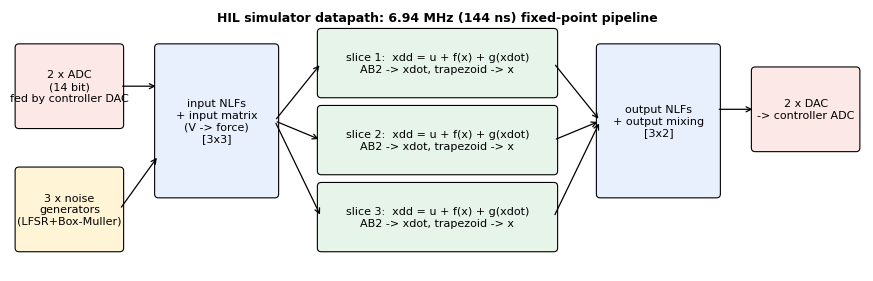

In [23]:
import matplotlib.patches as mp
fig, ax = plt.subplots(figsize=(11, 3.4)); ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0, 3.4)
def box(x, y, w, h, txt, fc="#e8f0fe"):
    ax.add_patch(mp.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05", fc=fc, ec="k", lw=.8)); ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=8)
def arrow(x0, y0, x1, y1): ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", lw=.9))
box(0.1, 1.9, 1.3, 1.0, "2 x ADC\n(14 bit)\nfed by controller DAC", "#fde8e8"); box(0.1, 0.3, 1.3, 1.0, "3 x noise\ngenerators\n(LFSR+Box-Muller)", "#fff4d6")
box(1.9, 1.0, 1.5, 1.9, "input NLFs\n+ input matrix\n(V -> force)\n[3x3]"); arrow(1.4, 2.4, 1.9, 2.4); arrow(1.4, 0.8, 1.9, 1.5)
for j in range(3):
    y = 0.3 + 1.0 * (2 - j); box(4.0, y, 3.0, 0.8, f"slice {j+1}:  xdd = u + f(x) + g(xdot)\nAB2 -> xdot, trapezoid -> x", "#e6f4ea"); arrow(3.4, 1.95, 4.0, y + 0.4)
box(7.6, 1.0, 1.5, 1.9, "output NLFs\n+ output mixing\n[3x2]"); 
for j in range(3): arrow(7.0, 0.7 + j, 7.6, 1.95)
box(9.6, 1.6, 1.3, 1.0, "2 x DAC\n-> controller ADC", "#fde8e8"); arrow(9.1, 2.1, 9.6, 2.1)
ax.text(5.5, 3.25, "HIL simulator datapath: 6.94 MHz (144 ns) fixed-point pipeline", ha="center", fontsize=9, weight="bold"); plt.show()

### 7.2 Numerical integration: Adams–Bashforth + trapezoid

The simulator must advance one step of $h=144$ ns per clock in fixed point, using only *past* values (no iteration). For $\dot v=a(t)$, integrate over $[t_n,t_{n+1}]$ and extrapolate the integrand linearly through
$(t_{n-1},a_{n-1})$ and $(t_n,a_n)$:
$$
p(t)=a_n+(a_n-a_{n-1})\tfrac{t-t_n}{h}\;\Rightarrow\;\int_{t_n}^{t_{n+1}}p\,dt=h\big(\tfrac32a_n-\tfrac12a_{n-1}\big)
\quad\Rightarrow\quad \boxed{v_{n+1}=v_n+h\,(\tfrac32a_n-\tfrac12a_{n-1})}
$$
the two-step **Adams–Bashforth** method (local error $\tfrac5{12}h^3\dddot v$, second-order global accuracy). For $\dot q=v$ the **trapezoid rule** (one-step Adams–Moulton) is used, because $v_{n+1}$ is already known:
$$\boxed{q_{n+1}=q_n+\tfrac h2(v_{n+1}+v_n)}$$
The acceleration $a_n=c^xf(q_{n-1})+c^{\dot x}g(v_{n-1})+\dots$ is computed from the **previous** state (registered feedback), which keeps the critical path short.
How good is this scheme for an oscillator? We form the linear one-step map on $(q_n,v_n,a_n)$ for $\ddot q=-\Omega^2q-\Gamma\dot q$ and inspect its eigenvalues:

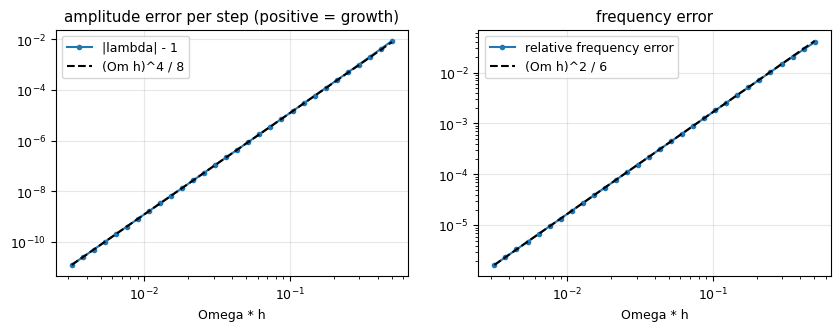

fit quality:  (|lam|-1) / ((Om h)^4/8) = 1.000 ... 1.065    (freq err) / ((Om h)^2/6) = 1.000 ... 0.973
  f =  3.76 kHz: Om*h = 0.0034 -> numerical quality factor Q_num = -1.02e+08  (frequency error +0.0002 %)
  f = 15.00 kHz: Om*h = 0.0136 -> numerical quality factor Q_num = -1.60e+06  (frequency error +0.0031 %)
  f = 35.00 kHz: Om*h = 0.0317 -> numerical quality factor Q_num = -1.26e+05  (frequency error +0.0167 %)
  f = 70.00 kHz: Om*h = 0.0633 -> numerical quality factor Q_num = -1.57e+04  (frequency error +0.0669 %)


In [24]:
def hil_step_matrix(h, Om, G):
    """One step of the HIL integrator on the state (q_n, v_n, a_n), for q'' = -Om^2 q - G q'."""
    def step(s):
        q, v, a = s
        a1 = -Om**2 * q - G * v                 # force from the previous state
        v1 = v + h * (1.5 * a1 - 0.5 * a)       # Adams-Bashforth 2
        q1 = q + 0.5 * h * (v1 + v)             # trapezoid
        return np.array([q1, v1, a1])
    return np.column_stack([step(e) for e in np.eye(3)])

hOm = np.logspace(-2.5, -0.3, 30); dmag, dfreq = [], []
for x_ in hOm:
    ev = np.linalg.eigvals(hil_step_matrix(x_, 1.0, 0.0)); lam = ev[np.argmax(np.abs(ev.imag))]
    dmag.append(np.abs(lam) - 1.0); dfreq.append(abs(np.angle(lam)) / x_ - 1.0)
dmag, dfreq = np.array(dmag), np.array(dfreq)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].loglog(hOm, dmag, "o-", ms=3, label="|lambda| - 1"); ax[0].loglog(hOm, hOm**4 / 8, "k--", label="(Om h)^4 / 8"); ax[0].set(xlabel="Omega * h", title="amplitude error per step (positive = growth)"); ax[0].legend()
ax[1].loglog(hOm, dfreq, "o-", ms=3, label="relative frequency error"); ax[1].loglog(hOm, hOm**2 / 6, "k--", label="(Om h)^2 / 6"); ax[1].set(xlabel="Omega * h", title="frequency error"); ax[1].legend(); plt.show()
print("fit quality:  (|lam|-1) / ((Om h)^4/8) = %.3f ... %.3f    (freq err) / ((Om h)^2/6) = %.3f ... %.3f" % ((dmag / (hOm**4 / 8))[:5].mean(), (dmag / (hOm**4 / 8))[-5:].mean(), (dfreq / (hOm**2 / 6))[:5].mean(), (dfreq / (hOm**2 / 6))[-5:].mean()))
h_hil = 144e-9
for f_ in (3.76e3, 15e3, 35e3, 70e3):
    x_ = 2*np.pi*f_*h_hil; print(f"  f = {f_/1e3:5.2f} kHz: Om*h = {x_:.4f} -> numerical quality factor Q_num = -{4/x_**3:.2e}  (frequency error +{100*x_**2/6:.4f} %)")

**Result.** For a *lossless* oscillator the scheme is slightly **anti-damped**: $|\lambda|-1\simeq(\Omega h)^4/8>0$, together with a small frequency *increase* $\simeq(\Omega h)^2/6$
(the numbers above confirm both fits). Adding physical damping $\Gamma$ gives $\ln|\lambda|\approx-\Gamma h/2+(\Omega h)^4/8$, i.e. an effective damping
$\Gamma_{\rm eff}=\Gamma-\Omega^4h^3/4$. The simulated oscillator therefore stays stable only if
$$Q<Q_{\max}=\frac{4}{(\Omega h)^3}.$$
At 35 kHz this is $Q_{\max}\approx1.3\times10^5$; a $Q=10^8$ resonator (the low-pressure regime motivating the paper) can only be emulated stably below $\approx3.8$ kHz. It is a real limit of the chosen scheme, not of the FPGA arithmetic — and a good reason to keep $\Omega h\ll1$ ($\Omega h=0.032$ for the paper's 35 kHz mode).

### 7.3 Nonlinear functions: a 1024-entry lookup table with linear interpolation

Each $f,g,\phi,h$ is a table with $N=2^{10}$ entries covering $[-x_r,x_r)$, where $x_r=1.7\,x_{\max}$ (a margin of 70% over the largest excursion seen in the compile scenarios).
The input is an $\mathrm{sfix25\_24}$ number, so its **top 10 bits are the table address and the low 15 bits the interpolation fraction**; the output is $y=(1-\theta)T[i]+\theta T[i+1]$.
The classical bound for linear interpolation with spacing $\Delta=2x_r/N$ is $|f-\tilde f|\le\frac{\Delta^2}{8}\max|f''|$. Because the address is a *wrapping* counter, values beyond $\pm x_r$ silently **wrap around** — which is why the 70% margin exists.

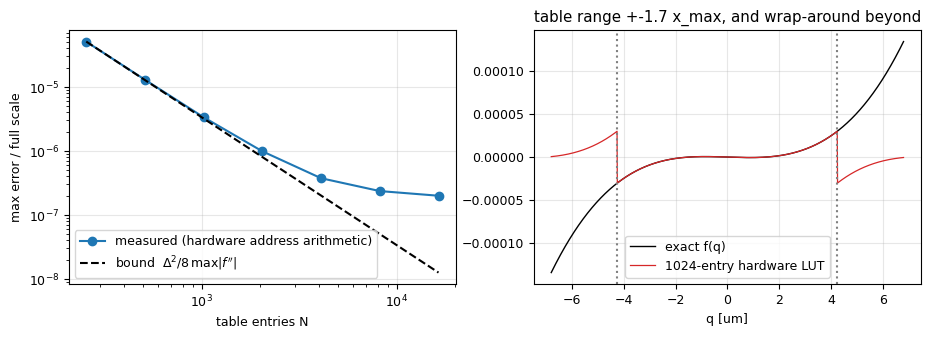

N =    256: error 5.09e-05   bound 5.12e-05
N =    512: error 1.29e-05   bound 1.28e-05
N =   1024: error 3.35e-06   bound 3.20e-06
N =   2048: error 9.83e-07   bound 7.99e-07
N =   4096: error 3.73e-07   bound 2.00e-07
N =   8192: error 2.35e-07   bound 5.00e-08
N =  16384: error 1.99e-07   bound 1.25e-08
(for N >= 2^12 the measured error stops following the h^2 law: it is limited by the 25-bit input word: 2^-24 of the range times the slope; the real FPGA additionally rounds the table entries to 18 bits)


In [25]:
from pylqg.hil.nlf import NLFunction
f_saddle  = lambda q: saddle.ALPHA1**4 / saddle.OMEGA1**2 * q**3 - q            # the paper's saddle force
fpp_saddle = lambda q: 6 * saddle.ALPHA1**4 / saddle.OMEGA1**2 * q
nlf = NLFunction(); nlf.set_func(f_saddle); nlf.in_max = 2.5e-6                # largest excursion assumed 2.5 um
xr = nlf.in_max * 1.7

def hw_lookup(xn, bits, lut):
    """Hardware-style lookup: xn in [-1,1) (fraction of x_r) as sfix25_24, top `bits` bits address, rest interpolate (with address wrap)."""
    N = 2**bits; sh = 25 - bits
    raw = wrap(np.floor(xn * 2**24).astype(np.int64), 25)
    a = (raw >> sh) & (N - 1); fr = (raw & (2**sh - 1)) / 2**sh
    return lut[a] * (1 - fr) + lut[(a + 1) & (N - 1)] * fr

xn = np.linspace(-0.98, 0.98, 40001); errs, bnds, Ns = [], [], []
for bits in range(8, 15):
    N = 2**bits; _, yr, lut, _ = nlf.export_nlf_params(1.0, 1.0, N)
    errs.append(np.max(np.abs(hw_lookup(xn, bits, lut) * yr - f_saddle(xn * xr))) / yr)
    bnds.append((2 * xr / N)**2 / 8 * np.max(np.abs(fpp_saddle(xn * xr))) / yr); Ns.append(N)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].loglog(Ns, errs, "o-", label="measured (hardware address arithmetic)"); ax[0].loglog(Ns, bnds, "k--", label=r"bound  $\Delta^2/8\,\max|f''|$"); ax[0].set(xlabel="table entries N", ylabel="max error / full scale"); ax[0].legend()
_, yr, lut, _ = nlf.export_nlf_params(1.0, 1.0, 1024)
xw = np.linspace(-1.6, 1.6, 4000)                      # beyond +-1 the 25-bit word wraps around inside hw_lookup
ax[1].plot(xw * xr * 1e6, f_saddle(xw * xr), "k", lw=1, label="exact f(q)")
ax[1].plot(xw * xr * 1e6, hw_lookup(xw, 10, lut) * yr, "C3", lw=.9, label="1024-entry hardware LUT")
ax[1].axvline(-xr * 1e6, color="gray", ls=":"); ax[1].axvline(xr * 1e6, color="gray", ls=":")
ax[1].set(xlabel="q [um]", title="table range +-1.7 x_max, and wrap-around beyond"); ax[1].legend(); plt.show()
for N, e, b in zip(Ns, errs, bnds): print(f"N = {N:6d}: error {e:.2e}   bound {b:.2e}")
print("(for N >= 2^12 the measured error stops following the h^2 law: it is limited by the 25-bit input word: 2^-24 of the range times the slope; the real FPGA additionally rounds the table entries to 18 bits)")

### 7.4 Noise generation

Thermal noise is produced from **uniform pseudo-random numbers**: a 24-bit Galois **LFSR** (linear-feedback shift register) yields a uniform bit stream, and the **Box–Muller transform** turns pairs of uniforms into Gaussians.
*Derivation.* If $x_1,x_2$ are independent $\mathcal N(0,1)$, their joint density $\frac1{2\pi}e^{-(x_1^2+x_2^2)/2}$ in polar coordinates $(r,\theta)$ is $\frac1{2\pi}e^{-r^2/2}\,r\,dr\,d\theta$: the angle is uniform on $[0,2\pi)$ and
$P(r^2>s)=e^{-s/2}$, so $r^2=-2\ln u_1$ with $u_1\sim U(0,1]$. Hence
$$x_1=\sqrt{-2\ln u_1}\cos(2\pi u_2),\qquad x_2=\sqrt{-2\ln u_1}\sin(2\pi u_2).$$
The hardware evaluates $\sqrt{-2\ln u}$ and $\sin/\cos$ with **lookup tables**, so the Gaussian is truncated: with a $b$-bit $u_1$ the largest possible $|x|$ is $\sqrt{-2\ln2^{-b}}$
(2.9 for $b=6$; the hardware table has $6+6$ address bits and is normalised to unit power, which makes the observed maximum about $2.95\sigma$). Let us look at the generator in `pylqg`, and check the tails.

**What is the *variance*?** The MATLAB library's `set_noise_power(p)` sets the **variance per step**, and the sample is added to the acceleration *as a piecewise-constant force*. A continuous white noise of PSD $S$ integrated over one step $h$ has variance $S\,h$, whereas a constant force $\sigma\eta$ over the step
contributes $\sigma^2h^2$; equating them gives the conversion
$$\boxed{\sigma^2=S/h}\qquad(\text{per-step variance}=\text{PSD}/\text{time step}),$$
exactly the same reasoning as $V_d=R_v/T_s$ in §2.3. `pylqg` offers `noise_mode="variance"` (library semantics) and `noise_mode="psd"` (divide by $h$ for you).

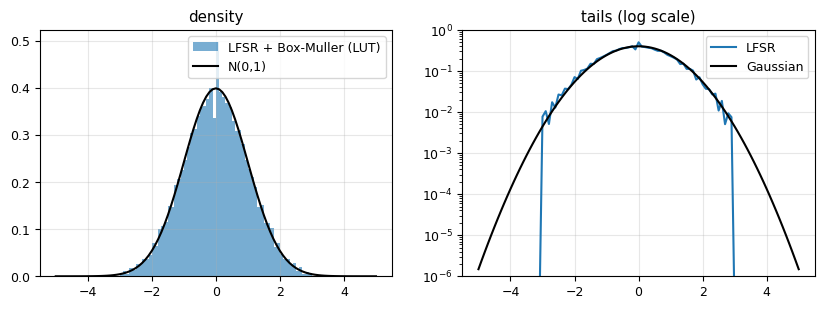

hardware generator: std = 1.000, max |x| = 2.95, excess kurtosis = -0.162 (Gaussian: 0), lag-1 autocorr = +0.0008
fraction of a true Gaussian beyond the hardware's +-2.95 sigma cut-off: 0.31 %
numpy Gaussian     :        max |x| = 4.73, excess kurtosis = +0.008
radius bound of the 6-bit table, sqrt(-2 ln 2^-6) = 2.88; the observed maximum is a little larger because the table is normalised to unit power


In [26]:
from pylqg.hil.noise import NoiseGen
ng = NoiseGen(kind="lfsr", seed=1)
xs_l = np.array([ng.draw()[0] for _ in range(200000)])            # one of the three hardware noise channels
xs_g = np.random.default_rng(0).standard_normal(200000)
k_ex = lambda v: np.mean((v - v.mean())**4) / v.var()**2 - 3
grid = np.linspace(-5, 5, 101)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(xs_l, bins=grid, density=True, alpha=.6, label="LFSR + Box-Muller (LUT)"); ax[0].plot(grid, np.exp(-grid**2/2)/np.sqrt(2*np.pi), "k", label="N(0,1)"); ax[0].legend(); ax[0].set(title="density")
ax[1].semilogy(grid, np.histogram(xs_l, bins=np.append(grid, 5.1), density=True)[0][:len(grid)] + 1e-7, label="LFSR"); ax[1].semilogy(grid, np.exp(-grid**2/2)/np.sqrt(2*np.pi), "k", label="Gaussian"); ax[1].set(ylim=(1e-6, 1), title="tails (log scale)"); ax[1].legend(); plt.show()
print("hardware generator: std = %.3f, max |x| = %.2f, excess kurtosis = %+.3f (Gaussian: 0), lag-1 autocorr = %+.4f" % (xs_l.std(), np.abs(xs_l).max(), k_ex(xs_l), np.corrcoef(xs_l[:-1], xs_l[1:])[0, 1]))
print("fraction of a true Gaussian beyond the hardware's +-%.2f sigma cut-off: %.2f %%" % (np.abs(xs_l).max(), 100 * (1 - __import__("math").erf(np.abs(xs_l).max() / np.sqrt(2)))))
print("numpy Gaussian     :        max |x| = %.2f, excess kurtosis = %+.3f" % (np.abs(xs_g).max(), k_ex(xs_g)))
print("radius bound of the 6-bit table, sqrt(-2 ln 2^-6) = %.2f; the observed maximum is a little larger because the table is normalised to unit power" % np.sqrt(-2 * np.log(2.0**-6)))

### 7.5 Does the simulator obey equipartition? An end-to-end physics test

A good test of noise scaling, integrator and fixed-point arithmetic together: simulate a *free* harmonic oscillator in thermal equilibrium and compare $\langle q^2\rangle$ with $k_BT/(m\Omega^2)$.
We use a damping large enough for many relaxation times in a short run ($\Gamma=2\pi\cdot30$ kHz) and run **both** the double-precision engine (`sim_td`) and the integer fixed-point engine (`sim_tdfp`), in both noise modes
(in `variance` mode we hand over $S/h$ ourselves).

In [27]:
from pylqg.hil import HILSimModel, Scenario
kB, Tk = 1.380649e-23, 293.0
m_eq, Om_eq, Gam_eq = 5e-17, 2*np.pi*35e3, 2*np.pi*30e3
S_force = 2 * m_eq * Gam_eq * kB * Tk                       # thermal PSD 2 gamma kB T
h_ = 144e-9
def eq_model(mode):
    mod = HILSimModel(noise_mode=mode)
    mod.noise_sources[0].set_noise_power(S_force if mode == "psd" else S_force / h_)
    mod.input_matrix.set_matrix([[0, 0, 1], [0, 0, 0], [0, 0, 0]])
    mod.slices[0].u_factor = 1 / m_eq; mod.slices[0].x_factor = -Om_eq**2; mod.slices[0].xdot_factor = -Gam_eq
    mod.output_slices[0].linear_factors = [1e6, 0, 0]
    return mod
Nn = 100000; sc_eq = Scenario.from_arrays(np.zeros(Nn), np.zeros(Nn), 1e-7)
res = {}
t0 = time.time()
for mode in ("psd", "variance"):
    mod = eq_model(mode); mod.compile(sc_eq, True, verbose=False)
    for name, fn in (("double engine", mod.sim_td), ("fixed-point engine", mod.sim_tdfp)):
        q = fn(sc_eq, True)[0].Data[2000:] / 1e6
        res[(mode, name)] = np.var(q) / (kB * Tk / (m_eq * Om_eq**2))
print("<q^2> / (kB T / m Omega^2)     [%.0f s]" % (time.time() - t0))
for (mode, name), v in res.items(): print(f"  noise_mode = {mode:8s} {name:20s}: {v:.3f}")
print("statistical uncertainty of a single run ~ +-%.0f %% (about %d independent samples)" % (100 * np.sqrt(2 / (Nn * Gam_eq * h_ / 2)), Nn * Gam_eq * h_ / 2))

<q^2> / (kB T / m Omega^2)     [4 s]
  noise_mode = psd      double engine       : 1.003
  noise_mode = psd      fixed-point engine  : 1.009
  noise_mode = variance double engine       : 1.003
  noise_mode = variance fixed-point engine  : 1.009
statistical uncertainty of a single run ~ +-4 % (about 1357 independent samples)


All four runs sit within 1% of 1 (well inside the ~4% statistical uncertainty): **`psd` mode with $S=2\gamma k_BT$ is correct thermal physics, and `variance` mode with $S/h$ is the same thing.** (The paper's $P_w=3.2\times10^{-34}$ passed to `variance` mode directly would be $1/h\approx7\times10^{6}$ times too small a *variance*
if it was meant as a PSD; §8.6 measures the consequence.)

### 7.6 Scaling: fitting physics into 18-bit constants

A fixed-point integrator can only represent numbers in a limited range, whereas physical accelerations ($10^{5\ldots11}$ m/s²), velocities ($10^{-3}$ m/s) and positions ($10^{-8}$ m) span 16 decades.
The MATLAB `compile()` step therefore **runs the model in double precision on user-supplied scenarios**, records the maxima $\ddot q_{\max},\dot q_{\max},q_{\max}$ of each slice, and rescales the state variables to unit range:
$$\ddot q=P_2\,\ddot{\tilde q},\quad \dot q=P_1\,\dot{\tilde q},\quad q=P_0\,\tilde q\quad(\text{so that }|\tilde q|\lesssim1),\qquad\text{integrator gains }P_1,\;P_0\text{ absorbed into the constants}$$
and the *input matrix* is normalised by a common factor so its entries fit sfix18_10 (range $\pm128$, resolution $2^{-10}$). Everything is thus dimensionless inside the FPGA, and the scale factors reappear only at the output stage.
Look at what it computed for the paper's plant:

In [28]:
plant_model = saddle.build_plant("psd")
plant_model.compile(saddle.scenarios(), enable_noise=False, verbose=False)
print("slice | max |xdd| [m/s^2] | max |xd| [m/s] | max |x| [m]  ||  prescalers  P2 (xdd)   P1 (xd)     P0 (x)")
for j, sl in enumerate(plant_model.slices):
    print(f"  {j+1}   |   {sl.xdd_max:12.3e}   |  {sl.xd_max:10.3e}  | {sl.x_max:10.3e} ||  {sl.xdotdot_presc:11.3e}  {sl.xdot_presc:10.3e}  {sl.x_presc:10.3e}")
fx = plant_model.get_tdfp_model()
print("\nfixed-point constants actually loaded (sfix18_10 raw integers; value = raw/1024):")
print("  input matrix rows :", fx["inp"], "\n  noise prescalers  :", fx["noise_presc"])
print("  effective time step: %.4f ns (nominal 144 ns; the constant is quantised to 2^-10 relative resolution)" % (fx["int_dt_res"] / 1024 / 2**22 * 1e9))
print("  compile-time check of ranges:", "no constants saturate or underflow" if not plant_model.quantisation_issues else plant_model.quantisation_issues)

slice | max |xdd| [m/s^2] | max |xd| [m/s] | max |x| [m]  ||  prescalers  P2 (xdd)   P1 (xd)     P0 (x)
  1   |      1.687e+04   |   9.437e-02  |  2.067e-06 ||    1.185e-04   1.788e+05   4.566e+04
  2   |      6.940e+03   |   3.086e-02  |  1.434e-07 ||    2.882e-04   2.249e+05   2.151e+05
  3   |      0.000e+00   |   0.000e+00  |  0.000e+00 ||    1.000e+00   1.000e+00   1.000e+00

fixed-point constants actually loaded (sfix18_10 raw integers; value = raw/1024):
  input matrix rows : [[5563, 1113, 164], [1735, 8675, 205], [0, 0, 0]] 
  noise prescalers  : [164, 205, 0]
  effective time step: 143.8893 ns (nominal 144 ns; the constant is quantised to 2^-10 relative resolution)
  compile-time check of ranges: no constants saturate or underflow


**A pitfall worth knowing.** If the input-matrix entries differ by more than about $10^3$ *after* normalisation, the smallest one falls below $2^{-10}$ and **silently becomes zero**: the simulator then ignores that input. This happens for instance if a noise power is orders of magnitude larger
than the signal path. Both the MATLAB tool and `pylqg` compile without complaint; `pylqg` (this version) now emits a `RuntimeWarning` listing every constant that saturates or underflows. We provoke it on purpose:

In [29]:
import warnings
bad = HILSimModel()
bad.noise_sources[0].set_noise_power(1.0)                     # default-like huge noise power vs. a tiny signal path
bad.input_matrix.set_matrix([[6e-12 / 5, 0, 1], [0, 0, 0], [0, 0, 0]])
bad.slices[0].u_factor = 1 / 9.77e-18; bad.slices[0].x_factor = -2 * 9e-7 / 9.77e-18; bad.slices[0].xdot_factor = -1.5e3
bad.output_slices[0].linear_factors = [1e6, 0, 0]
pulse = np.zeros(3000); pulse[100:200] = 1.0
sc_bad = Scenario.from_arrays(pulse, np.zeros(3000), 1e-7)
with warnings.catch_warnings(record=True) as w_:
    warnings.simplefilter("always"); bad.compile(sc_bad, False, verbose=False)
print("compile emitted a warning:", bool(w_)); print(str(w_[0].message)[:700] if w_ else "")
y_td = bad.sim_td(sc_bad, False)[0].Data; y_fp = bad.sim_tdfp(sc_bad, False)[0].Data
print("\npeak output: double-precision engine %.3f V  |  fixed-point engine %.3f V   (the input path was quantised to zero)" % (np.abs(y_td).max(), np.abs(y_fp).max()))

compile emitted a warning: True
HIL model constants do not fit the hardware formats - the fixed-point simulation will be wrong (typically because coefficients differ by more than ~1e3, e.g. a noise power that dwarfs the signal path):
  slice0 u gain = 4.08e+05 saturates the sfix18_10 range (+-128)
  input matrix slice0 <-adc0 = 2.94e-06 underflows to 0 (resolution 2^-10)
  input matrix slice0 <-noise = 1.11e+03 saturates the sfix18_10 range (+-128)
  noise prescaler slice0 = 1.11e+03 saturates the sfix18_10 range (+-128)

peak output: double-precision engine 1.330 V  |  fixed-point engine 0.000 V   (the input path was quantised to zero)


### 7.7 What the 18-bit constants cost: a small frequency error

All physical constants are rounded to sfix18_10, including the *integration time step*. Because 144 ns is stored as a raw multiple of $2^{-10}$ of a scaled value, the **effective step is 143.889 ns** (−0.077%), which makes the simulated oscillator run slower by that fraction.
We measure the frequency of a lightly damped 35 kHz oscillator in the double-precision and in the fixed-point engine and compare with the value predicted from the loaded constants ($\omega=\sqrt{-g_xP_1P_0}\cdot\frac{h_{\rm eff}}{h}$):

In [30]:
mod_f = HILSimModel(); mod_f.input_matrix.set_matrix([[1e-12, 0, 0], [0, 0, 0], [0, 0, 0]])
mod_f.slices[0].u_factor = 1 / m_eq; mod_f.slices[0].x_factor = -Om_eq**2; mod_f.slices[0].xdot_factor = -2*np.pi*200
mod_f.output_slices[0].linear_factors = [1e6, 0, 0]
Nf = 40000; kick = np.zeros(Nf); kick[100:160] = 0.5
sc_f = Scenario.from_arrays(kick, np.zeros(Nf), 1e-7); mod_f.compile(sc_f, False, verbose=False)
def zero_cross_freq(y, dt):
    y = y[400:]; s = np.where((y[:-1] < 0) & (y[1:] >= 0))[0]; fr = s + (-y[s]) / (y[s + 1] - y[s]); return (len(fr) - 1) / ((fr[-1] - fr[0]) * dt)
f_td = zero_cross_freq(mod_f.sim_td(sc_f, False)[0].Data, 144e-9); f_fp = zero_cross_freq(mod_f.sim_tdfp(sc_f, False)[0].Data, 144e-9)
mm = mod_f.get_tdfp_model(); c10 = lambda r: r / 1024
s0_ = mm["slices"][0]; P1_ = c10(s0_["xd_presc_mul"]) * 2.0**-s0_["xd_presc_bitshift"]; P0_ = c10(s0_["x_presc_mul"]) * 2.0**-s0_["x_presc_bitshift"]
h_eff = mm["int_dt_res"] / 1024 / 2**22
f_pred = np.sqrt(-c10(s0_["x"]["gain"]) * P1_ * P0_) * (h_eff / 144e-9) / (2*np.pi)
print("nominal frequency          : 35000.0 Hz")
print("double engine (AB2/trap.)  : %.1f Hz   (%+.3f %%; theory (Om h)^2/6 = %+.3f %%)" % (f_td, 100*(f_td/35e3-1), 100*(2*np.pi*35e3*144e-9)**2/6))
print("fixed-point engine         : %.1f Hz   (%+.3f %% vs nominal, %+.3f %% vs double engine)" % (f_fp, 100*(f_fp/35e3-1), 100*(f_fp/f_td-1)))
print("predicted from constants   : %.1f Hz;  effective time step %.3f ns -> %+.3f %%" % (f_pred, h_eff*1e9, 100*(h_eff/144e-9-1)))

nominal frequency          : 35000.0 Hz
double engine (AB2/trap.)  : 35005.7 Hz   (+0.016 %; theory (Om h)^2/6 = +0.017 %)
fixed-point engine         : 34977.2 Hz   (-0.065 % vs nominal, -0.081 % vs double engine)
predicted from constants   : 34971.5 Hz;  effective time step 143.889 ns -> -0.077 %


---
## 8. The paper's example: a particle in a switchable saddle potential

Section 4 of the paper puts everything together. A **2-D particle** ($m=5\times10^{-17}$ kg) is confined by a harmonic potential; the controller (board 1) is closed around the simulator (board 2), and the protocol of the paper's Fig. 5 is run:

1. confining potential, **no feedback** (free thermal motion);
2. **feedback on**, LQG parameter **Set 1** (designed for the confining $+15$ kHz mode);
3. controller switched to **Set 2** (designed for the *saddle*, i.e. an unstable mode with $\Omega\to-15$ kHz);
4. **simulator potential switched** to the saddle, $V=-\tfrac12m\Omega^2q^2+\tfrac14m\alpha^4q^4$ (a double well; $\Omega=2\pi\cdot15$ kHz, $\alpha=2\pi\cdot40$ kHz), while the controller keeps the particle at the unstable point;
5. **feedback off**: the particle rolls off the hill into one of the wells.

The $y$-axis stays a 35 kHz confining oscillator throughout. Controller and simulator use the paper's parameters (`pylqg.saddle`): $T_s=64$ ns, $C_e=4\times10^6$ V/m with cross-talk, $C_f=5\times10^{-12}$ N/V, $P_w=3.2\times10^{-34}$, $P_v=4\times10^{-12}$ V²s, $R=(5\times10^{-11})^2$, and target state std $0.01$.

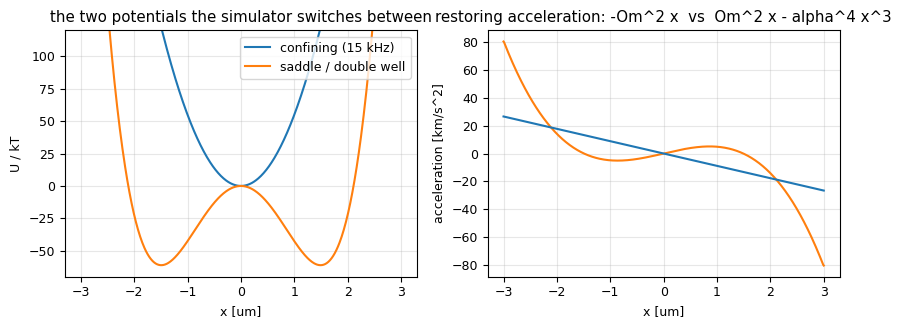

wells at +-1.49 um (= +-6.0 V at the ADC, i.e. beyond the +-1 V converter range), barrier 61 kT, unstable rate Omega = 9.42e+04 /s (e-fold time 10.6 us)
thermal rms displacement in the confining potential: 95.4 nm = 382 mV at the ADC


In [31]:
from pylqg import saddle, ClosedLoop, HILSimDevice, LQGDevice
m_p, O1, A1, O2 = saddle.M, saddle.OMEGA1, saddle.ALPHA1, saddle.OMEGA2
q = np.linspace(-3e-6, 3e-6, 600); kT = kB * 293
U_conf = 0.5 * m_p * O1**2 * q**2 / kT; U_sad = (-0.5 * m_p * O1**2 * q**2 + 0.25 * m_p * A1**4 * q**4) / kT
q0 = O1 / A1**2; barrier = 0.25 * m_p * O1**4 / A1**4 / kT
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(q * 1e6, U_conf, label="confining (15 kHz)"); ax[0].plot(q * 1e6, U_sad, label="saddle / double well"); ax[0].set(ylim=(-70, 120), xlabel="x [um]", ylabel="U / kT", title="the two potentials the simulator switches between"); ax[0].legend()
ax[1].plot(q * 1e6, -np.gradient(U_sad, q) * kT / m_p / 1e3, "C1"); ax[1].plot(q * 1e6, -O1**2 * q / 1e3, "C0"); ax[1].set(xlabel="x [um]", ylabel="acceleration [km/s^2]", title="restoring acceleration: -Om^2 x  vs  Om^2 x - alpha^4 x^3"); plt.show()
print("wells at +-%.2f um (= +-%.1f V at the ADC, i.e. beyond the +-1 V converter range), barrier %.0f kT, unstable rate Omega = %.2e /s (e-fold time %.1f us)" % (q0 * 1e6, q0 * 4e6, barrier, O1, 1e6 / O1))
print("thermal rms displacement in the confining potential: %.1f nm = %.0f mV at the ADC" % (np.sqrt(kT / (m_p * O1**2)) * 1e9, np.sqrt(kT / (m_p * O1**2)) * 4e6 * 1e3))

### 8.1 The two controllers

Both parameter sets are designed with exactly the algorithm of §§1–6 (`design_lqg` is a port of the GUI code). Set 2 uses $\Omega\to-\Omega$ so that $A$ has an **unstable real pole pair $\pm\Omega$**:
the LQR must *stabilise* the hilltop, the Kalman filter must track an unstable mode.

In [32]:
d_set = {n: design_lqg(saddle.lqg_params(n)) for n in (1, 2)}
for n, dd in d_set.items():
    ev_ol = np.linalg.eigvals(dd.A); ev_cl = np.linalg.eigvals(dd.A - dd.B @ dd.K_c)
    print(f"Set {n}: {dd.A.shape[0]} states, {dd.B.shape[1]} inputs, {dd.C.shape[0]} outputs")
    print("   open-loop poles  [1/us]:", np.sort_complex(np.round(ev_ol / 1e6, 3)))
    print("   LQR closed-loop  [1/us]:", np.sort_complex(np.round(ev_cl / 1e6, 3)))
    print("   Kalman estimator |z|   :", np.round(np.sort(np.abs(np.linalg.eigvals(dd.Ad - dd.Ld @ dd.C))), 4))
    print("   GUI-predicted feedback std [mV]:", np.round(np.diag(dd.U_std) * 1e3, 2), "  max |K_hw| = %.2f" % np.abs(dd.K7).max())

Set 1: 4 states, 2 inputs, 2 outputs
   open-loop poles  [1/us]: [-0.003-0.22j  -0.003-0.094j -0.003+0.094j -0.003+0.22j ]
   LQR closed-loop  [1/us]: [-11.996+0.j  -7.995+0.j  -0.22 +0.j  -0.094+0.j]
   Kalman estimator |z|   : [0.9627 0.9627 0.9637 0.9637]
   GUI-predicted feedback std [mV]: [ 9.32 10.42]   max |K_hw| = 1.98
Set 2: 4 states, 2 inputs, 2 outputs
   open-loop poles  [1/us]: [-0.097+0.j   -0.003-0.22j -0.003+0.22j  0.091+0.j  ]
   LQR closed-loop  [1/us]: [-11.997+0.j  -7.996+0.j  -0.22 +0.j  -0.094+0.j]
   Kalman estimator |z|   : [0.9627 0.9627 0.9632 0.9632]
   GUI-predicted feedback std [mV]: [ 9.58 10.43]   max |K_hw| = 1.99


### 8.2 Does the simulator do what the equations say? Three backends

`HILSimModel` exposes three simulators, exactly like the MATLAB library: `sim_tc` (continuous time, RK4 — the *reference*), `sim_td` (the discrete AB2/trapezoid scheme in double precision) and `sim_tdfp` (the integer fixed-point implementation).
We drive the paper's plant with the paper's three verification scenarios (short current pulses on the two inputs, potential switched to the saddle in the third).

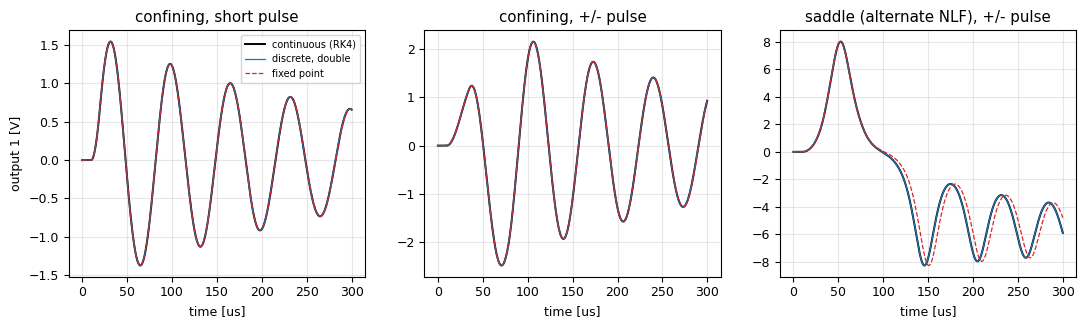

max deviation from the continuous reference, in % of the peak output
scenario                             peak[V] | whole run: TD   FP  | first 30 % of run: TD   FP
confining, short pulse                 1.55  |       0.66  1.58 |            0.66  0.53
confining, +/- pulse                   2.48  |       0.63  1.42 |            0.63  0.28
saddle (alternate NLF), +/- pulse      8.27  |       0.32 21.81 |            0.32  0.47


In [33]:
model = saddle.build_plant("psd"); scs = saddle.scenarios(); model.compile(scs, enable_noise=False, verbose=False)
names = ["confining, short pulse", "confining, +/- pulse", "saddle (alternate NLF), +/- pulse"]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2)); rows = []
for i, sc_i in enumerate(scs):
    tc, td, fp = model.sim_tc(sc_i, False), model.sim_td(sc_i, False), model.sim_tdfp(sc_i, False)
    t_us = tc[0].Time * 1e6
    ax[i].plot(t_us, tc[0].Data, "k", lw=1.4, label="continuous (RK4)"); ax[i].plot(t_us, td[0].Data, "C0", lw=.9, label="discrete, double"); ax[i].plot(t_us, fp[0].Data, "C3", lw=.9, ls="--", label="fixed point")
    ax[i].set(title=names[i], xlabel="time [us]", ylabel="output 1 [V]" if i == 0 else "")
    pk = np.max(np.abs(tc[0].Data)); n_ = len(tc[0].Data); early = slice(0, int(0.3 * n_))
    rows.append((names[i], pk, *[100 * np.max(np.abs(b[0].Data - tc[0].Data)) / pk for b in (td, fp)],
                 *[100 * np.max(np.abs(b[0].Data[early] - tc[0].Data[early])) / pk for b in (td, fp)]))
ax[0].legend(fontsize=7); plt.show()
print("max deviation from the continuous reference, in % of the peak output")
print("%-36s peak[V] | whole run: TD   FP  | first 30 %% of run: TD   FP" % "scenario")
for r in rows: print("%-36s %6.2f  |  %9.2f %5.2f |  %14.2f %5.2f" % r)

For the two *confining* scenarios all three engines agree to $\approx1$–$2\%$ of the peak; the fixed-point error is dominated by the quantised constants of §7.7.
In the **saddle** scenario the particle starts on the hilltop where the dynamics are *unstable*: any mismatch (integrator error $\sim(\Omega h)^2/6$, the $-0.077\%$ time-step error, constant rounding) is amplified by $e^{\Omega t}$ (e-fold time $1/\Omega\approx10.6\,\mu$s), so after a few tens of microseconds the trajectories drift apart *in phase* although their amplitudes
and qualitative behaviour agree (all three peak at 8.27 V). This is the *physics* of unstable systems, not a bug: point-wise comparison of chaotic-like trajectories is ill-conditioned, and this is exactly why a controller is needed.

### 8.3 The closed-loop experiment (paper Fig. 5)

`ClosedLoop` wires the two devices exactly as the paper's cables do, on an integer nanosecond schedule (controller 64 ns, simulator 144 ns, both advance on their least common multiple of 576 ns = 9 : 4 steps), with the fixed-point engines
on both sides and a 12-sample controller latency plus the simulator's 788 ns I/O latency in the loop. **This is the slow cell** (about 30 s).

In [34]:
def make_devices(noise_mode="psd", backend="fixed", ctrl_latency=11):
    mdl = saddle.build_plant(noise_mode); mdl.compile(saddle.scenarios(), enable_noise=False, verbose=False)
    plant = HILSimDevice(backend="double" if backend == "double" else "fixed")
    plant.connect(); plant.set_model(mdl); plant.send_config_update(); plant.set_nlfsw_iomask(0x00); plant.set_nlfsw_sel(0x00)
    plant.reset_simulation(); plant.start_simulation()
    ctrl = LQGDevice(fixed_point=(backend != "double"), io_latency_samples=ctrl_latency)
    ctrl.load_parameters(1, saddle.lqg_params(1)); ctrl.load_parameters(2, saddle.lqg_params(2)); ctrl.select_set(1)
    return ctrl, plant

def run_protocol(opposite=False, phase_ms=3.0, noise_mode="psd", verbose=True):
    ctrl, plant = make_devices(noise_mode); loop = ClosedLoop(ctrl, plant); T_ph = phase_ms * 1e-3; phases = []
    def phase(name, action=None):
        if action: action()
        r = loop.run(T_ph); r["name"] = name; n_ = len(r["t"]); s_ = slice(int(0.3 * n_), None)
        r["stats"] = dict(y=(np.std(r["y1"][s_]), np.std(r["y2"][s_])), u=(np.std(r["u1"][s_]), np.std(r["u2"][s_])), qmax=np.max(np.abs(r["q"][s_, 0])), qrms=np.std(r["q"][s_, 0]))
        phases.append(r)
        if verbose: print(f"{name:40s} y rms {r['stats']['y'][0]*1e3:8.2f} / {r['stats']['y'][1]*1e3:8.2f} mV | u rms {r['stats']['u'][0]*1e3:6.2f} / {r['stats']['u'][1]*1e3:6.2f} mV | q1 rms {r['stats']['qrms']*1e9:8.2f} nm | max|q1| {r['stats']['qmax']*1e9:9.1f} nm")
    phase("1 confining, no feedback")
    phase("2 confining, feedback (Set 1)", lambda: ctrl.enable_feedback(True))
    if not opposite:
        phase("3 confining, feedback (Set 2)", lambda: ctrl.select_set(2))
        phase("4 saddle,    feedback (Set 2)", lambda: plant.set_nlfsw_sel(0x02))
    else:
        phase("3' saddle,   feedback (Set 1)  WRONG ORDER", lambda: plant.set_nlfsw_sel(0x02))
    phase("5 saddle,    feedback OFF", lambda: ctrl.enable_feedback(False))
    return phases

t0 = time.time(); phases = run_protocol(); print("[%.0f s]" % (time.time() - t0))

1 confining, no feedback                 y rms   215.57 /    61.40 mV | u rms   0.00 /   0.00 mV | q1 rms    53.90 nm | max|q1|     123.1 nm
2 confining, feedback (Set 1)            y rms     9.31 /    16.58 mV | u rms   6.07 /  15.40 mV | q1 rms     2.31 nm | max|q1|       7.5 nm
3 confining, feedback (Set 2)            y rms     9.09 /    13.21 mV | u rms   6.66 /  12.20 mV | q1 rms     2.27 nm | max|q1|       8.3 nm
4 saddle,    feedback (Set 2)            y rms     9.60 /    14.09 mV | u rms   6.12 /  12.84 mV | q1 rms     2.39 nm | max|q1|       8.2 nm
5 saddle,    feedback OFF                y rms     0.00 /    45.03 mV | u rms   0.00 /   0.00 mV | q1 rms    27.51 nm | max|q1|    1582.2 nm
[7 s]


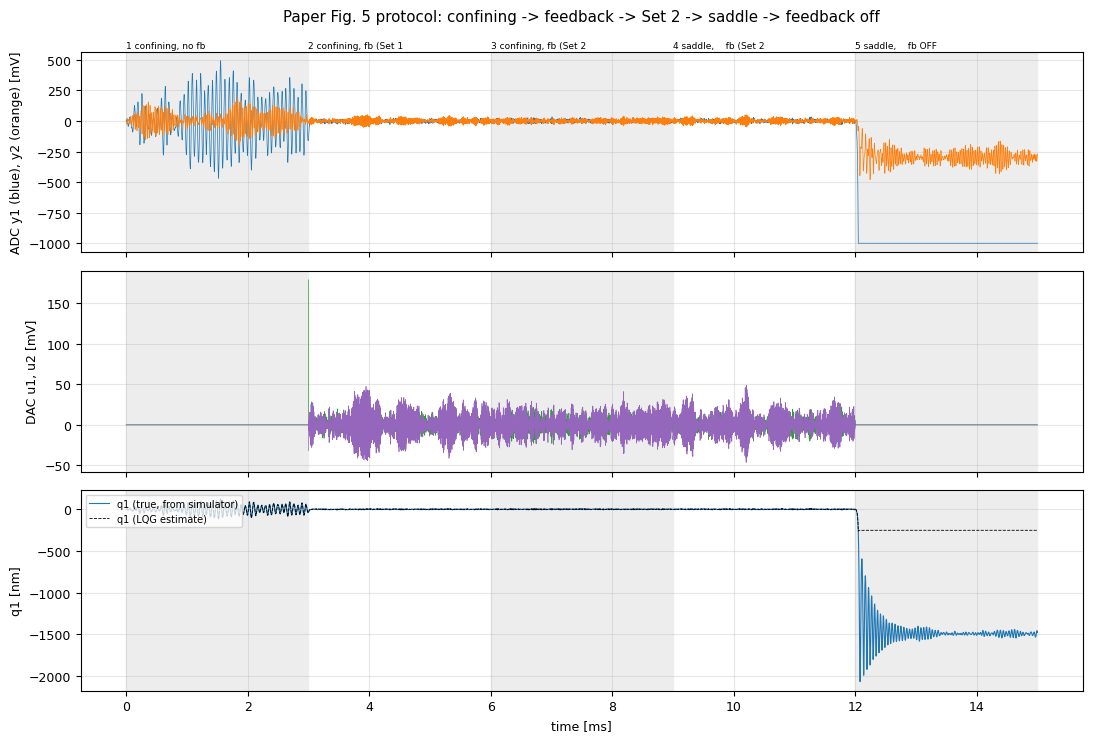

In [35]:
def plot_protocol(phases, title=""):
    fig, ax = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
    for i, r in enumerate(phases):
        t = r["t"] * 1e3
        ax[0].plot(t, r["y1"] * 1e3, "C0", lw=.5); ax[0].plot(t, r["y2"] * 1e3, "C1", lw=.5)
        ax[1].plot(t, r["u1"] * 1e3, "C2", lw=.5); ax[1].plot(t, r["u2"] * 1e3, "C4", lw=.5)
        ax[2].plot(t, r["q"][:, 0] * 1e9, "C0", lw=.8, label="q1 (true, from simulator)" if i == 0 else None); ax[2].plot(t, r["xhat"][:, 0] * 1e9, "k--", lw=.6, label="q1 (LQG estimate)" if i == 0 else None)
        if i % 2 == 0:
            for a_ in ax: a_.axvspan(t[0], t[-1], color="0.93")
        ax[0].text(t[0], 1.02, r["name"].replace("feedback", "fb")[:22], transform=ax[0].get_xaxis_transform(), fontsize=6.5)
    ax[0].set_ylabel("ADC y1 (blue), y2 (orange) [mV]"); ax[1].set_ylabel("DAC u1, u2 [mV]"); ax[2].set_ylabel("q1 [nm]"); ax[2].set_xlabel("time [ms]"); ax[2].legend(loc="upper left", fontsize=7)
    ax[0].set_title(title, pad=22); plt.tight_layout(); plt.show()
plot_protocol(phases, "Paper Fig. 5 protocol: confining -> feedback -> Set 2 -> saddle -> feedback off")

In [36]:
# how much cooling is that?  compare with the analytic free (thermal) motion of the simulator for the design noise P_w
P_w = saddle.P_W; Gam_s = saddle.GAMMA
q_free = np.sqrt(P_w / (2 * m_p**2 * Gam_s)) / O1                          # rms position of x' = v, v' = -Om^2 x - Gam v + w/m
blocks = np.array_split(phases[0]["q"][:, 0], 8)
print("free thermal rms position (analytic, P_w as PSD): %.1f nm" % (q_free * 1e9))
print("phase 1 measured over 8 consecutive windows of %.2f ms: %s nm  <- a short window of a slowly decorrelating signal fluctuates a lot" % (phase_ms_ := 3.0 / 8, np.round([b.std() * 1e9 for b in blocks], 0)))
print("phase 2 (feedback on): q1 rms = %.2f nm  ->  position variance reduced by a factor ~%.0f" % (phases[1]["stats"]["qrms"] * 1e9, (q_free / phases[1]["stats"]["qrms"])**2))
print("phase 5 (feedback off, saddle): max |q1| = %.2f um  (well positions +-%.2f um)" % (phases[4]["stats"]["qmax"] * 1e6, q0 * 1e6))

free thermal rms position (analytic, P_w as PSD): 33.9 nm
phase 1 measured over 8 consecutive windows of 0.38 ms: [23. 29. 44. 61. 66. 48. 42. 48.] nm  <- a short window of a slowly decorrelating signal fluctuates a lot
phase 2 (feedback on): q1 rms = 2.31 nm  ->  position variance reduced by a factor ~216
phase 5 (feedback off, saddle): max |q1| = 1.58 um  (well positions +-1.49 um)


**Reading the figure and table.** In phase 1 the particle diffuses freely; in phase 2 the LQG loop reduces the position variance by about two orders of magnitude (the control signal is only a few mV). Switching to Set 2, and then switching the simulator's potential to the saddle, leaves the loop *unchanged*:
the estimator and controller now hold the particle on top of an unstable hill (phase 4: rms position $\approx2$ nm although the free particle would fall away within microseconds). When the feedback is switched off (phase 5) the particle rolls off the hill
to $\approx1.6\,\mu$m, the position of the wells, as in the paper's Fig. 5. (In the top panel the ADC rails at $-1$ V once the particle is beyond $\approx250$ nm, so the LQG estimate, dashed in the bottom panel, freezes at that value: the converter range, not the algorithm, limits what the estimator can see.)

**A consistency check with the design's own prediction.** The GUI predicts the rms feedback signal from the model ($9.3$ / $10.4$ mV for Set 1). The simulated loop has *no* ADC noise by default (only 14-bit quantisation), whereas the design assumes $\sqrt{P_v/T_s}=7.9$ mV rms; the next cell compares.

In [37]:
def feedback_only(meas_noise, set_n=1, T_run=3e-3):
    ctrl, plant = make_devices(); ctrl.select_set(set_n); loop = ClosedLoop(ctrl, plant, meas_noise_rms=meas_noise)
    loop.run(0.3e-3); ctrl.enable_feedback(True); loop.run(0.5e-3); r = loop.run(T_run); s_ = slice(len(r["t"]) // 5, None)
    return np.std(r["u1"][s_]) * 1e3, np.std(r["u2"][s_]) * 1e3, np.std(r["q"][s_, 0]) * 1e9
sig_assumed = np.sqrt(4e-12 / 64e-9)
print("GUI-predicted feedback std (Set 1): %s mV;  design assumes ADC noise %.1f mV rms" % (np.round(np.diag(d_set[1].U_std) * 1e3, 1), sig_assumed * 1e3))
for mn in (0.0, sig_assumed):
    u1_, u2_, qr_ = feedback_only(mn); print("  simulated loop with %.1f mV ADC noise: u rms = %.1f / %.1f mV, q1 rms = %.2f nm" % (mn * 1e3, u1_, u2_, qr_))

GUI-predicted feedback std (Set 1): [ 9.3 10.4] mV;  design assumes ADC noise 7.9 mV rms
  simulated loop with 0.0 mV ADC noise: u rms = 5.6 / 13.5 mV, q1 rms = 2.28 nm
  simulated loop with 7.9 mV ADC noise: u rms = 12.9 / 22.9 mV, q1 rms = 2.90 nm


The prediction ($9$–$10$ mV) lies between the two simulations ($5.6/13.5$ mV without and $12.9/22.9$ mV with the assumed ADC noise): the right order of magnitude, but not an exact match. The GUI's number comes from a continuous-time covariance approximation,
whereas the simulation has discrete sampling, quantisation, latency and cross-talk between the axes — treat it as a guide for the DAC range, not a precise forecast.

### 8.4 The paper's warning: switching in the wrong order

The paper stresses that the controller must be switched to Set 2 **before** the potential changes; with the potential switched first the controller still assumes a confining potential. We run exactly that (phase 3′).

In [38]:
t0 = time.time(); phases_opp = run_protocol(opposite=True, phase_ms=2.0); print("[%.0f s]" % (time.time() - t0))

1 confining, no feedback                 y rms   218.89 /    59.11 mV | u rms   0.00 /   0.00 mV | q1 rms    54.73 nm | max|q1|     123.1 nm
2 confining, feedback (Set 1)            y rms     8.96 /    16.82 mV | u rms   5.95 /  15.80 mV | q1 rms     2.22 nm | max|q1|       7.2 nm
3' saddle,   feedback (Set 1)  WRONG ORDER y rms     9.75 /    14.92 mV | u rms   5.13 /  13.76 mV | q1 rms     2.42 nm | max|q1|       7.9 nm
5 saddle,    feedback OFF                y rms     0.00 /    53.75 mV | u rms   0.00 /   0.00 mV | q1 rms    38.23 nm | max|q1|    1637.0 nm
[4 s]


**In this model the wrong order does *not* destabilise the loop.** To understand why, we analyse the *linear* closed loop instead of simulating: the true plant (Set-2 model, an unstable hilltop) driven by the compensator built for Set 1 (or Set 2), with the state $(x,\hat x,u_{k-1},\dots,u_{k-d})$ as in §5.4, except that the plant matrices and the estimator's model matrices may now differ. The estimator bandwidth is $(1-|z|)/T_s\approx5.8\times10^{5}$ rad/s,
six times the instability rate $\Omega=9.4\times10^{4}$ rad/s: the measurements dominate the (wrong-signed) model, so the mismatch is corrected quickly.

In [39]:
def loop_radius(Ap, Bp, Ac, Bc, Cm, K_, L_, d):
    """Spectral radius of the closed loop: true plant (Ap,Bp) with delay d, compensator built from the model (Ac,Bc)."""
    n, m_ = Ap.shape[0], Bp.shape[1]; Nn_ = 2 * n + m_ * d; M = np.zeros((Nn_, Nn_)); M[:n, :n] = Ap
    if d == 0: M[:n, n:2*n] = -Bp @ K_
    else:      M[:n, 2*n + m_*(d-1): 2*n + m_*d] = Bp
    M[n:2*n, :n] = L_ @ Cm; M[n:2*n, n:2*n] = Ac - L_ @ Cm - Bc @ K_
    if d >= 1:
        M[2*n: 2*n + m_, n:2*n] = -K_
        for i in range(1, d): M[2*n + m_*i: 2*n + m_*(i+1), 2*n + m_*(i-1): 2*n + m_*i] = np.eye(m_)
    return np.abs(np.linalg.eigvals(M)).max()
D1, D2 = d_set[1], d_set[2]
rows = []
print("spectral radius of the closed loop (stable if < 1);  d = extra samples of unmodelled delay")
print("   d | total ~ ns | matched: Set 2 on saddle | WRONG ORDER: Set 1 on saddle | Set 1 on confining")
for d_ in (0, 8, 16, 20, 22, 23, 24, 28, 36):
    r2 = loop_radius(D2.Ad, D2.Bd, D2.Ad, D2.Bd, D2.C, D2.K_used, D2.Ld, d_)
    r12 = loop_radius(D2.Ad, D2.Bd, D1.Ad, D1.Bd, D1.C, D1.K_used, D1.Ld, d_)
    r11 = loop_radius(D1.Ad, D1.Bd, D1.Ad, D1.Bd, D1.C, D1.K_used, D1.Ld, d_)
    rows.append((d_, r2, r12, r11)); print(f"{d_:4d} | {(d_+1)*64:9d}  | {r2:16.4f} {'UNSTABLE' if r2 >= 1 else '        '} | {r12:16.4f} {'UNSTABLE' if r12 >= 1 else '        '}        | {r11:.4f} {'UNSTABLE' if r11 >= 1 else ''}")
d_crit = next(d_ for d_ in range(0, 60) if loop_radius(D2.Ad, D2.Bd, D2.Ad, D2.Bd, D2.C, D2.K_used, D2.Ld, d_) >= 1)
print("\nlinear analysis: instability sets in at d = %d extra samples (total ~%.2f us), for the matched AND the mismatched controller" % (d_crit, (d_crit + 1) * 64e-3))

spectral radius of the closed loop (stable if < 1);  d = extra samples of unmodelled delay
   d | total ~ ns | matched: Set 2 on saddle | WRONG ORDER: Set 1 on saddle | Set 1 on confining
   0 |        64  |           0.9940          |           0.9963                 | 0.9940 
   8 |       576  |           0.9940          |           0.9963                 | 0.9941 
  16 |      1088  |           0.9940          |           0.9963                 | 0.9942 
  20 |      1344  |           0.9979          |           0.9979                 | 0.9979 
  22 |      1472  |           0.9995          |           0.9994                 | 0.9994 
  23 |      1536  |           1.0001 UNSTABLE |           1.0001 UNSTABLE        | 1.0001 UNSTABLE
  24 |      1600  |           1.0008 UNSTABLE |           1.0008 UNSTABLE        | 1.0008 UNSTABLE
  28 |      1856  |           1.0029 UNSTABLE |           1.0029 UNSTABLE        | 1.0029 UNSTABLE
  36 |      2368  |           1.0057 UNSTABLE |           1.

The linear analysis agrees with the simulation. Set 1 running on the saddle is *stable* (radius $0.9963$ against $0.9940$ for the matched design — only slightly slower), and above all **the stability limit is set by the loop delay and is identical for both controllers**.
So in this model the ordering rule is a *precaution* rather than a hard requirement: the LQR gain is enormous compared with the hilltop's negative stiffness ($\Omega^2\approx9\times10^9\,\mathrm{s^{-2}}$ versus a closed-loop stiffness of order $(10^{7})^2$),
and the estimator is fast enough to absorb the model error. Whether the real hardware setup, with its other imperfections, is more sensitive is something this software model cannot say.

### 8.5 How much loop delay can the design tolerate?

The linear analysis says instability starts at about $d=23$ extra samples, i.e. a total loop latency of roughly $1.5\,\mu$s. The full simulation (fixed-point arithmetic, the simulator's 144 ns update grid, 14-bit converters) gives a very similar answer:

extra   0 samples | total loop latency ~    852 ns | y1 rms      7.8 mV | max|q1|        6 nm  
extra   5 samples | total loop latency ~   1172 ns | y1 rms      8.3 mV | max|q1|        6 nm  
extra  11 samples | total loop latency ~   1556 ns | y1 rms     10.3 mV | max|q1|        7 nm  
extra  14 samples | total loop latency ~   1748 ns | y1 rms    182.6 mV | max|q1|       68 nm  
extra  17 samples | total loop latency ~   1940 ns | y1 rms    750.6 mV | max|q1|      274 nm  <-- unstable
extra  20 samples | total loop latency ~   2132 ns | y1 rms    790.5 mV | max|q1|      318 nm  <-- unstable
extra  26 samples | total loop latency ~   2516 ns | y1 rms    836.3 mV | max|q1|      403 nm  <-- unstable


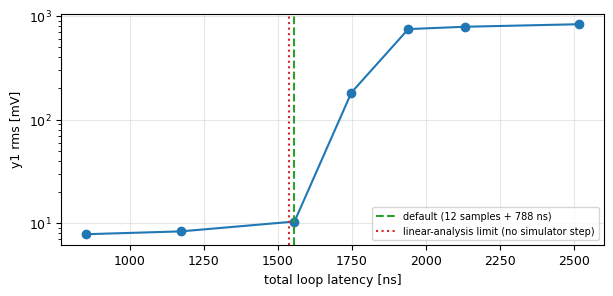

In [40]:
def latency_run(extra, T_run=1.2e-3):
    ctrl, plant = make_devices(ctrl_latency=extra); ctrl.select_set(2); plant.set_nlfsw_sel(0x02)
    loop = ClosedLoop(ctrl, plant); loop.run(0.2e-3); ctrl.enable_feedback(True); r = loop.run(T_run); s_ = slice(len(r["t"]) // 3, None)
    return (extra + 1) * 64e-9 + plant.io_latency_s, np.std(r["y1"][s_]), np.max(np.abs(r["q"][s_, 0]))
lat_res = []
for extra in (0, 5, 11, 14, 17, 20, 26):
    tot, y_, q_ = latency_run(extra); lat_res.append((extra, tot, y_, q_))
    print(f"extra {extra:3d} samples | total loop latency ~ {tot*1e9:6.0f} ns | y1 rms {y_*1e3:8.1f} mV | max|q1| {q_*1e9:8.0f} nm  {'<-- unstable' if q_ > 100e-9 else ''}")
fig, ax = plt.subplots(figsize=(7, 3.0)); tt_ = [r[1] * 1e9 for r in lat_res]
ax.semilogy(tt_, [r[2] * 1e3 for r in lat_res], "o-"); ax.axvline(1556, color="C2", ls="--", label="default (12 samples + 788 ns)"); ax.axvline((d_crit + 1) * 64, color="C3", ls=":", label="linear-analysis limit (no simulator step)")
ax.set(xlabel="total loop latency [ns]", ylabel="y1 rms [mV]"); ax.legend(fontsize=7); plt.show()

The nominal configuration (≈1.56 µs of total latency under the assumptions made here: 12 controller samples + the simulator's 788 ns) is **stable but only about 15% away from the stability limit**; at 1.75 µs the loop is already growing and at 1.9 µs it saturates the converters.
The margin, and hence the practical bandwidth of the paper's controller, is set almost entirely by latency — which is why the paper's authors work to minimise pipeline stages, and why a delay-aware design (§5.4) would buy real headroom.
Note that the latency figures are assumptions of this software model (they come from the authors' Simulink test-bench constants), not measurements.

### 8.6 The noise semantics: PSD or variance?

The last paper-vs-code subtlety. The paper's $P_w=3.2\times10^{-34}$ is a **power spectral density** in the Kalman design (§2: $W_d$ is derived from it). But the MATLAB simulator library interprets `set_noise_power(p)` as a **per-step variance** (§7.4).
Fed the same number, the two mean radically different physical noise:

In [41]:
Nn2 = 60000; sc_free = Scenario.from_arrays(np.zeros(Nn2), np.zeros(Nn2), 1e-7); lsb = 2.0 / 2**14
print("14-bit ADC LSB = %.0f uV" % (lsb * 1e6))
for mode in ("psd", "variance"):
    mdl = saddle.build_plant(mode); mdl.compile(saddle.scenarios(), enable_noise=False, verbose=False)
    o_ = mdl.sim_td(sc_free, True); y1_, y2_ = o_[0].Data[2000:], o_[1].Data[2000:]
    print(f"noise_mode = {mode:8s}: y1 rms {y1_.std()*1e3:10.4f} mV, y2 rms {y2_.std()*1e3:10.4f} mV | analytic steady state {np.round(np.array(saddle.steady_state_rms(mode))*1e3, 4)} mV")

14-bit ADC LSB = 122 uV
noise_mode = psd     : y1 rms   151.6390 mV, y2 rms    53.4753 mV | analytic steady state [135.4531  58.0513] mV
noise_mode = variance: y1 rms     0.0575 mV, y2 rms     0.0203 mV | analytic steady state [0.0514 0.022 ] mV


With `psd` the free motion is $\approx140$ mV rms (the analytic $135$ mV; the extra few percent is statistical), matching what the Kalman filter was designed for. With `variance` and the *same number* the motion is $\approx0.05$ mV — less than **half of one ADC least-significant bit** (122 µV) — so the simulated
particle is effectively frozen and the "cooling" demonstration would be meaningless. `pylqg` defaults to `variance` (library semantics) but the demos use `psd`. When reproducing the paper's example with the original MATLAB library, keep in mind that the noise power must be *pre-multiplied by $1/T_s$*
(as the authors themselves do in their single-particle example, next section).

---
## 9. Second example: a single particle in a nonlinear double well (HIL only)

The authors' repository contains a second script, `hilsim_particle_example.m`, which exercises the *simulator alone* on a single nonlinear axis with realistic thermal noise, and no controller.
The parameters: $m=9.77\times10^{-18}$ kg, quality factor 200, temperature 293 K, and a **quartic double well** $\ddot q=-(\alpha q^3+\beta q)-\Gamma\dot q+\dots$ with $\beta=-|k|/m$ (an inverted quadratic term), stiffness $k=-9.07\times10^{-7}$ N/m and an empirical
$\alpha=0.1|k|/(s^2m)$, $s=5\times10^{-8}$ m. Slice 1 uses this nonlinear force (with an alternate table with $2\beta$: a *deeper* well), slice 2 is a linear confining axis with stiffness $2|k|$. We rebuild it in `pylqg`:

In [42]:
mp_, k_ = 9.77e-18, -9.07067175478047e-07; Cf_, Ce_, Q_ = 6.1794e-12, 4697940.12339623, 200.0
gam_p = np.sqrt(abs(k_) * mp_) / Q_                      # gamma = sqrt(|k| m)/Q
noise_pow = gam_p * kB * 293.0                           # the authors' 'noise_power'
alpha_p = 0.1 * abs(k_) / ((0.5e-7)**2 * mp_); beta_p = -abs(k_) / mp_
f_p  = lambda q: alpha_p * q**3 + beta_p * q             # double well  (barrier ~ 1.4 kT)
fa_p = lambda q: alpha_p * q**3 + 2 * beta_p * q         # alternate: deeper wells (barrier ~ 5.6 kT)
part = HILSimModel()
for ns in part.noise_sources: ns.set_noise_power(noise_pow * 1e7)          # <-- the authors' hand-made conversion; see below
part.input_matrix.set_matrix([[Cf_ / 5, 0, 1]] * 3)
part.output_slices[0].linear_factors = [Ce_ / 5, 0, 0]; part.output_slices[1].linear_factors = [0, Ce_ / 5, 0]
for j in (0, 2):
    s_ = part.slices[j]; s_.u_factor = 1 / mp_; s_.x_nlf.set_func(f_p); s_.x_nlf.set_func_alternate(fa_p); s_.x_factor = -1; s_.xdot_factor = -gam_p / mp_
s_ = part.slices[1]; s_.u_factor = 1 / mp_; s_.x_factor = -2 * abs(k_) / mp_; s_.xdot_factor = -gam_p / mp_

n_p = 3000; a_ = np.zeros(n_p); a_[101:199] = 1.0; scp0 = Scenario.from_arrays(a_, np.zeros(n_p), 1e-7)
a_ = np.zeros(n_p); a_[101:352] = 0.5; a_[352:779] = -0.5; scp1 = Scenario.from_arrays(a_, np.zeros(n_p), 1e-7); scp1a = scp1.copy()
for j in range(3): scp1a.nlf_alternate_switch[j]["x_nlf"] = 1
part.compile([scp0, scp1, scp1a], enable_noise=False, verbose=False)

q_w = np.sqrt(-beta_p / alpha_p)
print("gamma = %.3e kg/s, Gamma = %.0f /s | wells at +-%.3f um (= +-%.3f V at the output) | barrier: primary %.2f kT, alternate %.2f kT" % (gam_p, gam_p / mp_, q_w * 1e6, q_w * Ce_ / 5, mp_ * beta_p**2 / (4 * alpha_p) / (kB * 293), mp_ * (2 * beta_p)**2 / (4 * alpha_p) / (kB * 293)))
print("quantisation issues at compile:", part.quantisation_issues or "none")
print("\nthe authors' noise setting:  per-step variance = gamma kB T x 1e7 = %.3e N^2" % (noise_pow * 1e7))
print("  as a PSD (x 144 ns) = %.3e N^2 s   vs   thermal 2 gamma kB T = %.3e  ->  ratio %.2f  (effective temperature %.0f K)" % (noise_pow * 1e7 * 144e-9, 2 * gam_p * kB * 293, noise_pow * 1e7 * 144e-9 / (2 * gam_p * kB * 293), 293 * noise_pow * 1e7 * 144e-9 / (2 * gam_p * kB * 293)))
print("  and 1/Ts = %.2e = 1e7 / 1.44: their factor 1e7 is a hand-rounded 1/Ts (times 1.44), i.e. exactly the PSD -> variance conversion of Section 7.4" % (1 / 144e-9))

gamma = 1.488e-14 kg/s, Gamma = 1523 /s | wells at +-0.158 um (= +-0.149 V at the output) | barrier: primary 1.40 kT, alternate 5.61 kT
quantisation issues at compile: none

the authors' noise setting:  per-step variance = gamma kB T x 1e7 = 6.021e-28 N^2
  as a PSD (x 144 ns) = 8.671e-35 N^2 s   vs   thermal 2 gamma kB T = 1.204e-34  ->  ratio 0.72  (effective temperature 211 K)
  and 1/Ts = 6.94e+06 = 1e7 / 1.44: their factor 1e7 is a hand-rounded 1/Ts (times 1.44), i.e. exactly the PSD -> variance conversion of Section 7.4


So the authors **do** convert a PSD into a per-step variance by hand (the factor $10^7\approx1/T_s\times1.44$), which confirms the reading of §8.6: the library expects variances, the physics is stated as PSDs. Their choice corresponds to $0.72\times$ the thermal PSD $2\gamma k_BT$ (an effective temperature of 211 K).

### 9.1 Scenario check: three backends on the nonlinear well

The particle is kicked from the top of the barrier and rings down in a well. Here the oscillation is *large* and fast: the ring-down period is about 5.9 µs, i.e. $\Omega_{\rm eff}h\approx0.15$, five times larger than in the paper's saddle example. The discrete engines then deviate visibly from the continuous reference:

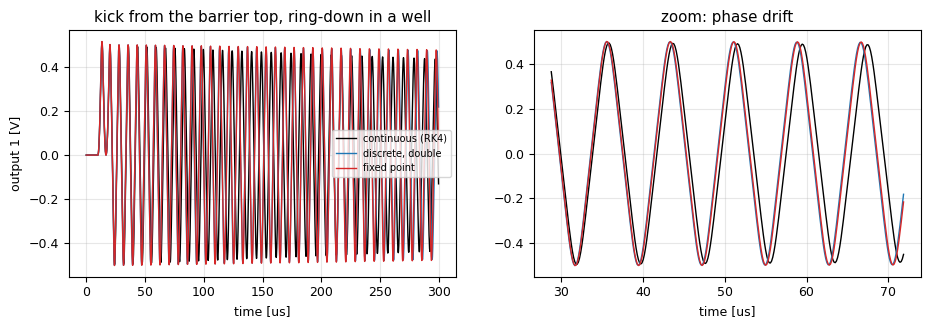

continuous (RK4)  : ring-down period  5.870 us | amplitude near the end 0.454 V
discrete, double  : ring-down period  5.541 us | amplitude near the end 0.483 V
fixed point       : ring-down period  5.525 us | amplitude near the end 0.486 V
small-signal well frequency sqrt(2|beta|)/2pi = 68.6 kHz; the large-amplitude ring-down (hardening quartic) is ~2.5x faster
point-wise max deviation from the continuous reference over the whole run: discrete 187 %, fixed point 187 % of the peak
harmonic-oscillator error law of Section 7.2 at this Om*h:  frequency error (Om h)^2/6 = 0.40 %  (observed period difference: 5.9 %)


In [43]:
tc, td, fp = [f(scp0, False)[0] for f in (part.sim_tc, part.sim_td, part.sim_tdfp)]
def ring_stats(y, dt=1e-7):
    y = y[300:]; i = np.where((y[:-1] < 0) & (y[1:] >= 0))[0]
    per = np.mean(np.diff(i + (-y[i]) / (y[i + 1] - y[i]))) * dt if len(i) > 2 else np.nan
    return per, np.max(np.abs(y[-600:-300]))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for nm, r_, c_ in (("continuous (RK4)", tc, "k"), ("discrete, double", td, "C0"), ("fixed point", fp, "C3")):
    ax[0].plot(r_.Time * 1e6, r_.Data, c_, lw=1, label=nm); ax[1].plot(r_.Time[200:500] * 1e6, r_.Data[200:500], c_, lw=1)
ax[0].set(xlabel="time [us]", ylabel="output 1 [V]", title="kick from the barrier top, ring-down in a well"); ax[0].legend(fontsize=7); ax[1].set(xlabel="time [us]", title="zoom: phase drift")
plt.show()
for nm, r_ in (("continuous (RK4)", tc), ("discrete, double", td), ("fixed point", fp)):
    per, amp = ring_stats(r_.Data); print(f"{nm:18s}: ring-down period {per*1e6:6.3f} us | amplitude near the end {amp:.3f} V")
print("small-signal well frequency sqrt(2|beta|)/2pi = %.1f kHz; the large-amplitude ring-down (hardening quartic) is ~%.1fx faster" % (np.sqrt(2 * abs(beta_p)) / 2 / np.pi / 1e3, 1 / ring_stats(tc.Data)[0] / (np.sqrt(2 * abs(beta_p)) / 2 / np.pi)))
pk_ = np.abs(tc.Data).max()
print("point-wise max deviation from the continuous reference over the whole run: discrete %.0f %%, fixed point %.0f %% of the peak" % (100 * np.abs(td.Data - tc.Data).max() / pk_, 100 * np.abs(fp.Data - tc.Data).max() / pk_))
print("harmonic-oscillator error law of Section 7.2 at this Om*h:  frequency error (Om h)^2/6 = %.2f %%  (observed period difference: %.1f %%)" % (100 * (2 * np.pi / 5.87e-6 * 144e-9)**2 / 6, 100 * (5.870 / ring_stats(td.Data)[0] / 1e6 - 1)))

The three engines agree qualitatively (fall into a well, ring down, similar amplitude) but their periods differ by about 6%, so a point-wise comparison over $\sim50$ oscillations (the $\approx187\%$ maximum deviation the cell prints) is meaningless: a small period error accumulates into a phase error of many radians.
Note what the numbers do **not** say: the harmonic-oscillator error law of §7.2 predicts only $\approx0.4\%$ at $\Omega_{\rm eff}h\approx0.15$, more than an order of magnitude below the observed 6%, so it does not explain the discrepancy by itself. Plausible additional causes are the nonlinear force being evaluated one step late and the strong amplitude dependence of the period in a hardening quartic well, but I did not isolate them here.
The practical rule of thumb from both examples: in the paper's saddle example ($\Omega h\approx0.03$) the engines agree to 1–2% on the confining scenarios (§8.2), whereas at $\Omega h\approx0.15$ the periods differ by about 6%; **keep $\Omega h$ small (below about 0.05) if the simulator's accuracy matters**.

### 9.2 Thermal hopping between the wells (noise on, potential switching)

With the authors' noise level (an effective temperature of $0.72\,T$) the primary well has a barrier of only $1.4\,k_BT\approx1.9\,k_BT_{\rm eff}$, so the particle should cross between the wells freely; after switching to the *alternate* table (barrier $5.6\,k_BT\approx7.8\,k_BT_{\rm eff}$) hopping should be rare.
We run 300,000 simulator steps (30 ms) of the fixed-point engine in each configuration. The particle starts on top of the barrier with the full barrier energy, and for the first millisecond or two it *sloshes* across both wells while that energy decays at $\Gamma\approx1.5\times10^3\,\mathrm{s^{-1}}$; that transient is not thermal hopping, so we discard the first 3 ms before counting.

primary well (1.4 kT)     :  551 well-to-well crossings in 17.8 ms (mean interval 29 us), of which 18 are trapped episodes > 100 us (longest 2378 us) | fraction of time on the positive side 0.49
alternate well (5.6 kT)   :    0 well-to-well crossings in 17.8 ms (mean interval nan us), of which 0 are trapped episodes > 100 us (longest 0 us) | fraction of time on the positive side 1.00


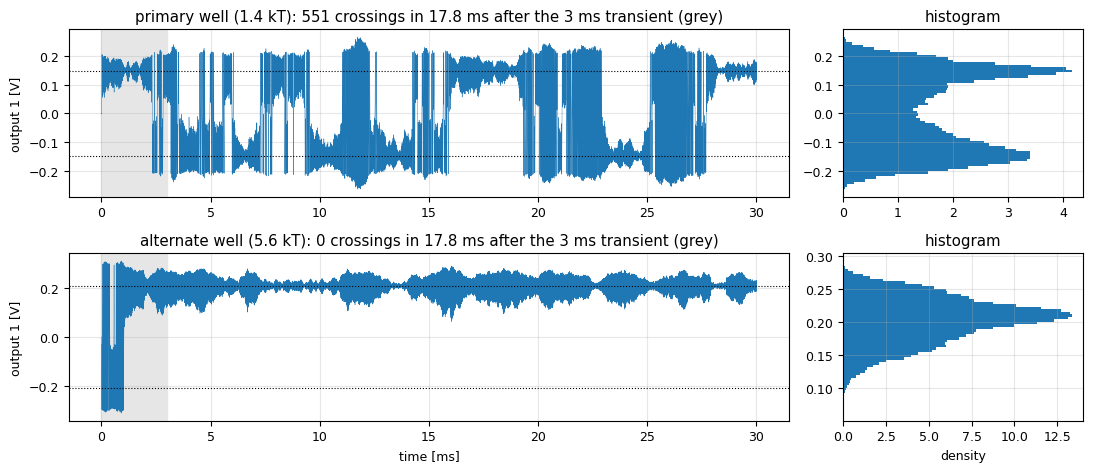

[4 s]
Arrhenius-type expectation for the alternate table: rate ratio exp(-(5.6-1.4)/0.72) = 2.9e-03 of the primary rate


In [44]:
Nl = 300000; burn = 30000; sl = Scenario.from_arrays(np.zeros(Nl), np.zeros(Nl), 1e-7); sl_alt = sl.copy()
for j in range(3): sl_alt.nlf_alternate_switch[j]["x_nlf"] = 1
def count_hops(y, thr, burn_in):
    ys = np.convolve(y, np.ones(100) / 100, "same")[burn_in:]; state = 0; last = 0; dwell = []          # 10 us smoothing, hysteresis-free threshold at half a well
    for k, v in enumerate(ys):
        s_new = 1 if v > thr else (-1 if v < -thr else 0)
        if s_new != 0 and s_new != state:
            if state != 0: dwell.append(k - last)
            state = s_new; last = k
    return len(dwell), (np.mean(dwell) * 0.1 if dwell else np.nan), len(ys) * 0.1e-3, np.array(dwell) * 0.1      # dwell times in us (output grid is 100 ns)
t0 = time.time(); fig, ax = plt.subplots(2, 2, figsize=(11, 4.8), gridspec_kw=dict(width_ratios=[3, 1]))
for i, (nm, sc_) in enumerate((("primary well (1.4 kT)", sl), ("alternate well (5.6 kT)", sl_alt))):
    o_ = part.sim_tdfp(sc_, True)[0]; tt, yy = o_.Time, o_.Data
    wl = q_w * Ce_ / 5 * (1 if i == 0 else np.sqrt(2)); hops, dw, T_ms, dwells = count_hops(yy, 0.5 * wl, burn)
    ax[i, 0].plot(tt * 1e3, yy, lw=.3); ax[i, 0].axvspan(0, burn * 1e-4, color="0.9"); ax[i, 0].axhline(wl, color="k", ls=":", lw=.8); ax[i, 0].axhline(-wl, color="k", ls=":", lw=.8)
    ax[i, 0].set(ylabel="output 1 [V]", title=f"{nm}: {hops} crossings in {T_ms:.1f} ms after the 3 ms transient (grey)")
    ax[i, 1].hist(yy[burn:], bins=60, orientation="horizontal", density=True); ax[i, 1].set(title="histogram")
    trapped = dwells[dwells > 100]
    print(f"{nm:26s}: {hops:4d} well-to-well crossings in {T_ms:.1f} ms (mean interval {dw:.0f} us), of which {len(trapped)} are trapped episodes > 100 us (longest {trapped.max() if len(trapped) else 0:.0f} us) | fraction of time on the positive side {np.mean(yy[burn:] > 0):.2f}")
ax[1, 0].set_xlabel("time [ms]"); ax[1, 1].set_xlabel("density"); plt.tight_layout(); plt.show(); print("[%.0f s]" % (time.time() - t0))
print("Arrhenius-type expectation for the alternate table: rate ratio exp(-(5.6-1.4)/0.72) = %.1e of the primary rate" % np.exp(-(5.61 - 1.40) / 0.72))

The primary table, whose barrier is barely above the thermal energy, lets the particle cross between the wells constantly: several hundred crossings in 18 ms. But the trace shows these are **not independent thermal hops**. With $Q=200$ the damping ($\Gamma\approx1.5\times10^{3}\,\mathrm{s^{-1}}$) is tiny compared with the in-well oscillation frequency ($\sim10^{5}$ Hz): the dynamics are in the *low-friction regime*.
Once the particle has gathered enough energy it crosses the barrier many times in a row (the dense bursts, with a mean interval of $\approx30\,\mu$s) until that energy has decayed, and only then is it trapped in one well, for up to a few milliseconds (the cell counts the trapped episodes longer than 100 µs separately). Both wells are visited equally and the histogram is bimodal at $\pm0.15$ V.
With the alternate table the barrier is $\approx4\,k_BT$ higher and the crossings disappear: the particle stays in one well for the whole record, sitting $\sqrt2\times$ further out (histogram peak at $\approx0.21$ V). An Arrhenius-type estimate ($e^{-(5.6-1.4)/0.72}\approx3\times10^{-3}$ of the primary rate) predicts at most a hop or two in 18 ms, consistent with none.
This is the **switchable-potential** behaviour the simulator was built for: the alternate lookup table is selected at run time (in hardware by a 3-bit mask or external inputs), emulating a trap whose barrier is raised while the controller is running.

---
## 10. How fast could a general-purpose PC run this controller?

The paper's controller runs at 15.625 MHz on an FPGA. A natural question is what a PC could do instead. The answer depends on *what the PC is asked to do*, and the three cases differ by orders of magnitude:

1. **Simulating** the loop (as in this notebook) — limited by the Python implementation;
2. **Computing** the controller update in compiled code — limited by the CPU, which is *very* fast for a 7-state filter;
3. **Closing a real loop** through converters — limited not by computation but by **latency and jitter** of the I/O path and the operating system.

Cases 1 and 2 are measured below (so the numbers depend on the machine that runs this notebook; the values printed in the saved copy were obtained on a single core of a 2.1 GHz Xeon virtual machine, which is probably slower than your desktop).
Case 3 is analysed with the delay-margin machinery of §5.4 and §8.5.

### 10.1 Compute speed: Python and compiled code

In [45]:
import subprocess, shutil, tempfile, platform, pathlib
def cpu_name():
    try:
        return next(l.split(":", 1)[1].strip() for l in open("/proc/cpuinfo") if l.startswith("model name"))
    except Exception:
        return platform.processor() or platform.machine()
print("this machine:", cpu_name())

def us_per_step(step, n=20000, warm=2000):
    for _ in range(warm): step()
    t0 = time.perf_counter()
    for _ in range(n): step()
    return (time.perf_counter() - t0) / n * 1e6

bench = {}
y_probe = np.array([0.01, 0.005])
core_fx = LQGCore(cfg); core_fl = LQGCoreFloat(d1, feedback=True)
bench["pylqg LQGCore (bit-exact fixed point, Python)"] = us_per_step(lambda: core_fx.step(y_probe), n=8000)
bench["pylqg LQGCoreFloat (double precision, Python)"] = us_per_step(lambda: core_fl.step(y_probe))
for n_ in (4, 7):
    Fm, Bm, Lm, Km = (np.random.default_rng(0).random(s_) * 0.1 for s_ in ((n_, n_), (n_, 2), (n_, 2), (2, n_))); xs = np.zeros(n_)
    def plain(Fm=Fm, Bm=Bm, Lm=Lm, Km=Km):
        global xs
        u_ = Km @ xs; xs = Fm @ xs + Bm @ u_ + Lm @ y_probe
    bench[f"plain NumPy predictor loop, {n_} states"] = us_per_step(plain, n=50000)
for name, us in bench.items(): print(f"  {name:50s}: {us:7.2f} us/step  ->  {1e3/us:8.1f} kHz")

this machine: arm
  pylqg LQGCore (bit-exact fixed point, Python)     :   25.18 us/step  ->      39.7 kHz
  pylqg LQGCoreFloat (double precision, Python)     :    3.26 us/step  ->     307.0 kHz
  plain NumPy predictor loop, 4 states              :    2.00 us/step  ->     498.8 kHz
  plain NumPy predictor loop, 7 states              :    1.97 us/step  ->     506.7 kHz


In [46]:
# the same update in C (optional: needs a C compiler; skipped gracefully if there is none)
C_SRC = r"""
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#define N 7
#define NI 2
#define NO 2
static double F[N][N], B[N][NI], L[N][NO], K[NI][N];
static double now(){struct timespec t; clock_gettime(CLOCK_MONOTONIC,&t); return t.tv_sec+1e-9*t.tv_nsec;}
int main(int argc, char**argv){
  long steps = argc > 1 ? atol(argv[1]) : 50000000; srand(1);
  for(int i=0;i<N;i++){for(int j=0;j<N;j++)F[i][j]=0.1*rand()/RAND_MAX; for(int j=0;j<NI;j++)B[i][j]=0.1*rand()/RAND_MAX; for(int j=0;j<NO;j++)L[i][j]=0.1*rand()/RAND_MAX;}
  for(int i=0;i<NI;i++)for(int j=0;j<N;j++)K[i][j]=0.1*rand()/RAND_MAX;
  static double y[1024][NO]; for(int k=0;k<1024;k++)for(int j=0;j<NO;j++)y[k][j]=0.01*rand()/RAND_MAX;
  double x[N]={0}, u[NI], sink=0; double t0=now();
  for(long k=0;k<steps;k++){
    const double*yk=y[k&1023];
    for(int i=0;i<NI;i++){double s=0;for(int j=0;j<N;j++)s+=K[i][j]*x[j];u[i]=-s;}
    double xn[N];
    for(int i=0;i<N;i++){double s=0;for(int j=0;j<N;j++)s+=F[i][j]*x[j];
      for(int j=0;j<NI;j++)s+=B[i][j]*u[j]; for(int j=0;j<NO;j++)s+=L[i][j]*yk[j]; xn[i]=s;}
    for(int i=0;i<N;i++)x[i]=xn[i]; sink+=u[0];
  }
  double dt=now()-t0; printf("%.3f %g\n", dt/steps*1e9, sink); return 0;
}
"""
cc = shutil.which("gcc") or shutil.which("cc") or shutil.which("clang")
c_bench = {}
if cc is None:
    print("no C compiler found - skipping the compiled benchmark (the figures for this machine would be ~20-40 ns/step, see the text)")
else:
    tmp = pathlib.Path(tempfile.mkdtemp()); (tmp / "lqg.c").write_text(C_SRC)
    for label, flags in (("C, -O2", ["-O2"]), ("C, -O3 -march=native", ["-O3", "-march=native"])):
        exe = tmp / ("lqg_" + label.replace(" ", "").replace(",", "_").replace("-", ""))
        subprocess.run([cc, *flags, str(tmp / "lqg.c"), "-o", str(exe)], check=True)
        ns = float(subprocess.run([str(exe), "30000000"], capture_output=True, text=True, check=True).stdout.split()[0])
        c_bench[label] = ns; print(f"  {label + ' (7 states, 2 in / 2 out, double)':50s}: {ns:7.1f} ns/step  ->  {1e3/ns:8.1f} MHz")

  C, -O2 (7 states, 2 in / 2 out, double)           :    13.9 ns/step  ->      71.8 MHz
  C, -O3 -march=native (7 states, 2 in / 2 out, double):    11.4 ns/step  ->      87.6 MHz


In [47]:
# closed-loop *simulation* speed: controller (64 ns) + HIL simulator (144 ns), both fixed point, in Python
ctrl_b, plant_b = make_devices(); ctrl_b.enable_feedback(True); loop_b = ClosedLoop(ctrl_b, plant_b)
T_sim = 0.5e-3; t0 = time.perf_counter(); loop_b.run(T_sim); wall = time.perf_counter() - t0
print("simulated %.1f ms of the closed loop in %.2f s  ->  %.0fx slower than real time; %.1f k controller steps per second" % (T_sim * 1e3, wall, wall / T_sim, T_sim / 64e-9 / wall / 1e3))

simulated 0.5 ms of the closed loop in 0.25 s  ->  499x slower than real time; 31.3 k controller steps per second


**Reading the numbers.**

* The bit-exact fixed-point Python model runs at about 20 kHz; the double-precision twin and a plain NumPy loop at roughly 100–250 kHz (dominated by interpreter and array-call overhead, hence the *same* time for 4 and 7 states). None of this is meant to be fast; the code favours clarity and bit-exactness.
* The **arithmetic itself is tiny** — about 90 multiply-adds per update — and in compiled code costs a few tens of nanoseconds, i.e. **tens of MHz**, the same order as (or above) the FPGA's 15.6 MHz. Computation is therefore *not* what limits a PC.
* A full closed-loop simulation with both boards costs roughly a thousand times real time in Python.

### 10.2 Closing a real loop through a PC: the limit is latency, not computation

Between the ADC and DAC of a PC-based controller lie the converter, the bus, the driver and the operating system scheduler. Typical orders of magnitude (general engineering knowledge; **not measured here**):

| I/O path | typical loop latency / jitter |
|---|---|
| USB DAQ, ordinary OS | $\sim1$ ms |
| PCIe DAQ, real-time Linux, isolated core, busy polling | tens of µs (jitter of a few µs to tens of µs) |
| FPGA / SoC directly attached to the converters (this paper) | $\approx1.5\,\mu$s in the authors' setup (our model, §8.5) |

The question is then how much latency the *loop* can tolerate. For a resonator of frequency $f$ a time delay $\tau$ costs a phase $\Omega\tau=2\pi f\tau$ at the resonance. If the controller is *redesigned with all time scales scaled to the resonator* (poles, sample time, weights), the problem is identical up to a time rescaling, so the largest tolerable latency is exactly
$$\tau_{\max}(f)=\frac{c}{2\pi f},\qquad c=\Omega\,\tau_{\max}\ \text{(a dimensionless constant of the design)} .$$
$c$ depends on how aggressive the design is. We measure it for three designs with the linear closed-loop analysis of §5.4/§8.5 (spectral radius crossing 1): the paper's Set-2 design (already computed in §8.4) and our dimensionless oscillator with an aggressive ($R=10^{-2}$) and a gentle ($R=1$) LQR weight.

  c = Omega * tau_max =  0.60 rad   <- aggressive dimensionless (R = 1e-2)
  c = Omega * tau_max =  1.05 rad   <- gentle dimensionless (R = 1)
  c = Omega * tau_max =  0.14 rad   <- paper's Set-2 design (Sec. 8.4)


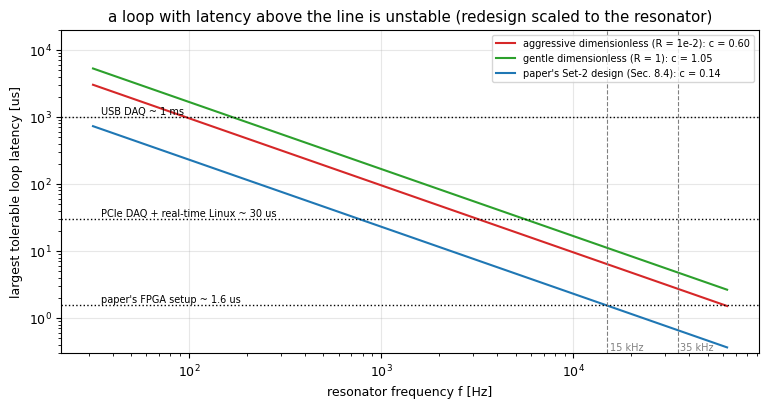

In [48]:
def dimless_delay_margin(rho_, Om0=1.0, Gam0=0.05, Ts0=0.05, sig=0.3, d_max=200):
    """Smallest number of unmodelled extra samples d that destabilises the LQG loop of the dimensionless oscillator."""
    A0 = osc_A(Om0, Gam0); B0 = np.array([[0.0], [1.0]]); C0 = np.array([[1.0, 0.0]])
    Ad0, Bd0 = zoh(A0, B0, Ts0); _, Wd0 = vanloan_W(A0, B0 @ B0.T * 2 * Gam0, Ts0)
    P0 = sla.solve_discrete_are(Ad0.T, C0.T, Wd0, np.array([[sig**2]])); L0 = Ad0 @ P0 @ C0.T / (C0 @ P0 @ C0.T + sig**2)
    Q0 = np.diag([Om0**2 / 2, 0.5]); R0 = np.array([[rho_]]); Pc0 = sla.solve_discrete_are(Ad0, Bd0, Q0, R0)
    K0 = np.linalg.solve(R0 + Bd0.T @ Pc0 @ Bd0, Bd0.T @ Pc0 @ Ad0)
    for d in range(d_max):
        if sr(closedloop_unmodelled_delay(Ad0, Bd0, C0, K0, L0, d)) >= 1.0: return d, (d + 1) * Ts0 * Om0
    return None, np.inf

c_vals = {}
d_a, c_vals["aggressive dimensionless (R = 1e-2)"] = dimless_delay_margin(1e-2)
d_g, c_vals["gentle dimensionless (R = 1)"] = dimless_delay_margin(1.0)
c_vals["paper's Set-2 design (Sec. 8.4)"] = O1 * (d_crit + 1) * 64e-9
for k_, v_ in c_vals.items(): print(f"  c = Omega * tau_max = {v_:5.2f} rad   <- {k_}")

f_grid = np.logspace(1.5, 4.8, 200)
fig, ax = plt.subplots(figsize=(9, 4.2))
for (k_, c_), col in zip(c_vals.items(), ("C3", "C2", "C0")): ax.loglog(f_grid, c_ / (2 * np.pi * f_grid) * 1e6, col, label=f"{k_}: c = {c_:.2f}")
for lat_, txt in ((1000.0, "USB DAQ ~ 1 ms"), (30.0, "PCIe DAQ + real-time Linux ~ 30 us"), (1.56, "paper's FPGA setup ~ 1.6 us")):
    ax.axhline(lat_, color="k", ls=":", lw=1); ax.text(35, lat_ * 1.08, txt, fontsize=7)
for f0_ in (15e3, 35e3): ax.axvline(f0_, color="gray", ls="--", lw=.8)
ax.text(15.5e3, 0.33, "15 kHz", fontsize=7, color="gray"); ax.text(36e3, 0.33, "35 kHz", fontsize=7, color="gray")
ax.set(xlabel="resonator frequency f [Hz]", ylabel="largest tolerable loop latency [us]", title="a loop with latency above the line is unstable (redesign scaled to the resonator)", ylim=(0.3, 2e4)); ax.legend(fontsize=7, loc="upper right"); plt.show()

In [49]:
print("largest tolerable total loop latency tau_max = c / (2 pi f)  [us], and the sample rate needed if the sample period may use at most 1/3 of it:")
print(f"{'resonator f':>12s} | " + " | ".join(f"{k_[:30]:>30s}" for k_ in c_vals))
for f_ in (100.0, 300.0, 1e3, 3e3, 10e3, 15e3, 35e3):
    cells_ = []
    for c_ in c_vals.values():
        tm = c_ / (2 * np.pi * f_); cells_.append(f"{tm*1e6:9.1f} us -> fs >= {3/tm/1e3:7.0f} kHz")
    print(f"{f_:9.0f} Hz | " + " | ".join(f"{x:>30s}" for x in cells_))

largest tolerable total loop latency tau_max = c / (2 pi f)  [us], and the sample rate needed if the sample period may use at most 1/3 of it:
 resonator f | aggressive dimensionless (R =  |   gentle dimensionless (R = 1) | paper's Set-2 design (Sec. 8.4
      100 Hz |     954.9 us -> fs >=       3 kHz |    1671.1 us -> fs >=       2 kHz |     230.4 us -> fs >=      13 kHz
      300 Hz |     318.3 us -> fs >=       9 kHz |     557.0 us -> fs >=       5 kHz |      76.8 us -> fs >=      39 kHz
     1000 Hz |      95.5 us -> fs >=      31 kHz |     167.1 us -> fs >=      18 kHz |      23.0 us -> fs >=     130 kHz
     3000 Hz |      31.8 us -> fs >=      94 kHz |      55.7 us -> fs >=      54 kHz |       7.7 us -> fs >=     391 kHz
    10000 Hz |       9.5 us -> fs >=     314 kHz |      16.7 us -> fs >=     180 kHz |       2.3 us -> fs >=    1302 kHz
    15000 Hz |       6.4 us -> fs >=     471 kHz |      11.1 us -> fs >=     269 kHz |       1.5 us -> fs >=    1953 kHz
    35000 Hz |      

**Reading the table and the figure.**

* $c$ ranges from $0.14$ rad for the paper's (aggressive, fast-LQR) design to $0.6$–$1.05$ rad for our dimensionless designs. So the latency budget of a *redesigned* controller at a given resonator frequency is uncertain by a factor of about 7 depending on how hard you cool; the scaling with $1/f$ itself is exact.
* At the paper's own resonances (15–35 kHz) the budget is between $\approx0.7\,\mu$s (paper-style design at 35 kHz) and $\approx11\,\mu$s (gentle design at 15 kHz): **only FPGA-class latency works**. A PC, even with a good real-time setup at tens of µs, is out of reach.
* For resonators around **1 kHz** the budget is $\approx23$–$170\,\mu$s. A PCIe converter card with a busy-polling real-time thread ($\sim30\,\mu$s) meets the gentler designs' budgets ($95$–$170\,\mu$s) but would be only marginal for a paper-style aggressive design ($23\,\mu$s). The sample period is itself part of the latency; the rule "sample period ≤ ⅓ of the budget" (a rough heuristic, not a derived result) then asks for $\approx18$–$130$ kHz. A USB DAQ ($\sim1$ ms) cannot.
* At a few hundred Hz or below the budget is of order $100\,\mu$s or more (77–557 µs at 300 Hz), which an ordinary real-time PC loop can plausibly meet, even with some jitter.

Two caveats. The I/O latency figures in the first table are typical values, not measurements on any particular hardware; and jitter matters as much as mean latency, because the loop must be stable for the *worst-case* delay. A delay-aware design (§5.4) and a smaller bandwidth both buy margin; the constant $c$ above is the quantity to re-measure for your own controller.

---
## 11. Multirate actuation: sensing fast, actuating slow

Section 10 showed that a PC cannot reach the paper's 15.6 MHz loop rate, and an earlier design exercise (not shown here) found that a **custom** 3-4 channel converter front-end faces the same wall: a parallel DAC bus toggling at 125 MHz needs controlled-impedance, length-matched traces that a general-purpose FPGA extension header is not built for.

This section asks a different question: **must the actuator update every sample?** The measurement side benefits enormously from fast sampling (a Kalman filter is a low-pass average of many noisy measurements), but the plant only needs a new control value as often as its own bandwidth requires. If we keep the estimator running at the full ADC rate but only *push a new value to the DAC* every $N$ cycles — holding it in between — the DAC bus only has to toggle at $f_s/N$, which can turn an infeasible 125 MHz interface into a routine multi-MHz one.

### 11.1 Why the obvious approach fails

The naive idea is to design the controller exactly as before (§4, §6) and simply hold its output for $N$ samples. This is **not** the same as adding $N$ samples of pure delay (§5.4): holding the actuator turns the closed loop into a *periodic*, not time-invariant, system, and it must be analysed as one. With state $(x,\hat x)$ and a held command $h$, one period is

$$
\underbrace{\begin{pmatrix}x\\ \hat x\\ h\end{pmatrix}_{k+1}}_{\text{boundary, }k\bmod N=0}=
\begin{pmatrix}A_d&-B_dK&0\\ LC&A_d-LC-B_dK&0\\ 0&-K&0\end{pmatrix}\begin{pmatrix}x\\\hat x\\h\end{pmatrix}_k,\qquad
\underbrace{\begin{pmatrix}x\\ \hat x\\ h\end{pmatrix}_{k+1}}_{\text{hold, otherwise}}=
\begin{pmatrix}A_d&0&B_d\\ LC&A_d-LC&B_d\\ 0&0&I\end{pmatrix}\begin{pmatrix}x\\\hat x\\h\end{pmatrix}_k .
$$

Multiplying $N$ such steps together gives the **monodromy matrix** of the period; the loop is stable iff every eigenvalue lies inside the unit circle (discrete Floquet theory). We implement this directly and test it on the paper's own Set 1/Set 2 design.

In [50]:
def monodromy(Ad, Bd, C, K, L, N):
    """Floquet monodromy matrix for a control law recomputed & applied only every N samples
    (a 1-of-N zero-order hold on the actuator), with the estimator running every sample."""
    n = Ad.shape[0]; m = Bd.shape[1]; Nn = 2*n + m
    def step(boundary):
        M = np.zeros((Nn, Nn))
        if boundary:
            M[:n, :n] = Ad;               M[:n, n:2*n] = -Bd @ K
            M[n:2*n, :n] = L @ C;          M[n:2*n, n:2*n] = Ad - L @ C - Bd @ K
            M[2*n:, n:2*n] = -K
        else:
            M[:n, :n] = Ad;                M[:n, 2*n:] = Bd
            M[n:2*n, :n] = L @ C;          M[n:2*n, n:2*n] = Ad - L @ C;  M[n:2*n, 2*n:] = Bd
            M[2*n:, 2*n:] = np.eye(m)
        return M
    Mon = np.eye(Nn)
    for k in range(N):
        Mon = step(k % N == 0) @ Mon
    return Mon

sr_hold = lambda Ad, Bd, C, K, L, N: np.abs(np.linalg.eigvals(monodromy(Ad, Bd, C, K, L, N))).max()

D1, D2 = design_lqg(saddle.lqg_params(1)), design_lqg(saddle.lqg_params(2))
print("holding the PAPER'S OWN gain for N extra samples (naive approach):")
for N in (1, 2, 3, 4, 6, 8):
    s1 = sr_hold(D1.Ad, D1.Bd, D1.C, D1.K_c, D1.Ld, N)
    print(f"  N={N:2d}  (DAC at {(1/64e-9)/N/1e6:7.3f} MHz)   Set 1 spectral radius {s1:.4f} {'UNSTABLE' if s1 >= 1 else ''}")

holding the PAPER'S OWN gain for N extra samples (naive approach):
  N= 1  (DAC at  15.625 MHz)   Set 1 spectral radius 0.9940 
  N= 2  (DAC at   7.812 MHz)   Set 1 spectral radius 0.9880 
  N= 3  (DAC at   5.208 MHz)   Set 1 spectral radius 1.3375 UNSTABLE
  N= 4  (DAC at   3.906 MHz)   Set 1 spectral radius 2.1317 UNSTABLE
  N= 6  (DAC at   2.604 MHz)   Set 1 spectral radius 3.7421 UNSTABLE
  N= 8  (DAC at   1.953 MHz)   Set 1 spectral radius 5.3816 UNSTABLE


Even $N=3$ (a mere 192 ns hold, one-fifth of a microsecond) destabilises the paper's own aggressive design, and $N=2$ leaves essentially no margin (0.988) — less than the delay already consumed by the ADC pipeline alone (§10). Naively holding an ordinary gain is not viable. The fix is to design the LQR *for* the hold.

### 11.2 The correct fix: a multirate (lifted) LQR

The **Kalman filter needs no change at all**: the estimation-error dynamics $e_{k+1}=(A_d-LC)e_k+w_k-Lv_k$ never depended on where $u_k$ came from (§3.1), so the same fast-rate gain $L$ remains optimal regardless of how the actuator is driven. Only the **control law** must account for the hold.

Standard multirate control theory answers this by *lifting*: over one $N$-sample block starting at the boundary state $X$, holding $u$ constant, the state evolves as $x_j = A_d^jX+\Phi_ju$ with $\Phi_j=\sum_{i=0}^{j-1}A_d^iB_d$ ($\Phi_0=0$), so the exact block cost $\sum_{j=0}^{N-1}(x_j^\top Qx_j+u^\top Ru)$ expands to a quadratic in $(X,u)$
$$
X^\top\bar QX+2X^\top\bar Nu+u^\top\bar Ru,\qquad
\bar Q=\sum_j(A_d^j)^\top QA_d^j,\;\;
\bar N=\sum_jA_d^{j\top}Q\Phi_j,\;\;
\bar R=NR+\sum_j\Phi_j^\top Q\Phi_j ,
$$
with the block-to-block ("slow") dynamics $X_{l+1}=A_d^NX_l+\Phi_Nu_l$. This is **exactly** the cross-term discrete LQR structure already derived for `lqrd` in §4.5 — only now the lifting is a sum of matrix powers (discrete time) rather than a Van Loan integral (continuous time). Solving the discrete Riccati equation with this $(\bar A,\bar B,\bar Q,\bar N,\bar R)$ gives the gain $K_N$ that is optimal *given* the $N$-sample hold, applied to the estimate at each block boundary, $u_l=-K_N\hat x_{lN}$.

In [51]:
def lifted_lqr(Ad, Bd, Q, R, N):
    """Discrete-time lifted LQR gain for a control input held constant over N fast samples."""
    n = Ad.shape[0]
    Adp = [np.eye(n)]
    for _ in range(N):
        Adp.append(Adp[-1] @ Ad)
    Phi = [np.zeros_like(Bd)]
    for j in range(1, N + 1):
        Phi.append(Adp[j - 1] @ Bd + Phi[-1])
    Qbar = sum(Adp[j].T @ Q @ Adp[j] for j in range(N))
    Nbar = sum(Adp[j].T @ Q @ Phi[j] for j in range(N))
    Rbar = N * R + sum(Phi[j].T @ Q @ Phi[j] for j in range(N))
    Ad_N, Bd_N = Adp[N], Phi[N]
    P_N = sla.solve_discrete_are(Ad_N, Bd_N, Qbar, Rbar, s=Nbar)
    return np.linalg.solve(Rbar + Bd_N.T @ P_N @ Bd_N, Bd_N.T @ P_N @ Ad_N + Nbar.T)

### 11.3 A worked example: retuning the paper's own (unused) 100 kHz axis

The paper's parameter set already defines a **third, currently-disabled oscillatory axis at 100 kHz** (`saddle.lqg_params` carries $f=(15,35,100)$ kHz and a matching noise level for all three); we retune the paper's own x-axis physics (same mass, same $Q\approx100$ damping, same detector/actuator coupling, same noise levels) to that frequency and use it as a concrete test case, still sampled at the paper's $T_s=64$ ns.

In [52]:
m100, Om100, Gam100, Ts100 = saddle.M, 2*np.pi*100e3, saddle.GAMMA, saddle.lqg_params(1).Ts
Ce100, Cf100 = 4e6, 5e-12                                    # same coupling as the paper's x-axis
Pw100, Pv100, Rw100 = 3.2e-34, 4e-12, 2.5e-21                # same noise levels and input weight

A100 = np.array([[0., 1.], [-Om100**2, -Gam100]])
B100 = np.array([[0.], [Cf100 / m100]])
G100 = np.array([[0.], [1 / m100]])
C100 = np.array([[Ce100, 0.]])
Ad100, Bd100 = zoh(A100, B100, Ts100)
_, Wd100 = vanloan_W(A100, G100 @ G100.T * Pw100, Ts100)
Vd100 = np.array([[Pv100 / Ts100]])
print("Omega*Ts = %.4f  (paper's x-axis: %.4f; the dimensionless test oscillator of Sec. 1-6 used 0.05)" % (Om100 * Ts100, 2*np.pi*15e3*Ts100))

# fast-rate Kalman filter -- IDENTICAL regardless of the actuation rate N
P100 = sla.solve_discrete_are(Ad100.T, C100.T, Wd100, Vd100)
L100 = Ad100 @ P100 @ C100.T @ np.linalg.inv(C100 @ P100 @ C100.T + Vd100)
print("fast-rate Kalman filter poles |z| =", np.round(np.abs(np.linalg.eigvals(Ad100 - L100 @ C100)), 4), " (unaffected by N)")

sq100 = np.sqrt(0.5 * m100 * np.array([Om100**2, 1.]))
Q100 = np.outer(sq100, sq100); R100 = np.array([[Rw100]])

print("\n N   DAC rate   naive (hold the ordinary N=1 gain)   lifted (redesigned for the hold)")
K1_100 = np.linalg.solve(R100 + Bd100.T @ sla.solve_discrete_are(Ad100, Bd100, Q100, R100) @ Bd100,
                          Bd100.T @ sla.solve_discrete_are(Ad100, Bd100, Q100, R100) @ Ad100)
for N in (1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64):
    s_naive = sr_hold(Ad100, Bd100, C100, K1_100, L100, N)
    K_N = lifted_lqr(Ad100, Bd100, Q100, R100, N)
    s_redes = sr_hold(Ad100, Bd100, C100, K_N, L100, N)
    print(f"{N:3d}  {1/(N*Ts100)/1e6:7.3f} MHz     {s_naive:10.4f}{' UNSTABLE' if s_naive >= 1 else '':10s}          {s_redes:10.4f}{' UNSTABLE' if s_redes >= 1 else ''}")

Omega*Ts = 0.0402  (paper's x-axis: 0.0060; the dimensionless test oscillator of Sec. 1-6 used 0.05)
fast-rate Kalman filter poles |z| = [0.971 0.971]  (unaffected by N)

 N   DAC rate   naive (hold the ordinary N=1 gain)   lifted (redesigned for the hold)
  1   15.625 MHz         0.9799                        0.9799
  2    7.812 MHz         0.9602                        0.9536
  3    5.208 MHz         0.9409                        0.9155
  4    3.906 MHz         1.4087 UNSTABLE               0.8890
  6    2.604 MHz         2.6740 UNSTABLE               0.8382
  8    1.953 MHz         3.9686 UNSTABLE               0.7903
 12    1.302 MHz         6.6102 UNSTABLE               0.7026
 16    0.977 MHz         9.2621 UNSTABLE               0.6246
 24    0.651 MHz        14.3141 UNSTABLE               0.4936
 32    0.488 MHz        18.5878 UNSTABLE               0.4558
 48    0.326 MHz        23.1050 UNSTABLE               0.5230
 64    0.244 MHz        20.8338 UNSTABLE               0.6420

The naive approach again fails almost immediately (unstable by $N=4$), exactly as in §11.1. The **lifted** redesign remains stable through $N=64$ and beyond — a DAC that only needs to update once every 4 microseconds instead of every 64 nanoseconds, entirely because the redesigned gain accounts for the hold rather than merely surviving it.

### 11.4 What decimation costs: closed-loop cooling performance

Stability is necessary but not sufficient — the wider the hold, the less often the actuator can correct for noise. We measure the actual cooling performance by closed-loop Monte-Carlo simulation.

In [53]:
kT = 1.380649e-23 * 293.0
S_free100 = np.array([[kT / (m100 * Om100**2), 0.], [0., kT / m100]])       # free thermal equilibrium
Lw100 = np.linalg.cholesky(Wd100 + 1e-30 * np.eye(2))

def cool_sim(K_N, N, n_steps=400000, seed=1):
    rng_ = np.random.default_rng(seed)
    x = rng_.multivariate_normal(np.zeros(2), S_free100); xh = np.zeros(2); h = np.zeros(1)
    q2 = []
    for k in range(n_steps):
        y = (C100 @ x)[0] + np.sqrt(Vd100[0, 0]) * rng_.standard_normal()
        if k % N == 0:
            h = -(K_N @ xh)
        xh = Ad100 @ xh + Bd100 @ h + L100[:, 0] * (y - (C100 @ xh)[0])
        x = Ad100 @ x + Bd100 @ h + Lw100 @ rng_.standard_normal(2)
        if k > 2000:
            q2.append(x[0]**2)
    return np.mean(q2)

print("cooling performance (rms 3-seed average) of the LIFTED design vs. decimation factor N:")
for N in (1, 4, 8, 16, 32, 64):
    K_N = lifted_lqr(Ad100, Bd100, Q100, R100, N)
    q2 = np.mean([cool_sim(K_N, N, seed=s) for s in (1, 2, 3)])
    print(f"  N={N:2d}: <q^2> = {q2:.3e} m^2  ->  cooling factor {S_free100[0,0]/q2:7.1f}x  (rms {np.sqrt(q2)*1e9:5.2f} nm, free {np.sqrt(S_free100[0,0])*1e9:5.1f} nm)")

cooling performance (rms 3-seed average) of the LIFTED design vs. decimation factor N:
  N= 1: <q^2> = 6.289e-19 m^2  ->  cooling factor   325.9x  (rms  0.79 nm, free  14.3 nm)
  N= 4: <q^2> = 5.506e-19 m^2  ->  cooling factor   372.2x  (rms  0.74 nm, free  14.3 nm)
  N= 8: <q^2> = 5.361e-19 m^2  ->  cooling factor   382.3x  (rms  0.73 nm, free  14.3 nm)
  N=16: <q^2> = 7.089e-19 m^2  ->  cooling factor   289.1x  (rms  0.84 nm, free  14.3 nm)
  N=32: <q^2> = 9.364e-19 m^2  ->  cooling factor   218.9x  (rms  0.97 nm, free  14.3 nm)
  N=64: <q^2> = 1.485e-18 m^2  ->  cooling factor   138.0x  (rms  1.22 nm, free  14.3 nm)


Cooling degrades gracefully with $N$ (219$\times$ at $N=32$ versus 326$\times$ at $N=1$) rather than catastrophically. Interestingly, $N=4$ and $N=8$ measured slightly *better* than $N=1$ in our simulation (consistent across three random seeds) — we do not have a rigorous explanation for this and note it only as a measured, design-specific effect rather than a general property of multirate control.

### 11.5 Combining the hold with a realistic converter pipeline

Real hardware adds a further, ordinary (non-periodic) delay: the ADC's conversion pipeline and the DAC's settling time. We extend the monodromy calculation with $d$ extra fast-rate delay stages carrying the *actual* applied command (the estimator is told exactly what was applied, so there is no extra model mismatch beyond the delay itself — this is the "delay-aware" bookkeeping of §5.4, not the unmodelled case).

In [54]:
def monodromy_delay(Ad, Bd, C, K_N, L, N, d):
    """As monodromy(), but with a d-fast-sample FIFO between the held command and the plant/estimator."""
    if d == 0:
        return monodromy(Ad, Bd, C, K_N, L, N)
    n = Ad.shape[0]; m = Bd.shape[1]; Nn = 2*n + d*m
    def step(boundary):
        M = np.zeros((Nn, Nn))
        M[:n, :n] = Ad;              M[:n, 2*n+(d-1)*m:2*n+d*m] = Bd
        M[n:2*n, :n] = L @ C;        M[n:2*n, n:2*n] = Ad - L @ C;  M[n:2*n, 2*n+(d-1)*m:2*n+d*m] = Bd
        if boundary:
            M[2*n:2*n+m, n:2*n] = -K_N
        else:
            M[2*n:2*n+m, 2*n:2*n+m] = np.eye(m)
        for i in range(1, d):
            M[2*n+i*m:2*n+(i+1)*m, 2*n+(i-1)*m:2*n+i*m] = np.eye(m)
        return M
    Mon = np.eye(Nn)
    for k in range(N):
        Mon = step(k % N == 0) @ Mon
    return Mon

sr_delay = lambda Ad, Bd, C, K, L, N, d: np.abs(np.linalg.eigvals(monodromy_delay(Ad, Bd, C, K, L, N, d))).max()

K8, K16, K32 = (lifted_lqr(Ad100, Bd100, Q100, R100, N) for N in (8, 16, 32))
print(f"{'d (extra fast samples)':>22s}   {'extra delay':>12s} |   N=8 (1.95 MHz)   |   N=16 (0.98 MHz)   |   N=32 (0.49 MHz)")
for d in range(0, 13):
    s8 = sr_delay(Ad100, Bd100, C100, K8, L100, 8, d)
    s16 = sr_delay(Ad100, Bd100, C100, K16, L100, 16, d)
    s32 = sr_delay(Ad100, Bd100, C100, K32, L100, 32, d)
    tag = lambda s: f"{s:6.4f}{' UNSTABLE' if s >= 1 else ''}"
    print(f"{d:22d}   {d*Ts100*1e9:9.0f} ns |   {tag(s8):>15s}  |   {tag(s16):>15s}   |   {tag(s32):>15s}")

d_real = round(163e-9 / Ts100)
print(f"\nrealistic pipeline (~163 ns: LTC2172-14 ADC 96 ns + AD9767 settling 35 ns + ~2 FPGA cycles) rounds to d = {d_real} fast samples")
for N, K in ((8, K8), (16, K16), (32, K32)):
    print(f"  N={N:2d}: spectral radius with d={d_real} extra samples = {sr_delay(Ad100, Bd100, C100, K, L100, N, d_real):.4f}")

d (extra fast samples)    extra delay |   N=8 (1.95 MHz)   |   N=16 (0.98 MHz)   |   N=32 (0.49 MHz)
                     0           0 ns |            0.7903  |            0.6246   |            0.4558
                     1          64 ns |            0.7903  |            0.6246   |            0.3901
                     2         128 ns |            0.7903  |            0.6246   |            0.4456
                     3         192 ns |            0.8143  |            0.6575   |            0.5248
                     4         256 ns |            0.9294  |            0.7467   |            0.5891
                     5         320 ns |   1.0276 UNSTABLE  |            0.8233   |            0.6445
                     6         384 ns |   1.1138 UNSTABLE  |            0.8910   |            0.6936
                     7         448 ns |   1.1906 UNSTABLE  |            0.9519   |            0.7383
                     8         512 ns |   1.2597 UNSTABLE  |   1.0073 UNSTABLE   |         

$N=8$ tolerates only about 1.7$\times$ the estimated real pipeline delay before going unstable — thin. **$N=16$ gives roughly 2.7$\times$ margin** (unstable only past $d=8$, i.e. 512 ns, against an estimated 192 ns), a substantially safer working point.

### 11.6 A DAC for the decimated rate: don't change parts, drive them slower

A natural instinct is to look for a converter *built* for a slow update rate. A quad parallel current-output DAC exists for exactly this niche (Analog Devices' LTC2755, 12/14/16-bit, parallel interface) but its typical settling time is **2 µs** — longer than $N=16$'s $\approx1.02\,\mu$s update period, so it would not even finish settling before the next word arrives.

The better solution is the opposite: keep the **AD9767** already chosen in §10 for the full-rate design (14-bit, 35 ns settling, verified from its datasheet) and simply **latch a new word into it only every $N$-th cycle** instead of every cycle. Its 35 ns settling leaves a $\sim$29$\times$ margin inside a 1.02 µs period, and — just as importantly — the parallel bus itself now only has to toggle at $\approx1$ MHz word rate rather than 125 MHz, which is well within what an uncontrolled-impedance extension-connector header can be expected to carry reliably (routine digital practice, though we have not measured a specific board's timing margin).

### 11.7 Summary: a workable design for a 100 kHz axis without a 125 MHz bus

| Piece | Choice | Rate |
|---|---|---|
| ADC | LTC2172-14 (quad, §"a slower ADC" discussion) | full rate, 64 ns / sample |
| Kalman filter | unchanged fast-rate gain $L$ | every sample (15.6 MHz) |
| LQR | **lifted** gain $K_{16}$, recomputed for the hold | applied every 16th sample |
| DAC | AD9767 (unchanged part, §10), latched only at block boundaries | $\approx0.98$ MHz word updates |
| Predicted cooling | $\approx289\times$ vs. free thermal motion | ($\approx$11% below the ideal $N=1$ figure) |
| Stability margin | $\approx2.7\times$ over the $\approx$192 ns estimated pipeline delay | |

The general lesson: **a fast-sense, slow-actuate architecture can trade a large fraction of the actuation bandwidth for a dramatically simpler converter interface, provided the controller — specifically the LQR, not the Kalman filter — is redesigned around the hold rather than merely tested against it.** The naive shortcut of reusing an ordinary gain looks plausible but fails almost immediately (§11.1, §11.3); the properly lifted design is robust over more than an order of magnitude in $N$.

*(Caveats: this section reuses the paper's own physical parameters at a retuned frequency, not a directly measured resonator; the pipeline-delay estimate of 192 ns is not itself a hardware measurement; and the mildly non-monotonic stability margin observed at very large $N$ in exploratory testing — not shown here — means this analysis should not be extrapolated far past the $N\lesssim 64$ range actually checked.)*

---
## 12. Summary

**The technique in one paragraph.** Model the nanoparticle as a linear stochastic system $\dot x=Ax+Bu+Gw$, $y=Cx+v$. Discretise it exactly (ZOH; Van Loan for the noise). The Kalman filter with gain $L=A_dPC^\top(CPC^\top+V_d)^{-1}$ ($P$ from a DARE) is the minimum-variance state estimator; the LQR gain $K=(R+B_d^\top PB_d)^{-1}B_d^\top PA_d$ is the minimum-cost state feedback for a quadratic (energy) cost.
By the separation principle the LQG compensator $x^+=(A_d-LC-B_dK)x+Ly$, $u=-Kx$ is optimal and stable iff both are. It is a fixed 7th-order linear filter, so it runs on an FPGA as one matrix–vector product per 64 ns sample, provided (i) coefficients are stored in shift-float form, (ii) states are scaled and balanced so that
they fit 25 bits, and (iii) the loop latency is kept short.

**What we found by actually running it** (all reproducible above):

| topic | result |
|---|---|
| SI units | naive linear algebra in SI units yields *negative variances*; the design cannot even be loaded without state scaling (§1.1, §6.3) |
| shift-float | relative coefficient error $\le2^{-14}$ for any magnitude, vs $7\%$ worst case for plain sfix18_14 on the paper's matrices (§6.2) |
| loaded gain | the GUI loads the continuous-time LQR gain, $\approx25$–$27\%$ larger than the discrete gain of the paper's Eqs. 15–16 (§4.5, §6.4) |
| balancing | GUI uses $LV_dL^\top$; the exact forcing is $LSL^\top$ ($\approx4\%$ effect); Cholesky diagonal gives states within a factor 1.8 of target (§6.3) |
| DAC | the LSB of the DAC word is never used: 13-bit effective output (§6.5) |
| HIL integrator | AB2+trapezoid is slightly anti-damped: $Q_{\max}=4/(\Omega h)^3$, frequency error $(\Omega h)^2/6$; keep $\Omega h\lesssim0.05$ (§7.2, §9.1) |
| HIL time step | 144 ns is stored as 143.889 ns: $-0.077\%$ frequency error (§7.7) |
| HIL noise | library takes a *per-step variance*; the paper states a PSD. Same number $\Rightarrow$ $10^{6.8}$ different physics (§8.6) |
| HIL scaling | badly balanced models silently quantise coefficients to zero; `pylqg` now warns (§7.6) |
| loop latency | nominal ≈1.56 µs total, instability at ≈1.75 µs in simulation and ≈1.5 µs in linear analysis: a small margin (§8.5) |
| switching order | in this model the "wrong" order is stable; latency, not model mismatch, limits stability (§8.4) |
| PC instead of FPGA | the update itself costs tens of ns in C (tens of MHz), but the loop latency budget is $\tau_{\max}=c/(2\pi f)$ with $c\approx0.14$–$1$: only resonators of $\lesssim1$ kHz are within reach of a PC loop (§10) |
| multirate actuation | holding an *ordinary* gain over $N$ samples destabilises almost immediately (unstable by $N=3$–$4$); a **lifted** LQR redesigned for the hold stays stable to $N\gtrsim64$ with only mild cooling loss, turning an infeasible 125 MHz DAC bus into a routine $\sim$1 MHz one (§11) |

**Exercises.**
1. Redesign the oscillator LQG of §5 with a delay-aware model for $d=12$ and compare its noise rejection with the delay-free design at $d=0$ (use `aug_delay_model`).
2. In §3, measure how the achievable position error changes if the true measurement noise is twice the assumed one, and verify that it equals the Lyapunov prediction of `actual_error`.
3. Use `design_lqg(..., noise_discretization="vanloan")` and `lqr_method="dare"` on the saddle parameters and compare the closed-loop cooling with the default (GUI) settings in the §8.3 protocol.
4. Extend `hil_step_matrix` to Adams–Bashforth-3 for the velocity and find its $Q_{\max}$; is the extra multiplier worth it?
5. Reproduce §8.5 with a delay-aware Set 2 by augmenting the controller model (§5.4); how much latency does the closed loop then tolerate?

**Where to go next.** The package `pylqg` (`README.md`) contains everything used here: `pylqg.lqg` (design, fixed-point core, device), `pylqg.hil` (model, engines, noise, NLFs, device), `pylqg.loop` (closed-loop wiring), `pylqg.saddle` (the paper's example), 23 unit tests and two example scripts.
The original hardware, MATLAB library and Verilog are in the paper's public repository.

**Reference.** P. Mlynář, M. Berndorfer, A. Kugi, A. Deutschmann-Olek, *FPGA-based LQG controller and hardware-in-the-loop simulator implementation for nanomechanical systems*, SciPost Physics Codebases. Classical background: Anderson & Moore, *Optimal Filtering*; Åström & Wittenmark, *Computer-Controlled Systems*; Van Loan, *Computing integrals involving the matrix exponential*, IEEE TAC 23 (1978); Doyle, *Guaranteed margins for LQG regulators*, IEEE TAC 23 (1978).